# Digital Talaria — Chapter 4 Analysis
## Thirteen-Model Comparison: Study 1 (Baselines vs TFN) + Study 2 (TFN Ablation Staircase)

**Author:** Sean Eben Aloysius Szpunar  
**Program:** PhD — School of Technology and Engineering, National University

**RQ1** — Does adherence score differ meaningfully across architecturally distinct models overall?  
**RQ2** — Does adherence score differ meaningfully by runner profile type?  
**RQ3** — Does adherence score differ meaningfully by training phase?  
**RQ4** — Does adherence score differ meaningfully by runner fitness level?

**Study 1:** 5 baselines + TFN (complete architecture) — answers RQ1–RQ4  
**Study 2:** 8-variant TFN ablation staircase — incremental component contributions

Run `python -m src.evaluation.comparison_evaluator` before executing.

## 0. Setup

In [1]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

FIGURES_DIR   = os.path.join(os.getcwd(), 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

COMBINED_SPSS = os.path.join(ROOT, 'data', 'comparison', 'combined_spss.csv')
STATS_CSV     = os.path.join(ROOT, 'data', 'comparison', 'statistical_tests.csv')
PAIRWISE_CSV  = os.path.join(ROOT, 'data', 'comparison', 'pairwise_tests.csv')

print(f'ROOT          : {ROOT}')
print(f'Figures dir   : {FIGURES_DIR}')
print(f'Combined SPSS : {os.path.exists(COMBINED_SPSS)}')

ROOT          : c:\Users\sszpu\source\repos\Talaria.AI
Figures dir   : c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures
Combined SPSS : True


In [2]:
BASELINES     = ['logreg', 'xgb', 'sasrec', 'transformer', 'two_tower']
TFN_ABLATION  = ['TFN-B','TFN-B-G','TFN-BG-C','TFN-BGC-Uq',
                  'TFN-BGCUq-W','TFN-BGCUqW-Mh','TFN-BGCUqWMh-Mt','TFN']
STUDY1_MODELS = BASELINES + ['TFN']
MODELS        = BASELINES + TFN_ABLATION

PROFILE_ORDER = ['PA', 'UW', 'OW', 'HS', 'SD']
PHASE_ORDER   = ['base', 'build', 'peak', 'taper']
TIER_ORDER    = ['low', 'mid', 'high']

MODEL_LABELS = {
    'logreg':'LogReg','xgb':'XGBoost','sasrec':'SASRec',
    'transformer':'Transformer','two_tower':'Two-Tower',
    'TFN-B':'TFN-B','TFN-B-G':'TFN-B-G','TFN-BG-C':'TFN-BG-C',
    'TFN-BGC-Uq':'TFN-BGC-Uq','TFN-BGCUq-W':'TFN-BGCUq-W',
    'TFN-BGCUqW-Mh':'TFN-BGCUqW-Mh','TFN-BGCUqWMh-Mt':'TFN-BGCUqWMh-Mt','TFN':'TFN',
}
MODEL_LABELS_FULL = {
    'logreg':'Logistic Regression','xgb':'XGBoost','sasrec':'SASRec',
    'transformer':'Transformer','two_tower':'Two-Tower',
    'TFN-B':'TFN-B (Banister only)','TFN-B-G':'TFN-B-G (+ Graph encoder)',
    'TFN-BG-C':'TFN-BG-C (+ Cross-attention scorer)',
    'TFN-BGC-Uq':'TFN-BGC-Uq (+ MC Dropout UQ)',
    'TFN-BGCUq-W':'TFN-BGCUq-W (+ Wearable integration)',
    'TFN-BGCUqW-Mh':'TFN-BGCUqW-Mh (+ Multi-head attention)',
    'TFN-BGCUqWMh-Mt':'TFN-BGCUqWMh-Mt (+ Multi-task scoring)',
    'TFN':'TFN (+ Clinical safety gate)',
}

# TFN gold gradient — all 7 prior steps strictly lighter than anchor #D4AC0D
# Generated via HSL interpolation (same hue, decreasing sat + increasing lum)
_TFN_GOLD = ['#F4F3F0','#E7E4D7','#DED7BC','#D8CC9D',
              '#D5C37A','#D6BC54','#DAB72B','#D4AC0D']
MODEL_COLORS = {
    'logreg':'#6C757D','xgb':'#C0392B','sasrec':'#27AE60',
    'transformer':'#E91E8C','two_tower':'#8E44AD',
    'TFN-B':_TFN_GOLD[0],'TFN-B-G':_TFN_GOLD[1],'TFN-BG-C':_TFN_GOLD[2],
    'TFN-BGC-Uq':_TFN_GOLD[3],'TFN-BGCUq-W':_TFN_GOLD[4],
    'TFN-BGCUqW-Mh':_TFN_GOLD[5],'TFN-BGCUqWMh-Mt':_TFN_GOLD[6],'TFN':_TFN_GOLD[7],
}

matplotlib.rcParams.update({
    'font.family':'sans-serif','font.size':10,'axes.titlesize':11,
    'axes.labelsize':10,'xtick.labelsize':9,'ytick.labelsize':9,
    'legend.fontsize':7,'figure.dpi':150,'savefig.dpi':300,
    'savefig.bbox':'tight','axes.spines.top':False,'axes.spines.right':False,
})

def save_fig(name):
    path = os.path.join(FIGURES_DIR, name)
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print(f'[OK] Saved -> {path}')
    plt.show()

def annotate_bars(ax, bars, vals, fmt='{:.4f}', offset=0.002, fontsize=7):
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+offset,
                fmt.format(val), ha='center', va='bottom',
                fontsize=fontsize, color='#1a1a1a')

def annotate_line_chart(ax, x_vals, series_dict, colors_dict, labels_dict,
                         fmt='{:.3f}', fontsize=7.5, stagger=True):
    """Annotate every point on a line chart. stagger=True offsets alternating labels."""
    for j, (m, vals) in enumerate(series_dict.items()):
        for i, (x, y) in enumerate(zip(x_vals, vals)):
            dy = 0.003 if (not stagger or j % 2 == 0) else -0.006
            ax.text(x, y + dy, fmt.format(y),
                    ha='center', va='bottom', fontsize=fontsize,
                    color=colors_dict[m], fontweight='bold')

print(f'Style constants loaded — {len(MODELS)} models '
      f'({len(BASELINES)} baselines + {len(TFN_ABLATION)} TFN variants)')

Style constants loaded — 13 models (5 baselines + 8 TFN variants)


## 1. Load Data

In [3]:
df       = pd.read_csv(COMBINED_SPSS)
df_stats = pd.read_csv(STATS_CSV)
df_pair  = pd.read_csv(PAIRWISE_CSV)

for col in ['progressive_overload_compliance_rate','periodization_compliance_rate',
            'ten_percent_compliance_rate','adaptation_success','avg_adherence_score',
            'rmse_distance','rmse_rpe','rmse_weekly_volume',
            'disruption_injury','disruption_abstention','disruption_partial',
            'ten_percent_violation_count']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Derive adaptation_success_rate from raw 0/1 flag
if 'adaptation_success_rate' not in df.columns and 'adaptation_success' in df.columns:
    df['adaptation_success_rate'] = df['adaptation_success']

# Derive full_compliance_rate as mean of the three constraint compliance columns
comp_cols = [c for c in ['progressive_overload_compliance_rate',
                          'periodization_compliance_rate',
                          'ten_percent_compliance_rate'] if c in df.columns]
df['full_compliance_rate'] = df[comp_cols].mean(axis=1) if comp_cols else df['avg_adherence_score']

print(f'Rows     : {len(df):,}')
print(f'Models   : {sorted(df["model"].unique())}')
print(f'Columns  : {list(df.columns)}')

Rows     : 41,600
Models   : ['TFN', 'TFN-B', 'TFN-B-G', 'TFN-BG-C', 'TFN-BGC-Uq', 'TFN-BGCUq-W', 'TFN-BGCUqW-Mh', 'TFN-BGCUqWMh-Mt', 'logreg', 'sasrec', 'transformer', 'two_tower', 'xgb']
Columns  : ['model', 'runner_id', 'age', 'gender', 'profile_type', 'age_division', 'week_number', 'training_phase', 'progressive_overload_compliance_rate', 'adaptation_success', 'rmse_distance', 'periodization_compliance_rate', 'weekly_volume_actual_mi', 'rmse_rpe', 'ten_percent_compliance_rate', 'ten_percent_violation_count', 'rmse_weekly_volume', 'adherence_rate', 'avg_adherence_score', 'precision', 'recall', 'disruption_injury', 'disruption_abstention', 'disruption_partial', 'entries_logged', 'fitness_tier', 'adaptation_success_rate', 'full_compliance_rate']


## 2. Dataset Composition

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig01a_composition_by_type.png


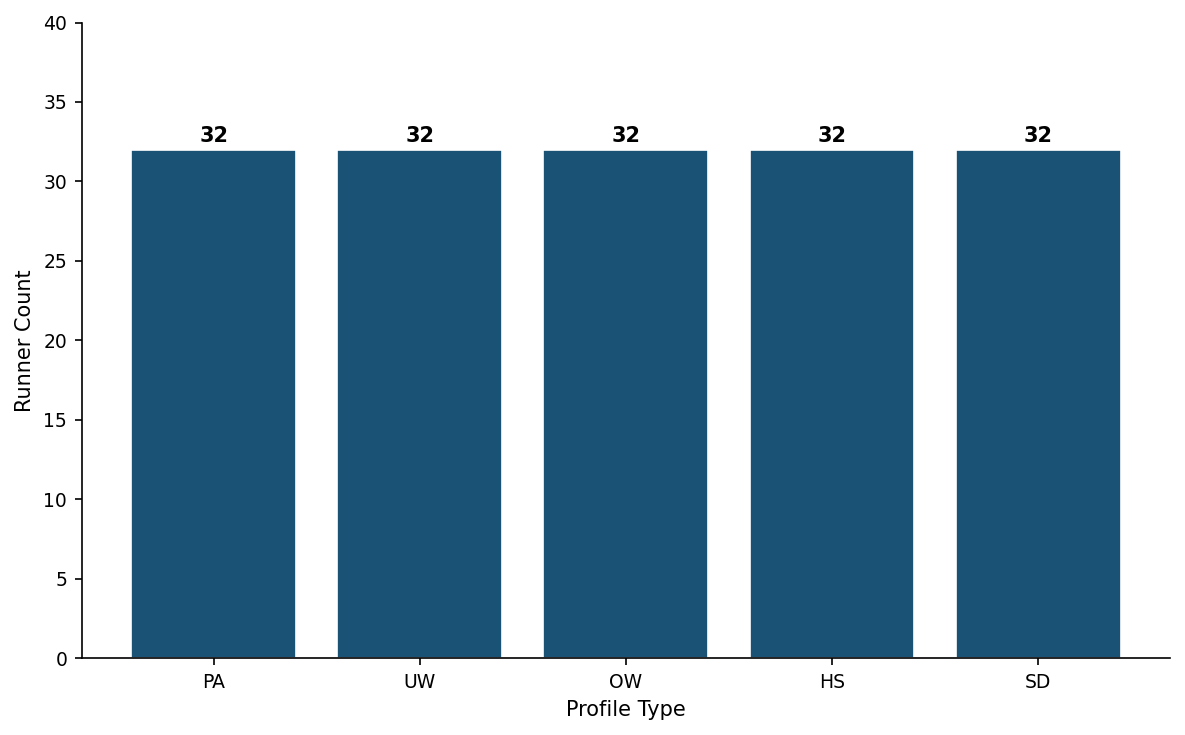

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig01b_composition_by_tier.png


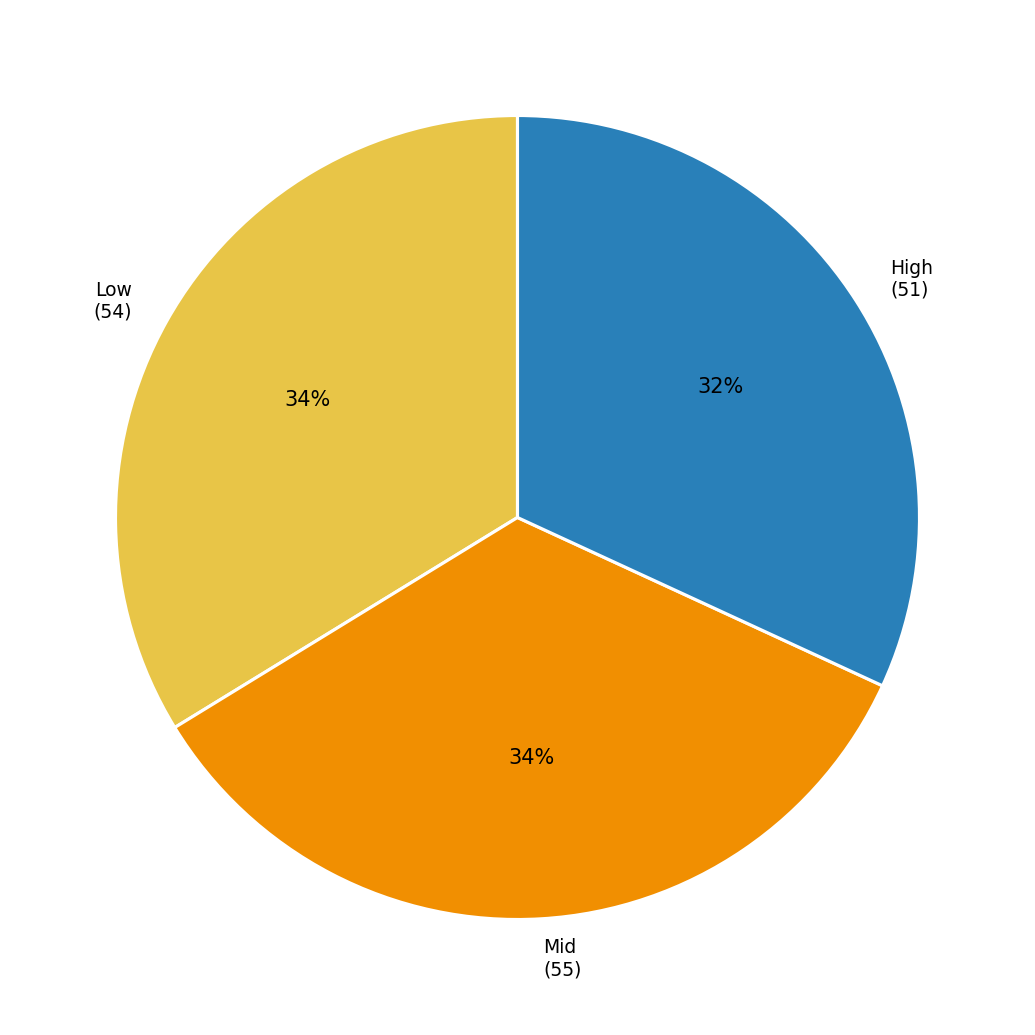

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig01c_composition_by_model.png


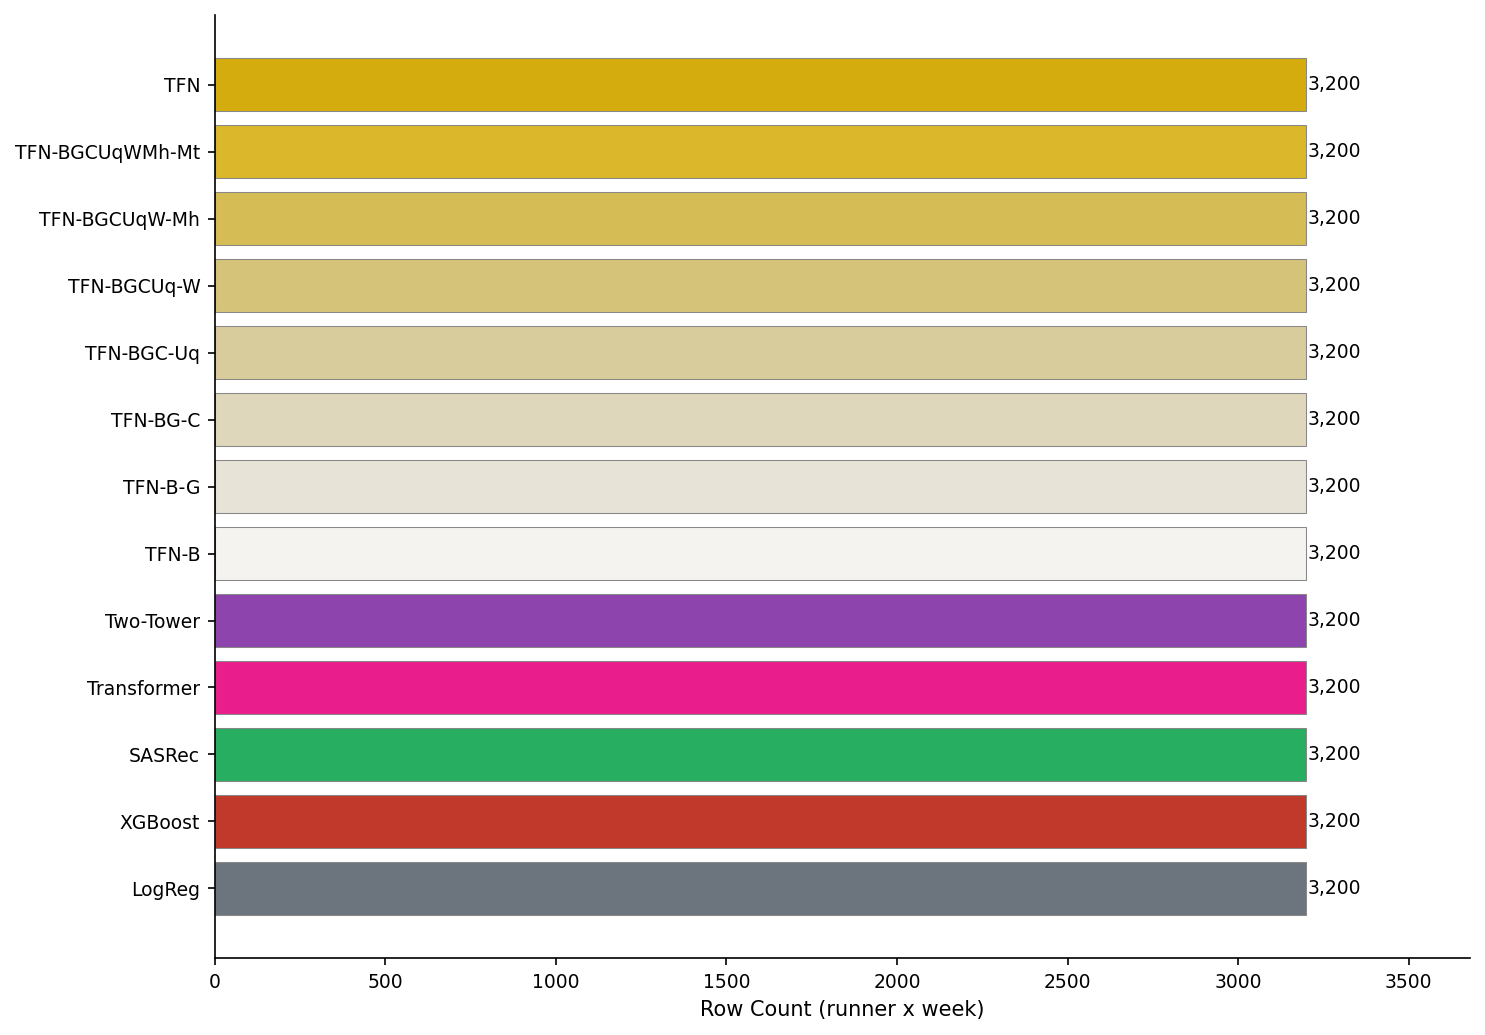

In [4]:
runner_df   = df[df['model']=='xgb'].drop_duplicates('runner_id')
type_counts = runner_df['profile_type'].value_counts().reindex(PROFILE_ORDER)
tier_counts = runner_df['fitness_tier'].value_counts().reindex(TIER_ORDER)

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(PROFILE_ORDER, type_counts.values, color='#1A5276', edgecolor='white', linewidth=0.8)
ax.set_xlabel('Profile Type'); ax.set_ylabel('Runner Count')
ax.set_ylim(0, max(type_counts.values)*1.25)
for bar, val in zip(bars, type_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2, str(val),
            ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout(); save_fig('fig01a_composition_by_type.png')

fig, ax = plt.subplots(figsize=(7,7))
ax.pie(tier_counts.values,
       labels=[f'{t.capitalize()}\n({v})' for t,v in zip(tier_counts.index, tier_counts.values)],
       colors=['#E8C547','#F18F01','#2980B9'], autopct='%1.0f%%', startangle=90,
       wedgeprops={'edgecolor':'white','linewidth':1.5})
plt.tight_layout(); save_fig('fig01b_composition_by_tier.png')

fig, ax = plt.subplots(figsize=(10,7))
model_counts = df.groupby('model').size().reindex(MODELS)
bars = ax.barh([MODEL_LABELS[m] for m in MODELS], model_counts.values,
               color=[MODEL_COLORS[m] for m in MODELS], edgecolor='#888888', linewidth=0.5)
ax.set_xlabel('Row Count (runner x week)')
for bar, val in zip(bars, model_counts.values):
    ax.text(val+5, bar.get_y()+bar.get_height()/2, f'{val:,}', va='center', fontsize=9)
ax.set_xlim(0, max(model_counts.values)*1.15)
plt.tight_layout(); save_fig('fig01c_composition_by_model.png')

## 3. Adherence Score Distributions (Study 1)

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig02a_distributions_kde.png


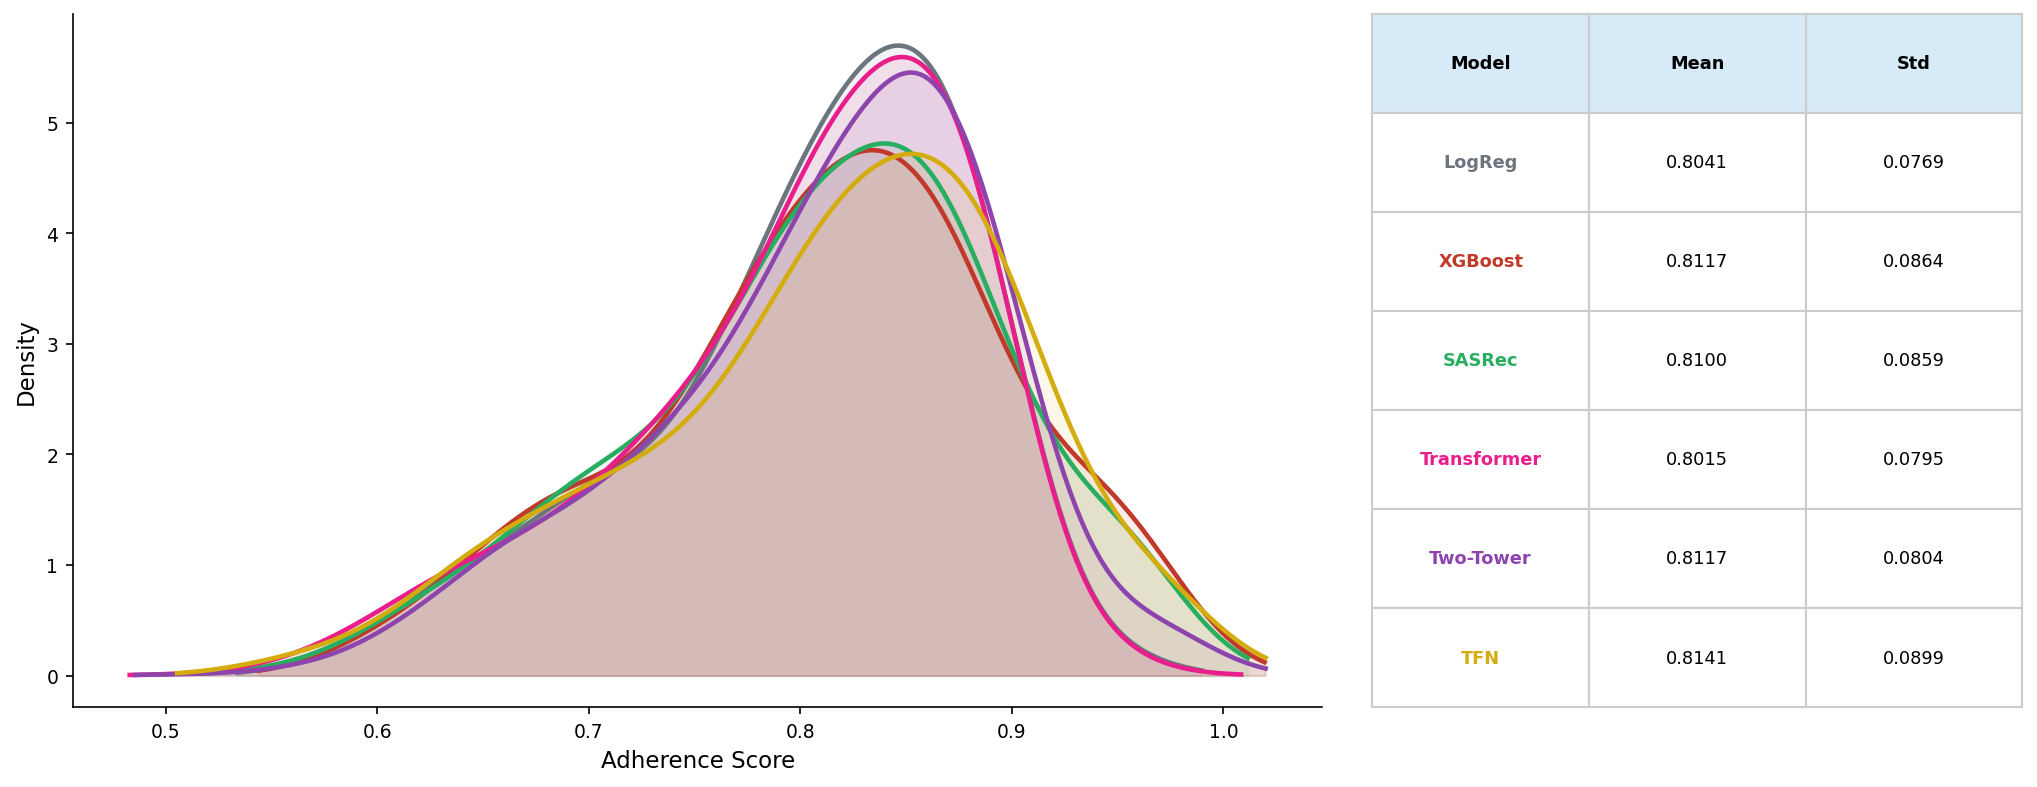

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig02b_distributions_boxplot.png


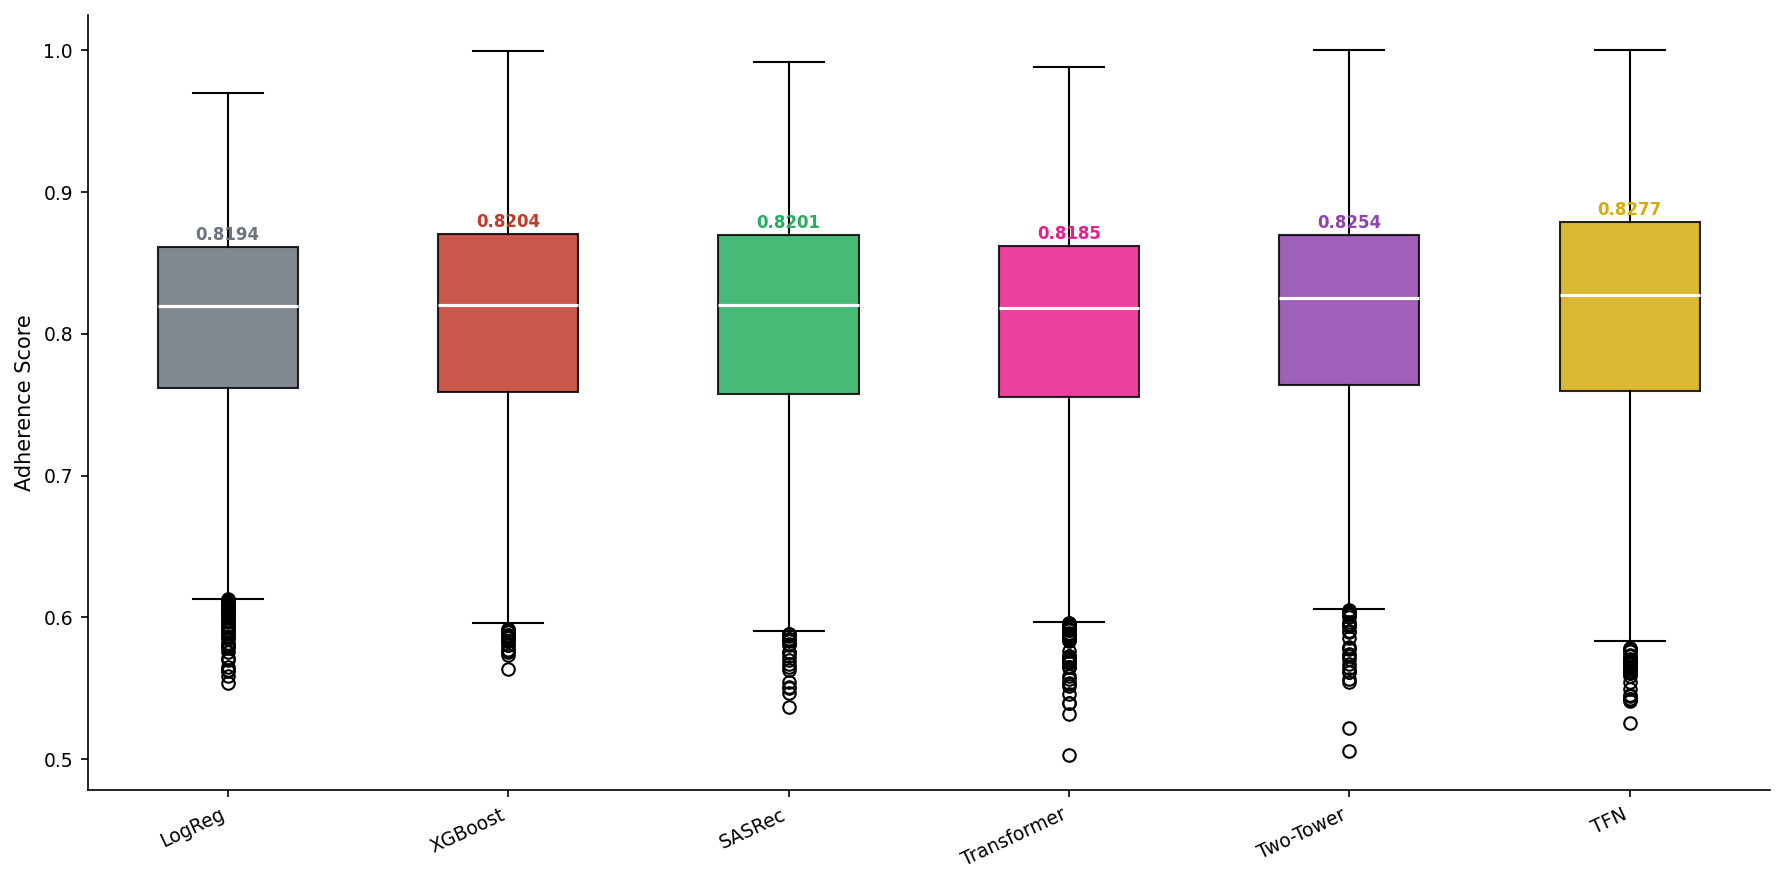

In [5]:
df_s1 = df[df['model'].isin(STUDY1_MODELS)]

# Fig 02a — KDE with right-margin model/mean table
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(14, 6))
fig.subplots_adjust(right=0.72)          # leave right margin for table

for m in STUDY1_MODELS:
    vals    = df_s1[df_s1['model']==m]['avg_adherence_score'].dropna().values
    kde     = gaussian_kde(vals, bw_method=0.3)
    x_grid  = np.linspace(vals.min()-0.02, vals.max()+0.02, 400)
    density = kde(x_grid)
    ax.plot(x_grid, density, color=MODEL_COLORS[m], linewidth=2.2, label=MODEL_LABELS[m])
    ax.fill_between(x_grid, density, alpha=0.09, color=MODEL_COLORS[m])

ax.set_xlabel('Adherence Score', fontsize=11)
ax.set_ylabel('Density', fontsize=11)

# Right-margin table: model | mean | std
table_data = []
col_labels = ['Model', 'Mean', 'Std']
for m in STUDY1_MODELS:
    vals = df_s1[df_s1['model']==m]['avg_adherence_score'].dropna().values
    table_data.append([MODEL_LABELS[m], f'{vals.mean():.4f}', f'{vals.std():.4f}'])

tbl = ax.table(
    cellText=table_data, colLabels=col_labels,
    bbox=[1.04, 0.0, 0.52, 1.0],   # [left, bottom, width, height] in axes fraction
    cellLoc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#CCCCCC')
    if r == 0:
        cell.set_facecolor('#D6EAF8')
        cell.set_text_props(fontweight='bold')
    else:
        m = STUDY1_MODELS[r-1]
        cell.set_facecolor('#FFFFFF')
        if c == 0:
            cell.set_text_props(color=MODEL_COLORS[m], fontweight='bold')

save_fig('fig02a_distributions_kde.png')

# Fig 02b — Boxplots with median annotations
fig, ax = plt.subplots(figsize=(12, 6))
s1_data = [df_s1[df_s1['model']==m]['avg_adherence_score'].dropna().values
           for m in STUDY1_MODELS]
bp = ax.boxplot(s1_data, patch_artist=True, medianprops={'color':'white','linewidth':1.5})
for patch, m in zip(bp['boxes'], STUDY1_MODELS):
    patch.set_facecolor(MODEL_COLORS[m]); patch.set_alpha(0.85)
for i, (m, vals) in enumerate(zip(STUDY1_MODELS, s1_data)):
    med = np.median(vals)
    q75 = np.percentile(vals, 75)
    ax.text(i+1, q75+0.002, f'{med:.4f}', ha='center', va='bottom',
            fontsize=8, fontweight='bold', color=MODEL_COLORS[m])
ax.set_xticks(range(1, len(STUDY1_MODELS)+1))
ax.set_xticklabels([MODEL_LABELS[m] for m in STUDY1_MODELS], rotation=25, ha='right')
ax.set_ylabel('Adherence Score')
plt.tight_layout(); save_fig('fig02b_distributions_boxplot.png')


## 4. RQ2 — Adherence by Profile Type (Study 1)

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig03a_profile_type_bar.png


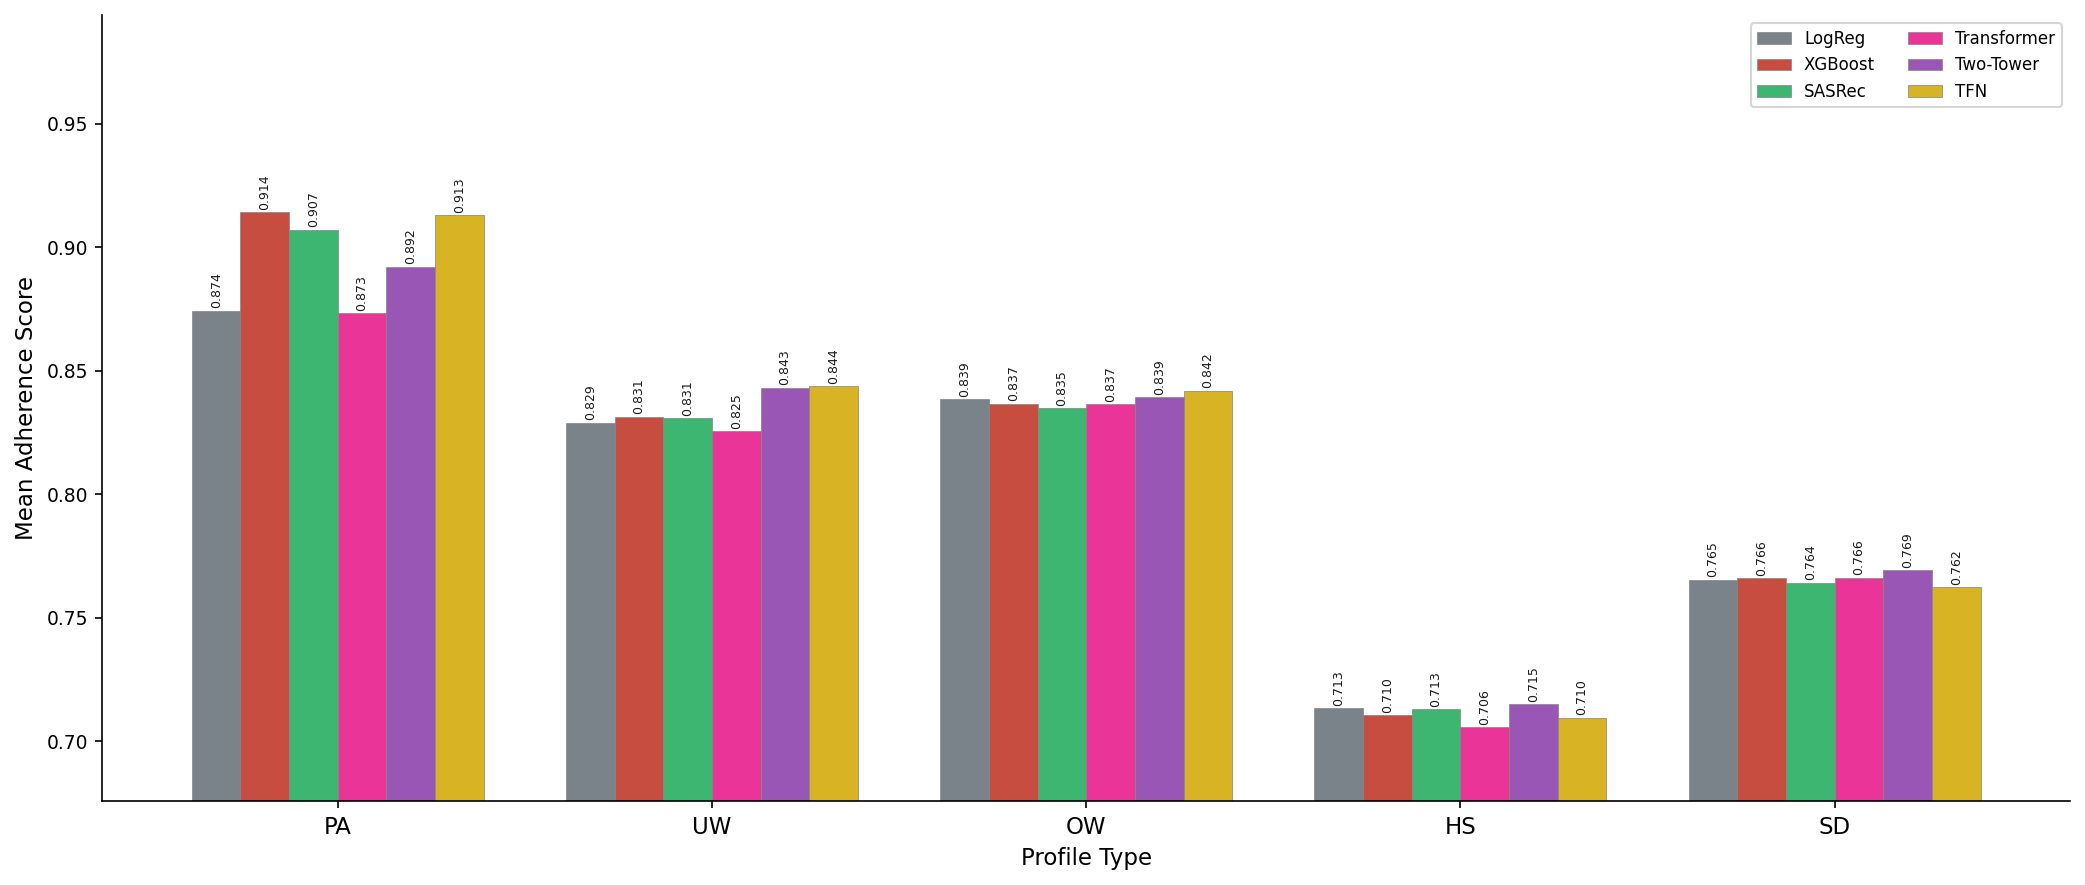

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig03b_profile_type_line.png


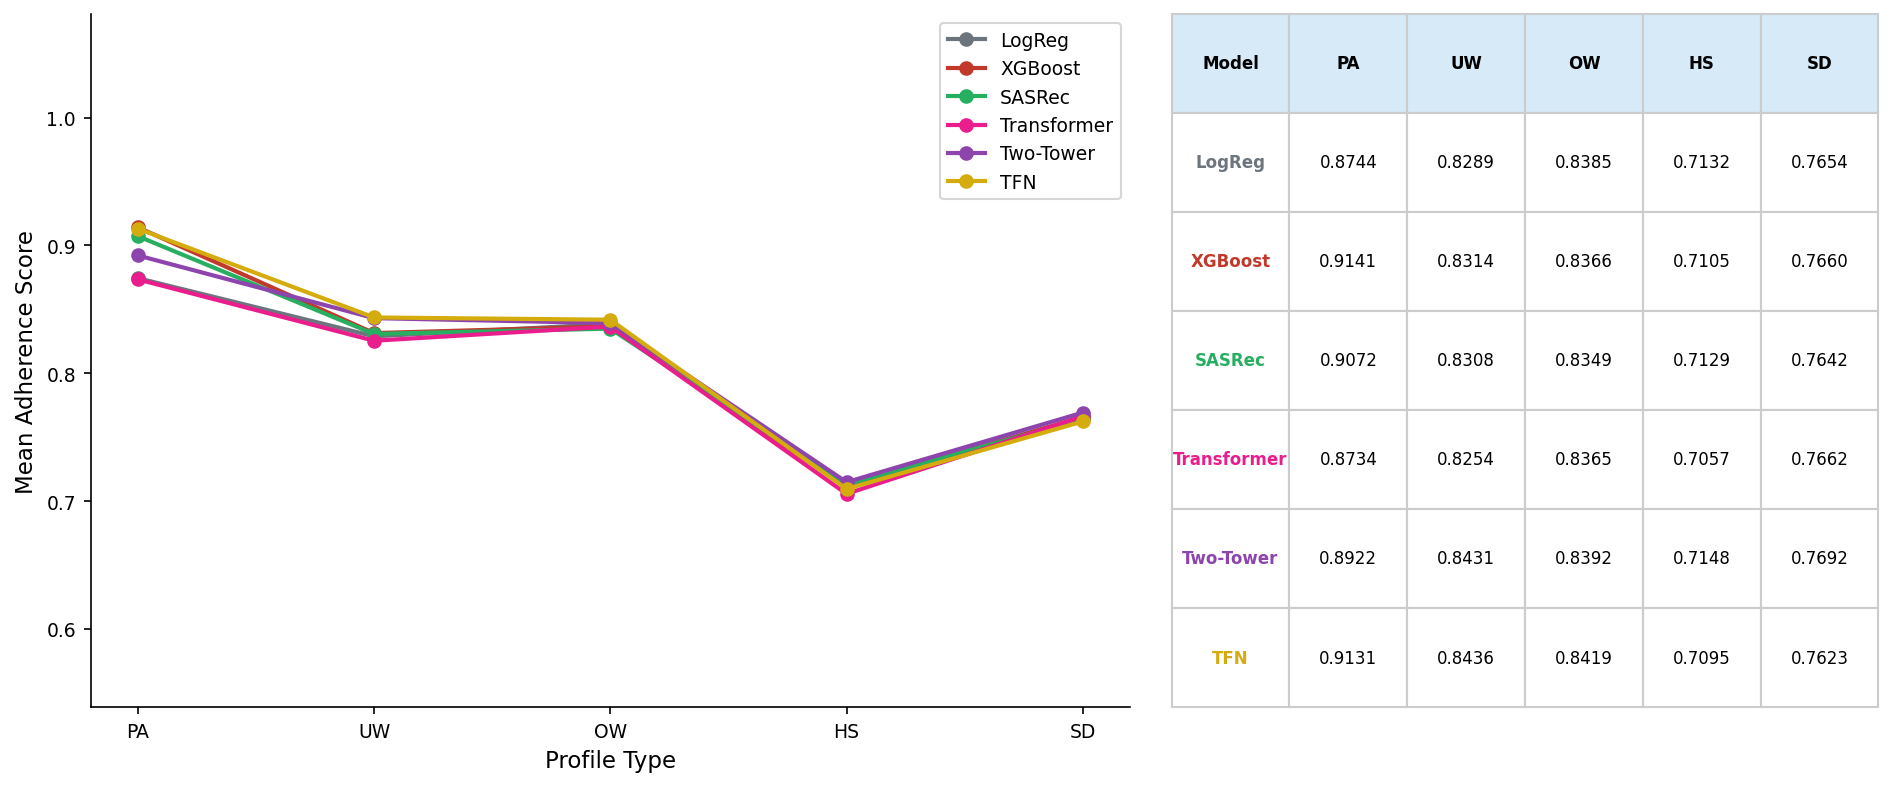

In [6]:
df_s1 = df[df['model'].isin(STUDY1_MODELS)]

# Fig 03a — Grouped bar
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(PROFILE_ORDER)); width = 0.13
all_vals = []
for i, m in enumerate(STUDY1_MODELS):
    means = [df_s1[(df_s1['model']==m)&(df_s1['profile_type']==pt)]['avg_adherence_score'].mean()
             for pt in PROFILE_ORDER]
    all_vals.extend(means)
    bars = ax.bar(x+i*width, means, width, label=MODEL_LABELS[m],
                  color=MODEL_COLORS[m], edgecolor='#888888', linewidth=0.4, alpha=0.9)
    for bar, val in zip(bars, means):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=6, rotation=90, color='#1a1a1a')
ax.set_xticks(x+width*2.5); ax.set_xticklabels(PROFILE_ORDER, fontsize=11)
ax.set_xlabel('Profile Type', fontsize=11); ax.set_ylabel('Mean Adherence Score', fontsize=11)
ax.legend(fontsize=8, ncol=2)
mn, mx = min(all_vals), max(all_vals)
ax.set_ylim(max(0, mn-0.03), mx+0.08)
plt.tight_layout(); save_fig('fig03a_profile_type_bar.png')

# Fig 03b — Line chart with right-margin callout table
# Values are too close together for in-plot per-point labels to be legible.
# Use a right-margin table (one row per model, one column per profile type).
fig, ax = plt.subplots(figsize=(14, 6))
fig.subplots_adjust(right=0.62)

series = {}
for m in STUDY1_MODELS:
    means = [df_s1[(df_s1['model']==m)&(df_s1['profile_type']==pt)]['avg_adherence_score'].mean()
             for pt in PROFILE_ORDER]
    series[m] = means
    ax.plot(PROFILE_ORDER, means, marker='o', markersize=6, linewidth=2,
            color=MODEL_COLORS[m], label=MODEL_LABELS[m])

ax.set_xlabel('Profile Type', fontsize=11); ax.set_ylabel('Mean Adherence Score', fontsize=11)
ax.legend(fontsize=9)
all_pts = [v for s in series.values() for v in s]
mn, mx = min(all_pts), max(all_pts); sp = max(mx-mn, 0.001)
ax.set_ylim(mn - sp*0.8, mx + sp*0.8)

# Right-margin table: model | PA | UW | OW | HS | SD
tbl_data = [[MODEL_LABELS[m]] + [f'{v:.4f}' for v in series[m]] for m in STUDY1_MODELS]
col_labels = ['Model'] + PROFILE_ORDER
tbl = ax.table(
    cellText=tbl_data, colLabels=col_labels,
    bbox=[1.04, 0.0, 0.68, 1.0],
    cellLoc='center',
)
tbl.auto_set_font_size(False); tbl.set_fontsize(8)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#CCCCCC')
    if r == 0:
        cell.set_facecolor('#D6EAF8'); cell.set_text_props(fontweight='bold')
    else:
        m = STUDY1_MODELS[r-1]
        cell.set_facecolor('#FFFFFF')
        if c == 0:
            cell.set_text_props(color=MODEL_COLORS[m], fontweight='bold')

save_fig('fig03b_profile_type_line.png')


## 5. RQ3 — Adherence by Training Phase (Study 1)

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig04a_phase_bar.png


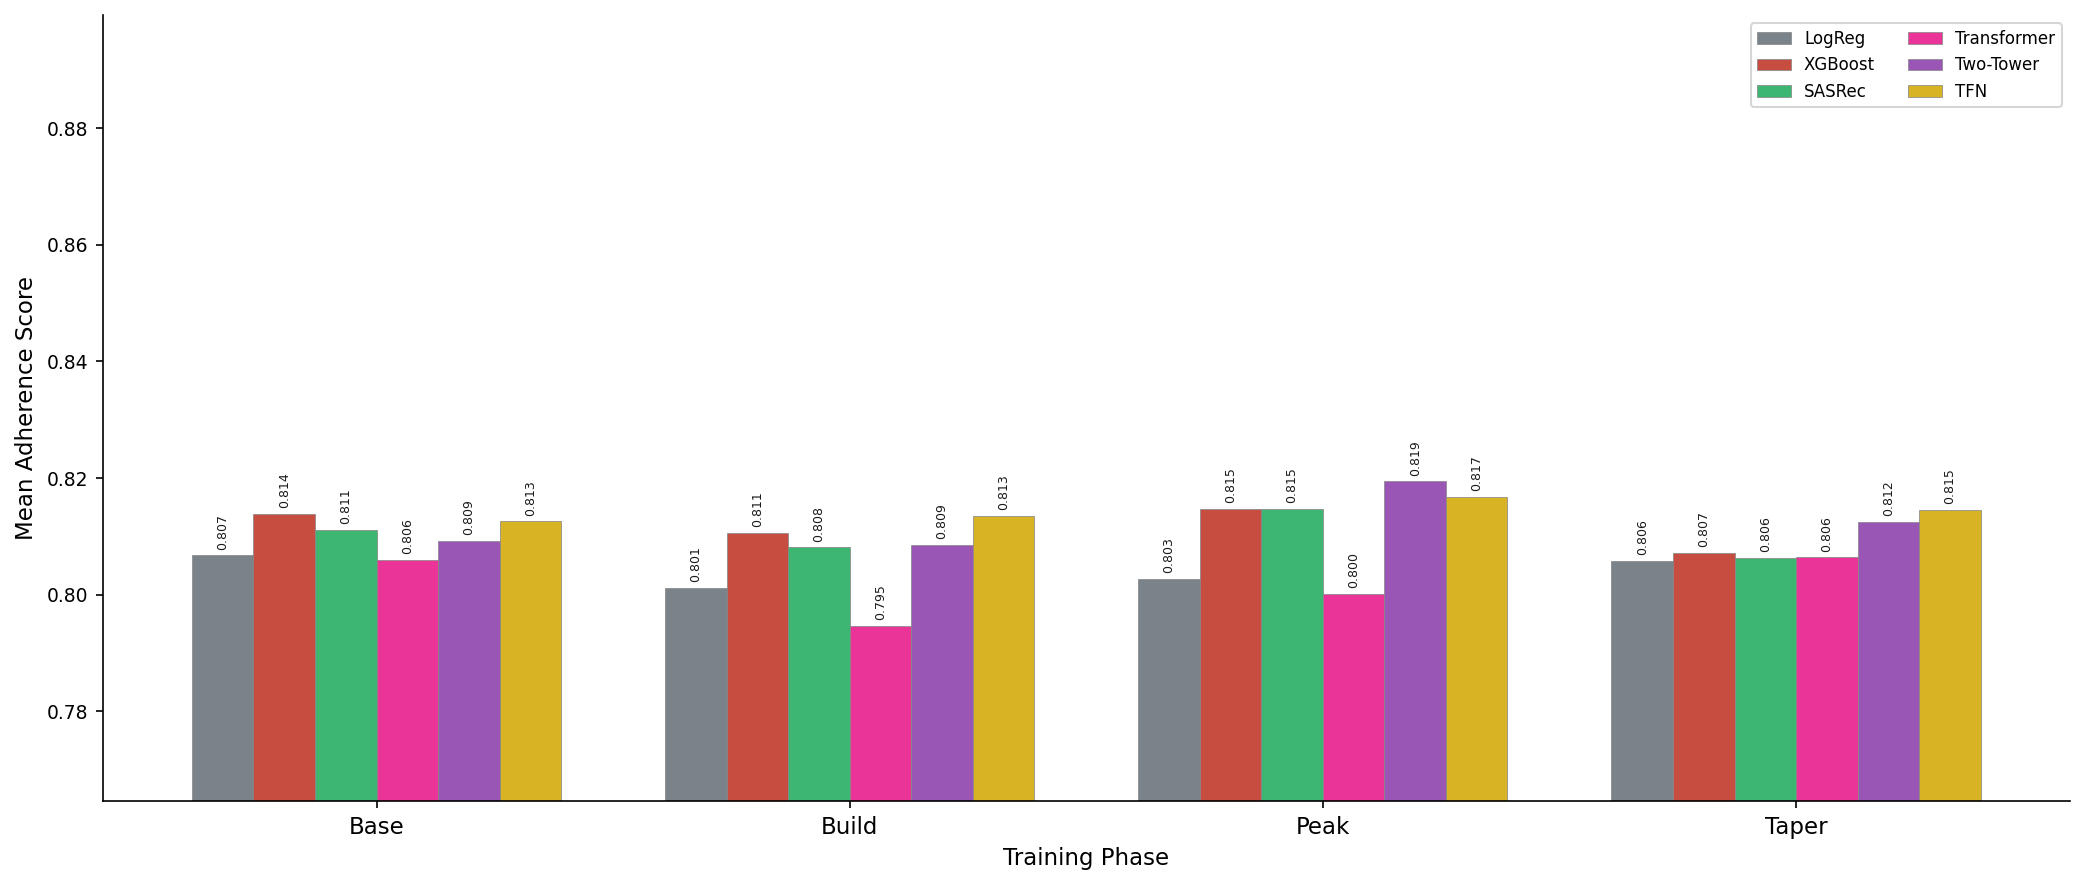

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig04b_phase_line.png


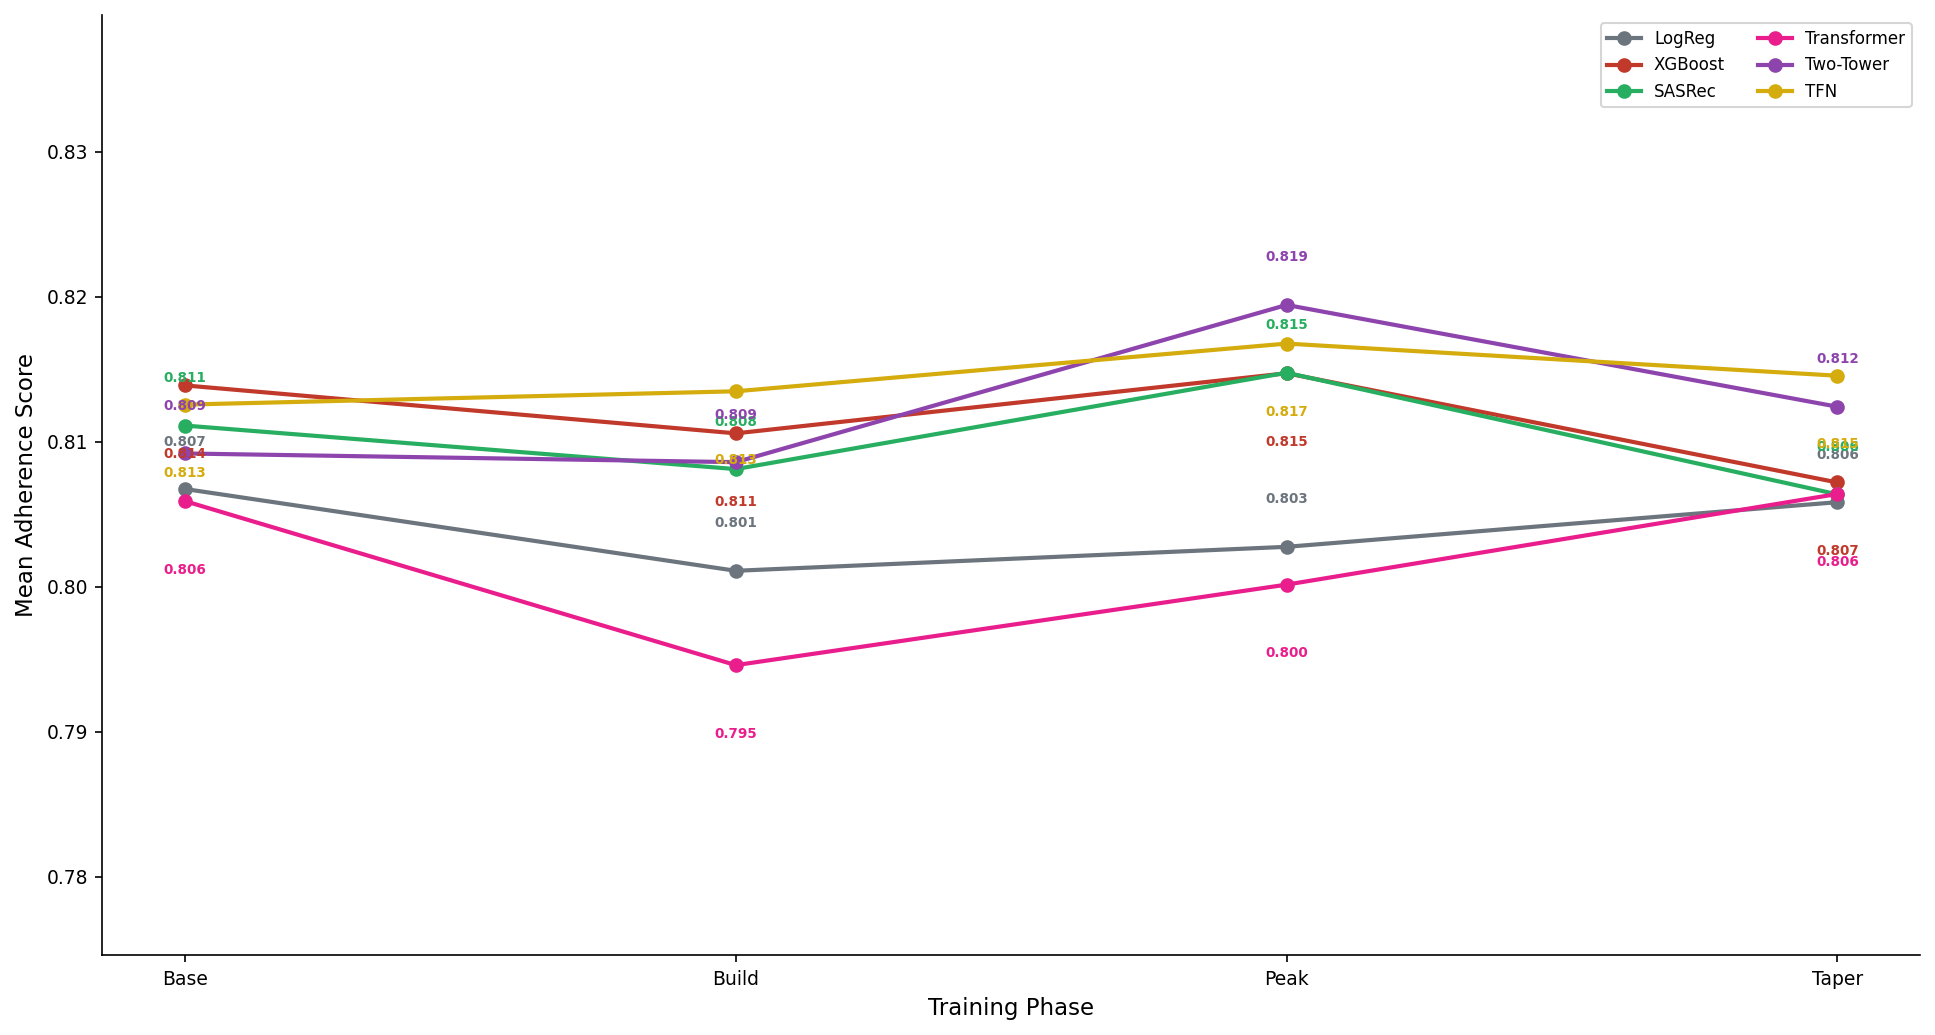

In [7]:
df_s1 = df[df['model'].isin(STUDY1_MODELS)]
phase_labels = [p.capitalize() for p in PHASE_ORDER]

# Fig 04a — Grouped bar
fig, ax = plt.subplots(figsize=(14,6))
x = np.arange(len(PHASE_ORDER)); width = 0.13
all_vals = []
for i, m in enumerate(STUDY1_MODELS):
    means = [df_s1[(df_s1['model']==m)&(df_s1['training_phase']==ph)]['avg_adherence_score'].mean()
             for ph in PHASE_ORDER]
    all_vals.extend(means)
    bars = ax.bar(x+i*width, means, width, label=MODEL_LABELS[m],
                  color=MODEL_COLORS[m], edgecolor='#888888', linewidth=0.4, alpha=0.9)
    for bar, val in zip(bars, means):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=6, rotation=90, color='#1a1a1a')
ax.set_xticks(x+width*2.5); ax.set_xticklabels(phase_labels, fontsize=11)
ax.set_xlabel('Training Phase', fontsize=11); ax.set_ylabel('Mean Adherence Score', fontsize=11)
ax.legend(fontsize=8, ncol=2)
mn, mx = min(all_vals), max(all_vals)
ax.set_ylim(max(0, mn-0.03), mx+0.08)
plt.tight_layout(); save_fig('fig04a_phase_bar.png')

# Fig 04b — Line chart with per-point value labels
fig, ax = plt.subplots(figsize=(13,7))
series = {}
for m in STUDY1_MODELS:
    means = [df_s1[(df_s1['model']==m)&(df_s1['training_phase']==ph)]['avg_adherence_score'].mean()
             for ph in PHASE_ORDER]
    series[m] = means
    ax.plot(phase_labels, means, marker='o', linewidth=2,
            color=MODEL_COLORS[m], label=MODEL_LABELS[m])

offsets = [0.003, -0.005, 0.003, -0.005, 0.003, -0.005]
for j, m in enumerate(STUDY1_MODELS):
    dy = offsets[j % len(offsets)]
    for i, (ph, val) in enumerate(zip(phase_labels, series[m])):
        ax.text(i, val+dy, f'{val:.3f}', ha='center', fontsize=6.5,
                color=MODEL_COLORS[m], fontweight='bold')

ax.set_xlabel('Training Phase', fontsize=11); ax.set_ylabel('Mean Adherence Score', fontsize=11)
ax.legend(fontsize=8, ncol=2)
all_pts = [v for s in series.values() for v in s]
mn, mx = min(all_pts), max(all_pts)
ax.set_ylim(max(0, mn-0.02), mx+0.02)
plt.tight_layout(); save_fig('fig04b_phase_line.png')

## 6. RQ4 — Adherence by Fitness Tier (Study 1)

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig05a_tier_bar.png


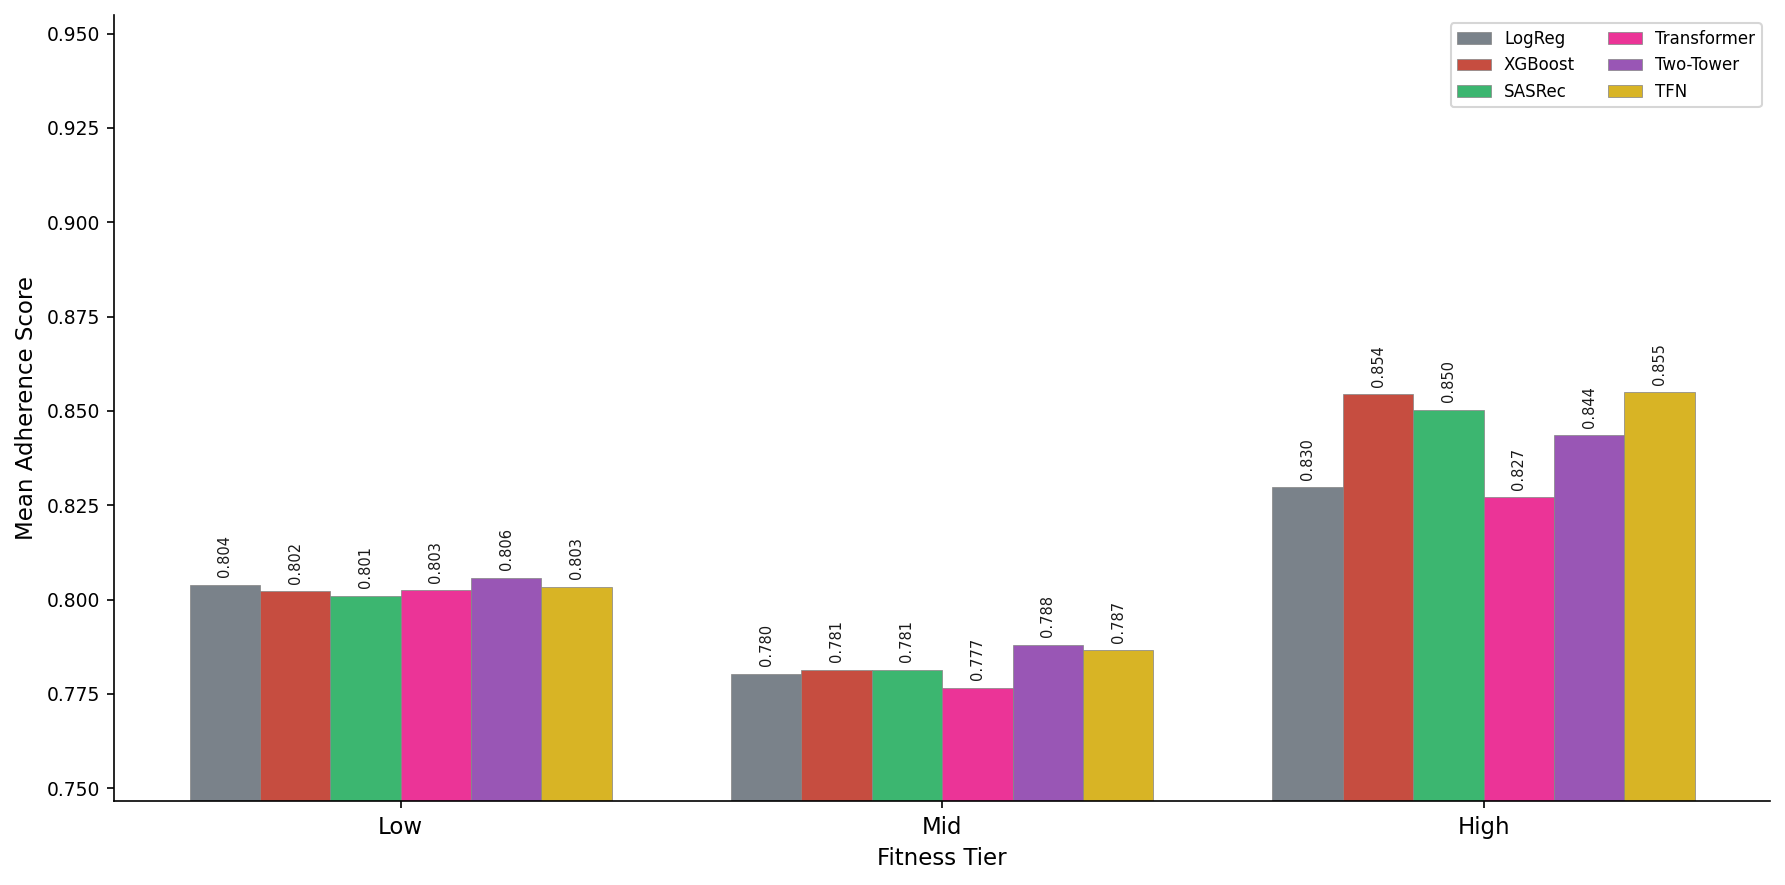

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig05b_tier_boxplot.png


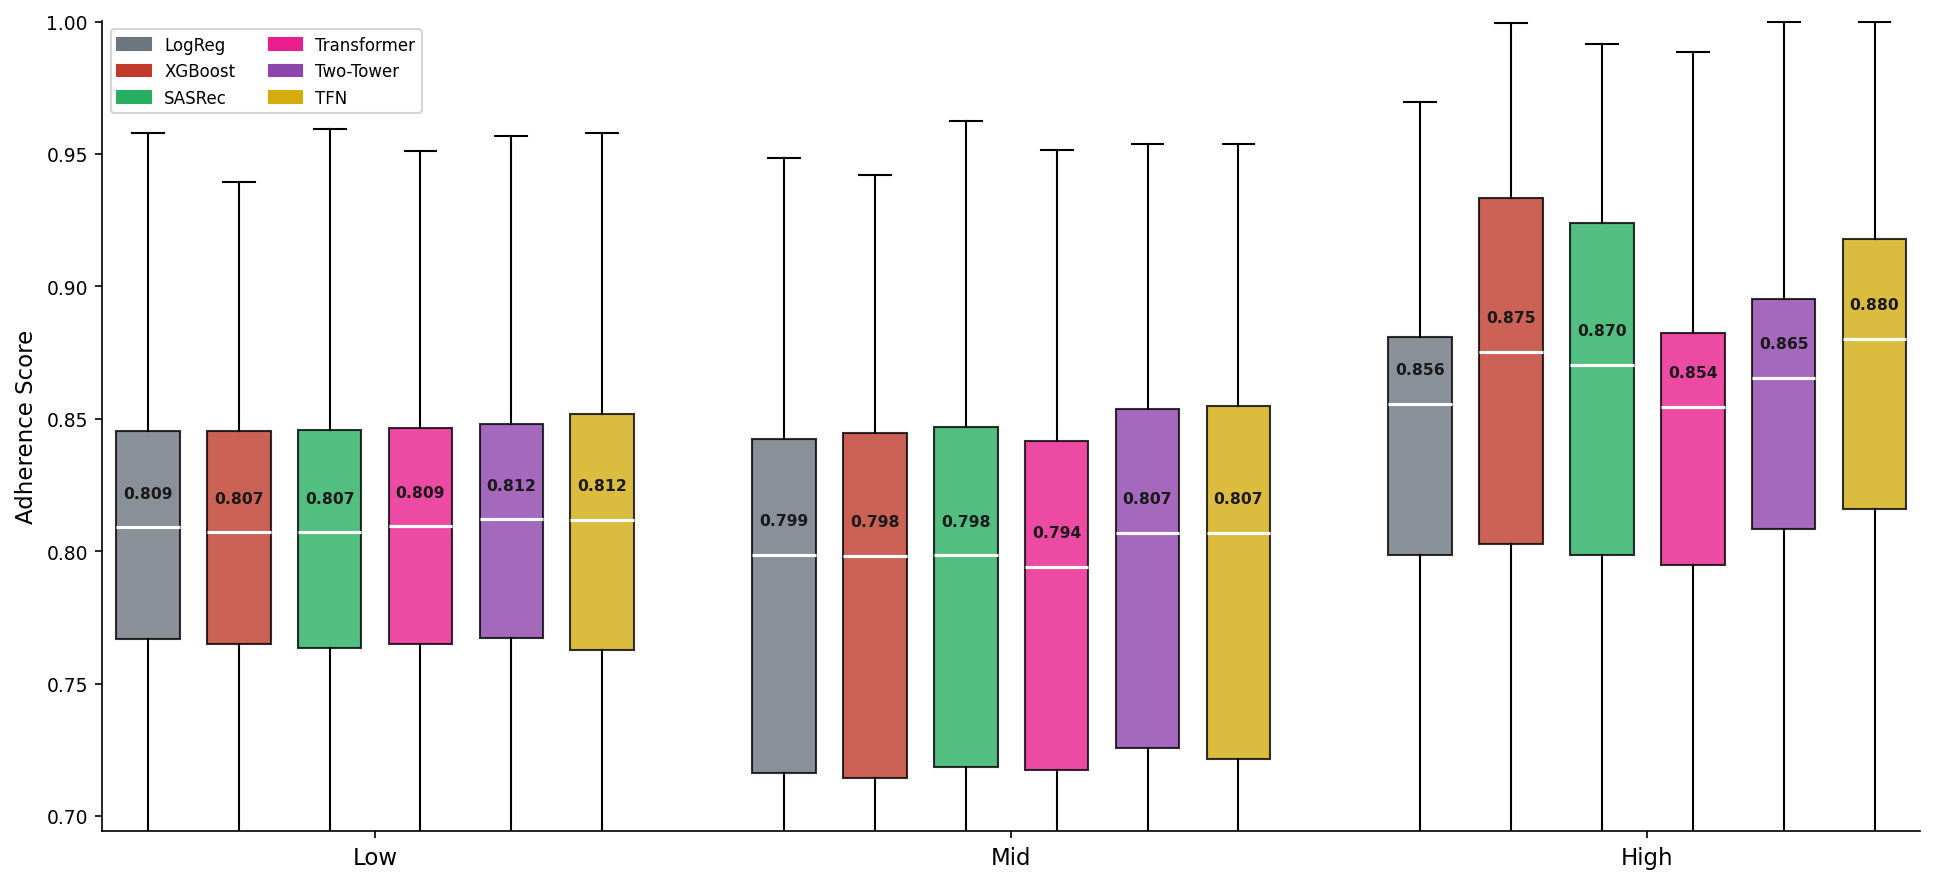

In [8]:
df_s1 = df[df['model'].isin(STUDY1_MODELS)]
tier_labels = [t.capitalize() for t in TIER_ORDER]

# Fig 05a — Grouped bar
fig, ax = plt.subplots(figsize=(12,6))
x = np.arange(len(TIER_ORDER)); width = 0.13
all_vals = []
for i, m in enumerate(STUDY1_MODELS):
    means = [df_s1[(df_s1['model']==m)&(df_s1['fitness_tier']==t)]['avg_adherence_score'].mean()
             for t in TIER_ORDER]
    all_vals.extend(means)
    bars = ax.bar(x+i*width, means, width, label=MODEL_LABELS[m],
                  color=MODEL_COLORS[m], edgecolor='#888888', linewidth=0.4, alpha=0.9)
    for bar, val in zip(bars, means):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7, rotation=90, color='#1a1a1a')
ax.set_xticks(x+width*2.5); ax.set_xticklabels(tier_labels, fontsize=11)
ax.set_xlabel('Fitness Tier', fontsize=11); ax.set_ylabel('Mean Adherence Score', fontsize=11)
ax.legend(fontsize=8, ncol=2)
mn, mx = min(all_vals), max(all_vals)
ax.set_ylim(max(0, mn-0.03), mx+0.10)
plt.tight_layout(); save_fig('fig05a_tier_bar.png')

# Fig 05b — Boxplots per tier with median annotations
fig, ax = plt.subplots(figsize=(13,6))
gap = len(STUDY1_MODELS)+1
positions = {t: [1+j+t_idx*gap for j in range(len(STUDY1_MODELS))]
             for t_idx, t in enumerate(TIER_ORDER)}
tick_pos = [np.mean(positions[t]) for t in TIER_ORDER]
for tier in TIER_ORDER:
    tier_data = [df_s1[(df_s1['model']==m)&(df_s1['fitness_tier']==tier)]
                 ['avg_adherence_score'].dropna().values for m in STUDY1_MODELS]
    bp = ax.boxplot(tier_data, positions=positions[tier], patch_artist=True,
                    widths=0.7, medianprops={'color':'white','linewidth':1.5})
    for patch, m in zip(bp['boxes'], STUDY1_MODELS):
        patch.set_facecolor(MODEL_COLORS[m]); patch.set_alpha(0.8)
    for pos, m, vals in zip(positions[tier], STUDY1_MODELS, tier_data):
        med = np.median(vals)
        ax.text(pos, med+0.01, f'{med:.3f}', ha='center', va='bottom',
                fontsize=7.5, color='#1a1a1a', fontweight='bold')
ax.set_xticks(tick_pos); ax.set_xticklabels(tier_labels, fontsize=11)
ax.set_ylabel('Adherence Score', fontsize=11)
all_meds = [np.median(df_s1[(df_s1['model']==m)&(df_s1['fitness_tier']==t)]['avg_adherence_score'].dropna().values)
            for m in STUDY1_MODELS for t in TIER_ORDER]
mn, mx = min(all_meds), max(all_meds)
ax.set_ylim(max(0, mn-0.10), mx+0.12)
ax.legend(handles=[mpatches.Patch(color=MODEL_COLORS[m], label=MODEL_LABELS[m]) for m in STUDY1_MODELS],
          fontsize=8, ncol=2)
plt.tight_layout(); save_fig('fig05b_tier_boxplot.png')

## 7. Weekly Adherence Trajectory (Study 1)

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig06a_trajectory_all.png


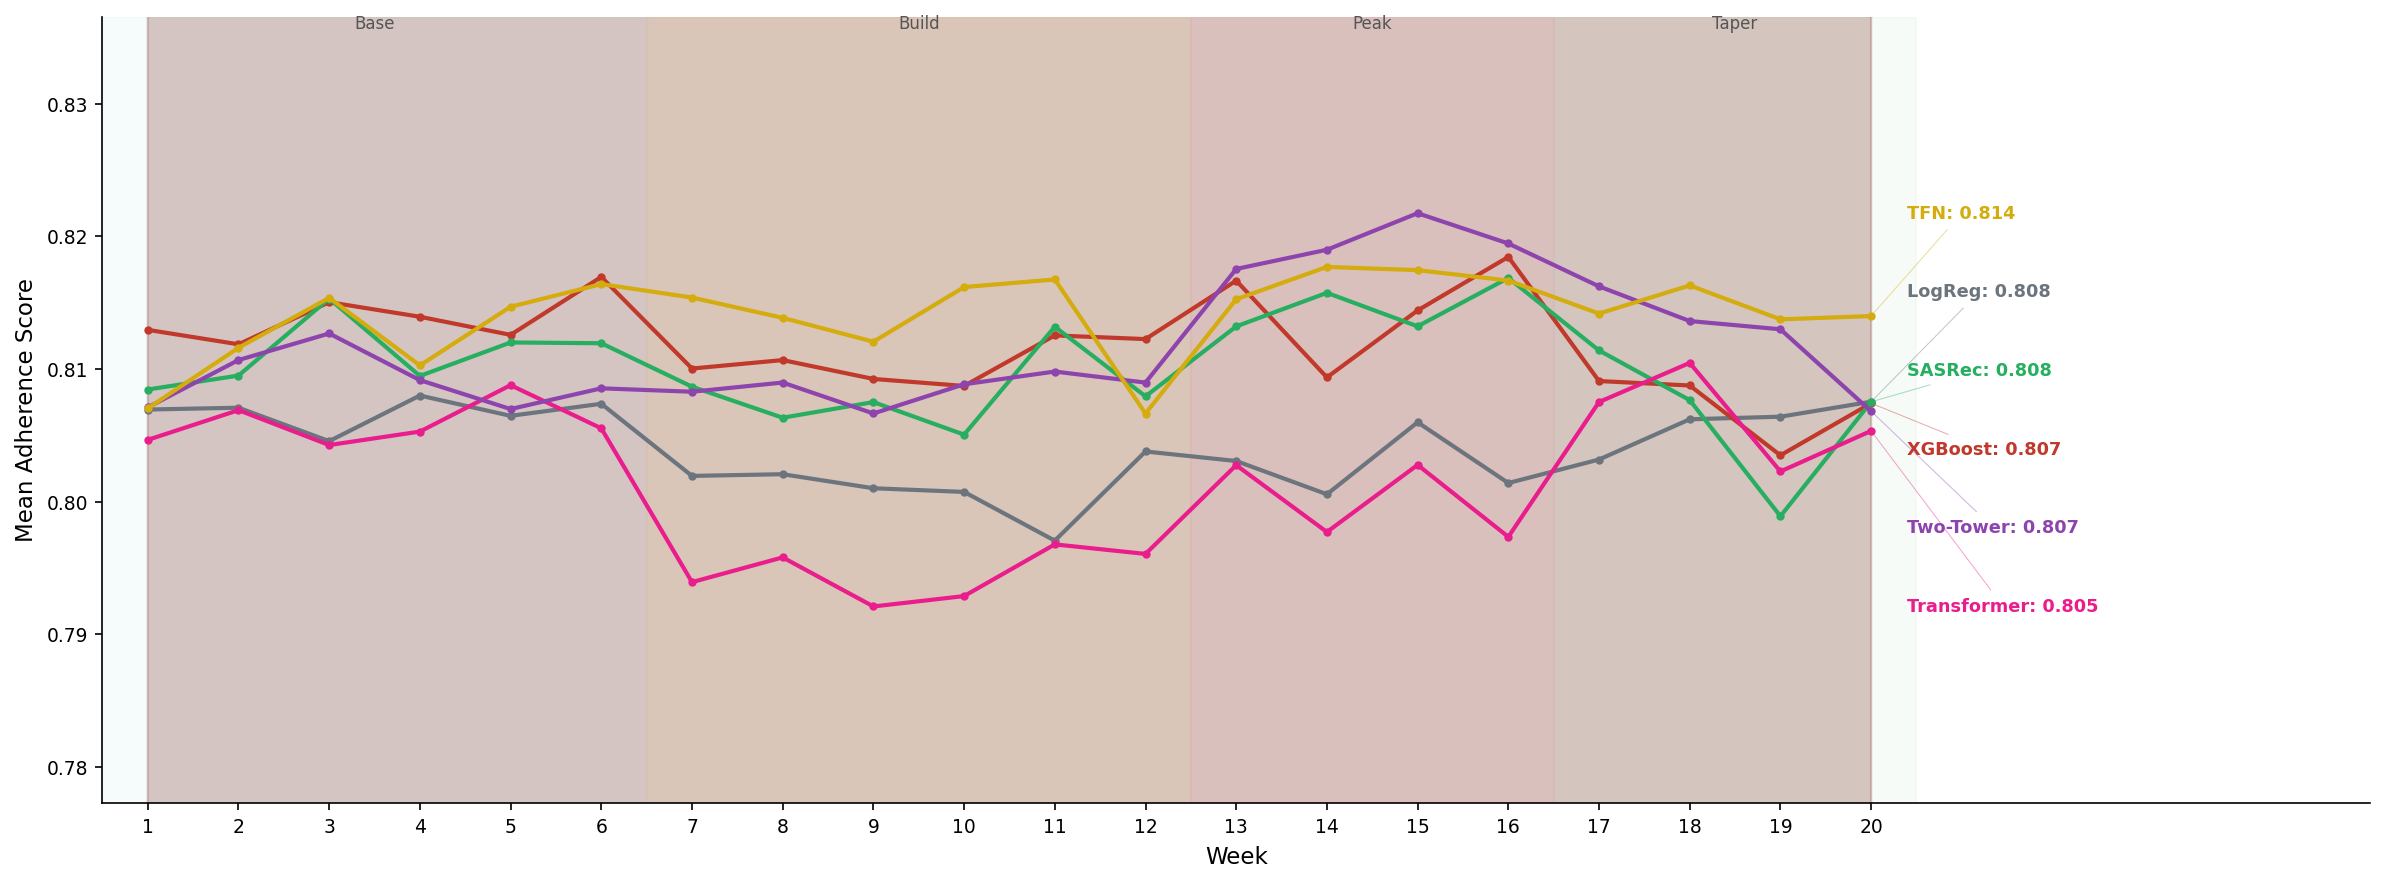

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig06b_trajectory_pa_vs_sd.png


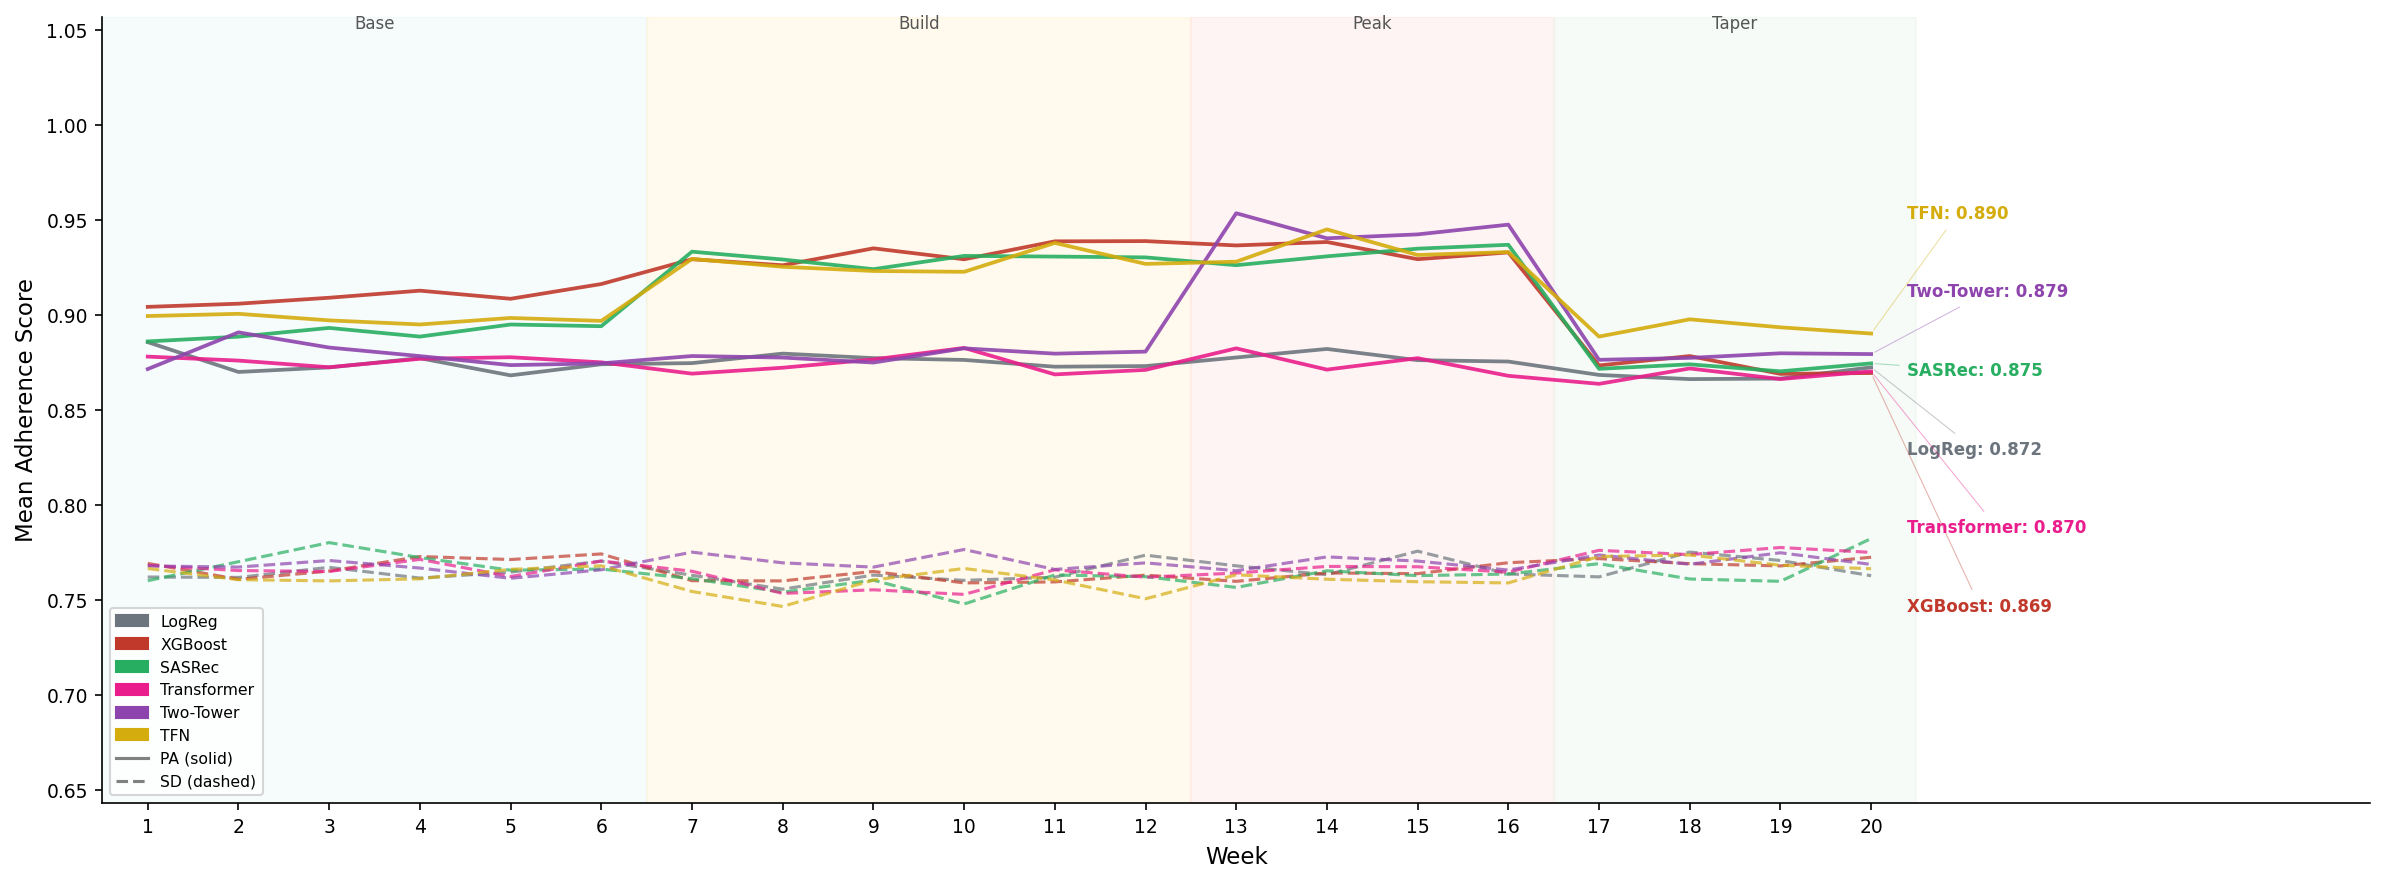

In [9]:
df_s1 = df[df['model'].isin(STUDY1_MODELS)]

def shade_phases(ax):
    for start, end, label, color in [
        (0.5, 6.5,'Base','#E8F4F8'),(6.5,12.5,'Build','#FFF3CD'),
        (12.5,16.5,'Peak','#FFE0E0'),(16.5,20.5,'Taper','#E8F5E9')]:
        ax.axvspan(start, end, alpha=0.35, color=color, zorder=0)
        ax.text((start+end)/2, 0.985, label, ha='center', fontsize=8,
                color='#555555', transform=ax.get_xaxis_transform())

wk_data = {m: df_s1[df_s1['model']==m].groupby('week_number')['avg_adherence_score'].mean()
           for m in STUDY1_MODELS}
all_wk = [v for wk in wk_data.values() for v in wk.values]
mn_wk, mx_wk = min(all_wk), max(all_wk); sp_wk = max(mx_wk-mn_wk, 0.001)
final_wk = sorted([(m, wk_data[m].iloc[-1]) for m in STUDY1_MODELS], key=lambda x: x[1])
rank_wk = {m: i for i,(m,_) in enumerate(final_wk)}

fig, ax = plt.subplots(figsize=(16,6))
shade_phases(ax)
for m in STUDY1_MODELS:
    wk  = wk_data[m]
    std = df_s1[df_s1['model']==m].groupby('week_number')['avg_adherence_score'].std()
    ax.plot(wk.index, wk.values, marker='o', markersize=3, linewidth=2,
            color=MODEL_COLORS[m], label=MODEL_LABELS[m], zorder=3)
    ax.fill_between(wk.index, wk-std, wk+std, alpha=0.07, color=MODEL_COLORS[m])
    y_text = mn_wk + (rank_wk[m]/(len(STUDY1_MODELS)-1))*sp_wk
    ax.annotate(f'{MODEL_LABELS[m]}: {wk.iloc[-1]:.3f}',
                xy=(20, wk.iloc[-1]), xytext=(20.4, y_text),
                fontsize=8.5, color=MODEL_COLORS[m], fontweight='bold', va='center',
                arrowprops=dict(arrowstyle='-', color=MODEL_COLORS[m], lw=0.5, alpha=0.4))
ax.set_xlabel('Week', fontsize=11); ax.set_ylabel('Mean Adherence Score', fontsize=11)
ax.set_xlim(0.5, 25.5); ax.set_xticks(range(1,21))
ax.set_ylim(max(0, mn_wk-sp_wk*0.5), mx_wk+sp_wk*0.5)
plt.tight_layout(); save_fig('fig06a_trajectory_all.png')

# PA vs SD
wk_pa = {m: df_s1[(df_s1['model']==m)&(df_s1['profile_type']=='PA')].groupby('week_number')['avg_adherence_score'].mean() for m in STUDY1_MODELS}
wk_sd = {m: df_s1[(df_s1['model']==m)&(df_s1['profile_type']=='SD')].groupby('week_number')['avg_adherence_score'].mean() for m in STUDY1_MODELS}
all_wk2 = [v for d in [wk_pa,wk_sd] for wk in d.values() for v in wk.values]
mn2, mx2 = min(all_wk2), max(all_wk2); sp2 = max(mx2-mn2, 0.001)
final_pa = sorted([(m, wk_pa[m].iloc[-1]) for m in STUDY1_MODELS], key=lambda x: x[1])
rank_pa = {m: i for i,(m,_) in enumerate(final_pa)}

fig, ax = plt.subplots(figsize=(16,6))
shade_phases(ax)
for m in STUDY1_MODELS:
    ax.plot(wk_pa[m].index, wk_pa[m].values, '-', linewidth=1.8, color=MODEL_COLORS[m], alpha=0.9, zorder=3)
    ax.plot(wk_sd[m].index, wk_sd[m].values, '--', linewidth=1.5, color=MODEL_COLORS[m], alpha=0.7, zorder=3)
    y_text = mn2 + (rank_pa[m]/(len(STUDY1_MODELS)-1))*sp2
    ax.annotate(f'{MODEL_LABELS[m]}: {wk_pa[m].iloc[-1]:.3f}',
                xy=(20, wk_pa[m].iloc[-1]), xytext=(20.4, y_text),
                fontsize=8, color=MODEL_COLORS[m], fontweight='bold', va='center',
                arrowprops=dict(arrowstyle='-', color=MODEL_COLORS[m], lw=0.5, alpha=0.4))
model_patches = [mpatches.Patch(color=MODEL_COLORS[m], label=MODEL_LABELS[m]) for m in STUDY1_MODELS]
ax.legend(handles=model_patches+[plt.Line2D([0],[0],color='gray',linestyle='-',lw=1.5,label='PA (solid)'),
                                   plt.Line2D([0],[0],color='gray',linestyle='--',lw=1.5,label='SD (dashed)')],
          fontsize=7.5, loc='lower left')
ax.set_xlabel('Week', fontsize=11); ax.set_ylabel('Mean Adherence Score', fontsize=11)
ax.set_xlim(0.5, 25.5); ax.set_xticks(range(1,21))
ax.set_ylim(max(0, mn2-sp2*0.5), mx2+sp2*0.5)
plt.tight_layout(); save_fig('fig06b_trajectory_pa_vs_sd.png')

## 8. Study 2 — TFN Ablation Staircase

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig_staircase_a_component.png


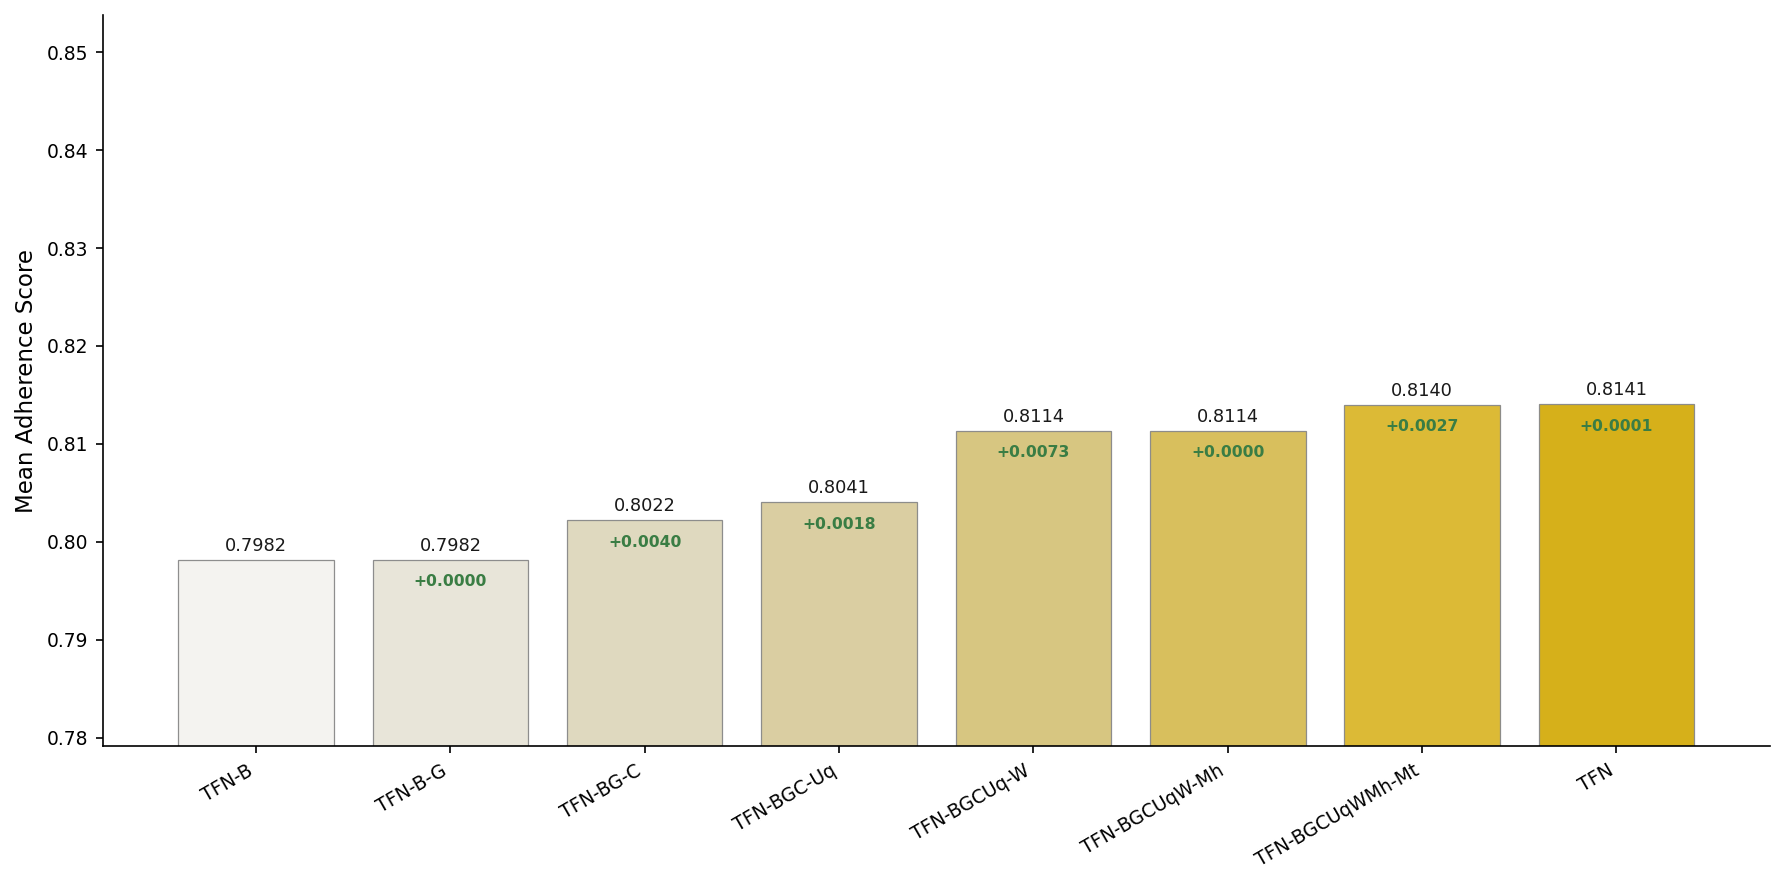

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig_staircase_b_study1_ranked.png


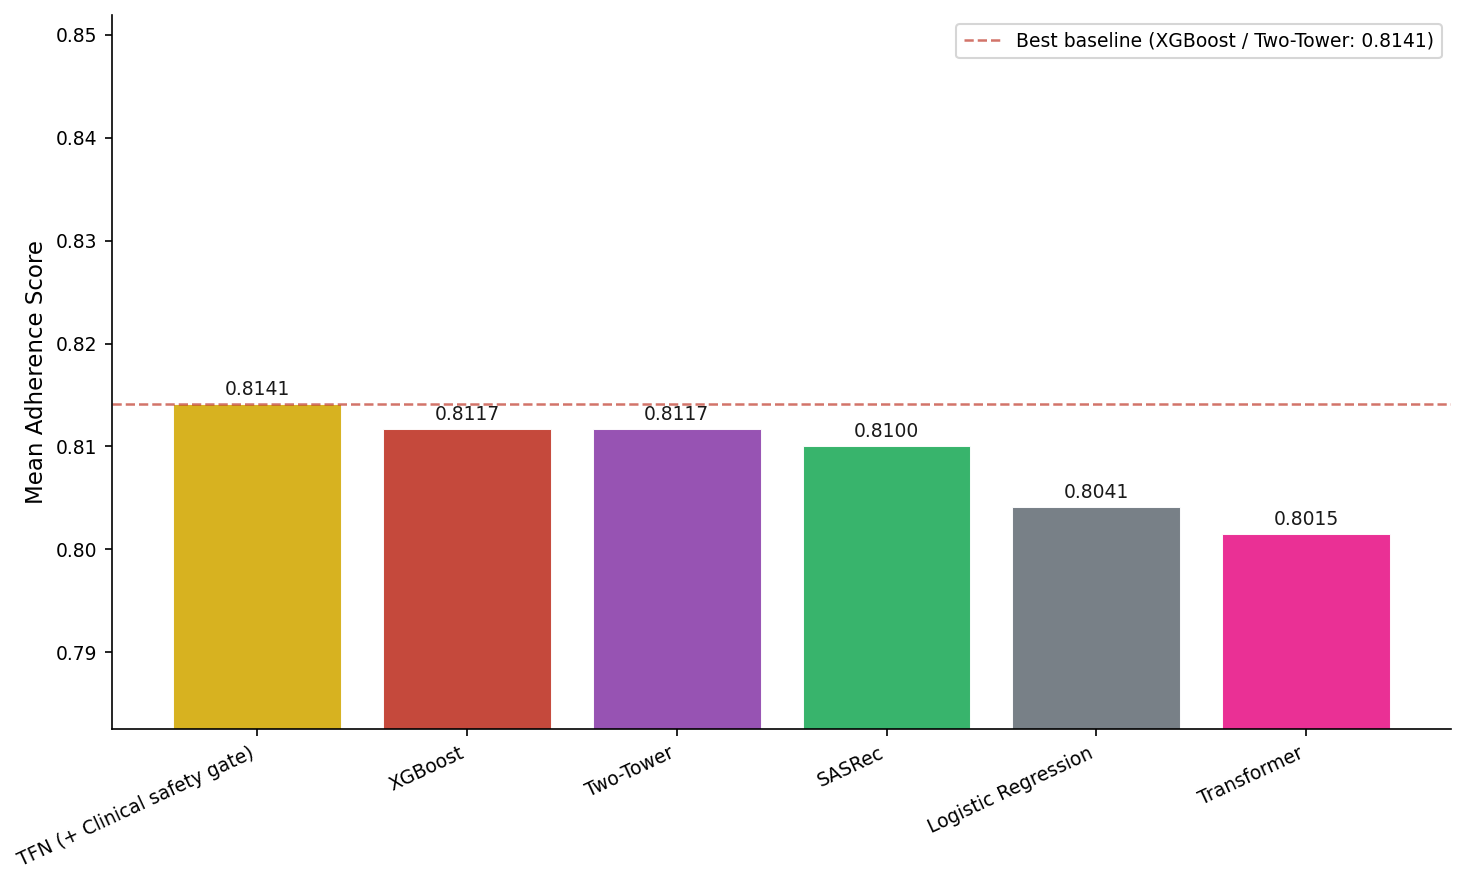

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig_staircase_b_ranked.png


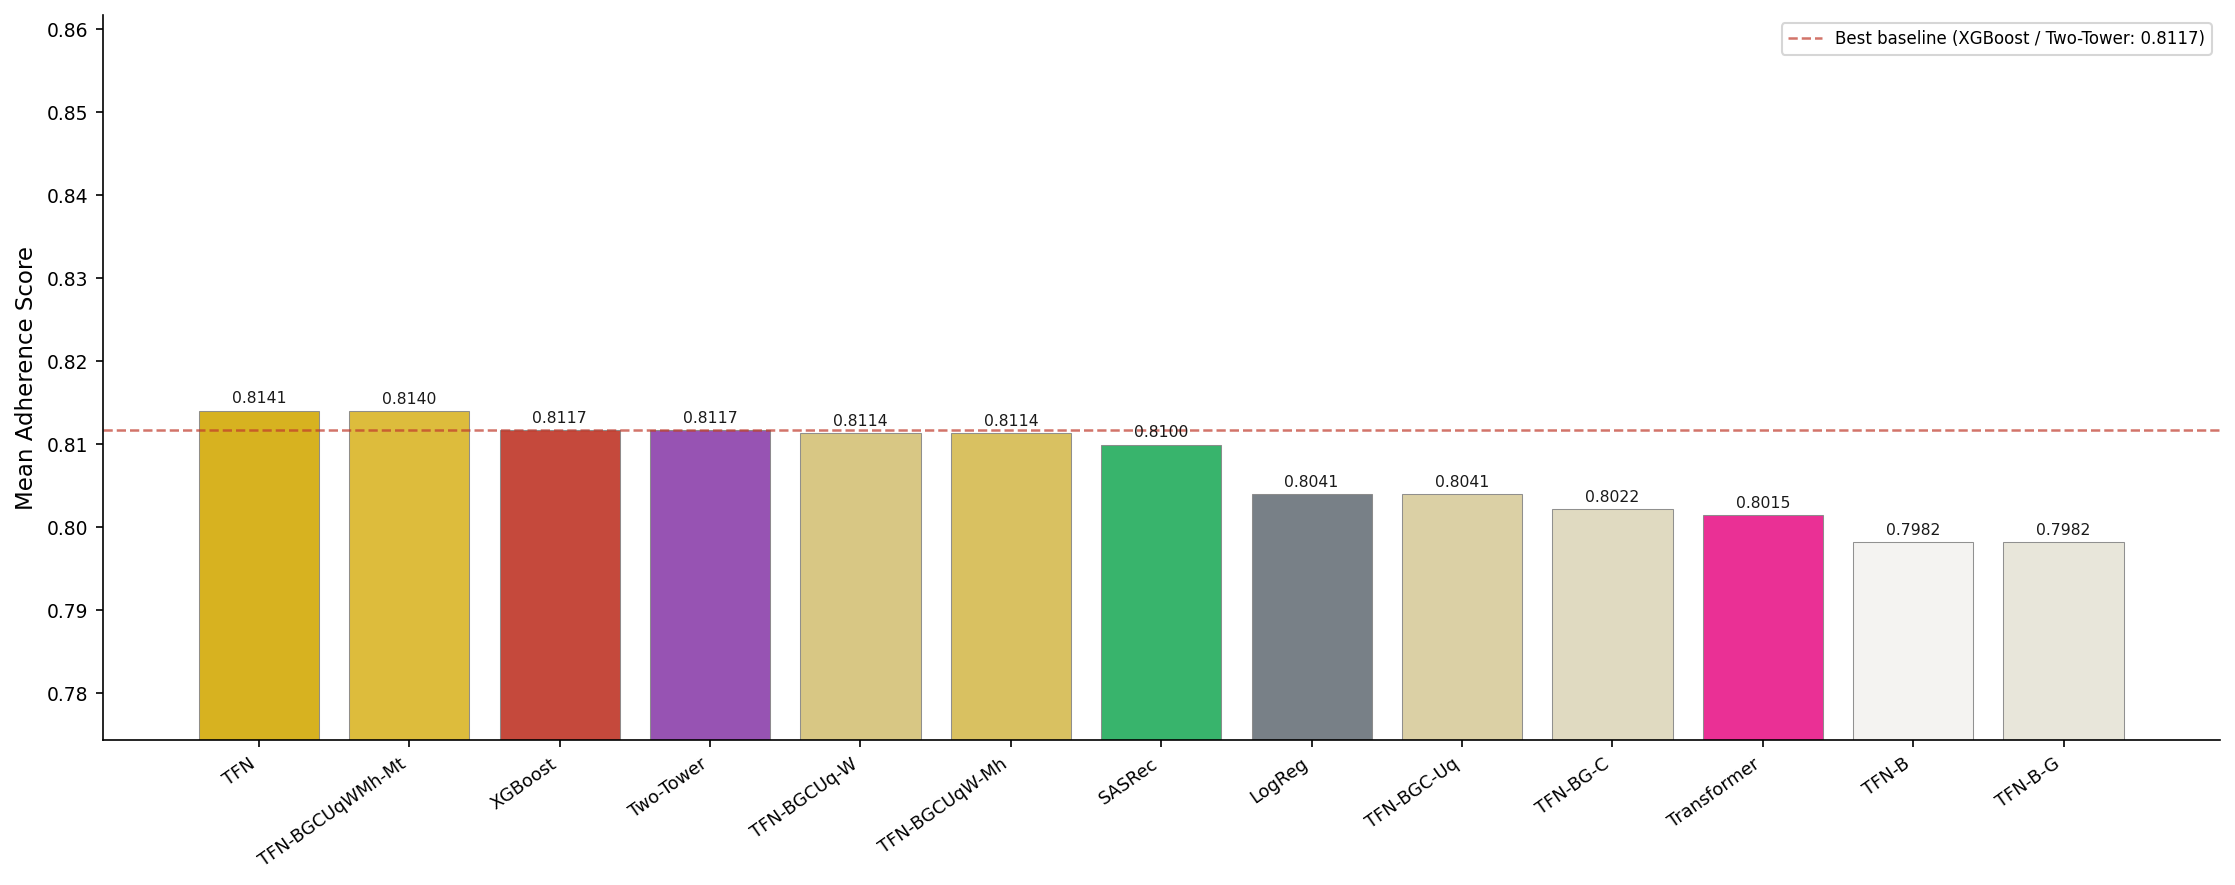

In [10]:
tfn_means   = [df[df['model']==m]['avg_adherence_score'].mean() for m in TFN_ABLATION]
tfn_labels  = [MODEL_LABELS[m] for m in TFN_ABLATION]
tfn_colors  = [MODEL_COLORS[m] for m in TFN_ABLATION]
step_deltas = [None]+[tfn_means[i]-tfn_means[i-1] for i in range(1,len(tfn_means))]

# Fig staircase-a — Study 2 staircase with per-step delta
fig, ax = plt.subplots(figsize=(12,6))
bars = ax.bar(range(len(TFN_ABLATION)), tfn_means,
              color=tfn_colors, edgecolor='#888888', linewidth=0.6, alpha=0.95)
annotate_bars(ax, bars, tfn_means, fmt='{:.4f}', offset=0.0005, fontsize=8.5)
for bar, delta in zip(bars, step_deltas):
    if delta is None: continue
    sign = '+' if delta >= 0 else ''
    color = '#3A7D44' if delta >= 0 else '#C0392B'
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()-0.0015,
            f'{sign}{delta:.4f}', ha='center', va='top', fontsize=7.5, color=color, fontweight='bold')
ax.set_xticks(range(len(TFN_ABLATION)))
ax.set_xticklabels(tfn_labels, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Mean Adherence Score', fontsize=11)
mn, mx = min(tfn_means), max(tfn_means); spread = max(mx-mn, 0.005)
ax.set_ylim(mn-spread*1.2, mx+spread*2.5)
plt.tight_layout(); save_fig('fig_staircase_a_component.png')

# Fig staircase-b — Study 1: 6 models ranked
df_s1 = df[df['model'].isin(STUDY1_MODELS)]
s1_means = sorted([(m, df_s1[df_s1['model']==m]['avg_adherence_score'].mean()) for m in STUDY1_MODELS],
                  key=lambda x: x[1], reverse=True)
s1_sorted = [x[0] for x in s1_means]; s1_vals = [x[1] for x in s1_means]
best_baseline_mean  = df_s1[df_s1['model'].isin(STUDY1_MODELS)]['avg_adherence_score'].groupby(
    df_s1['model']).mean().max()
best_baseline_label = f'Best baseline (XGBoost / Two-Tower: {best_baseline_mean:.4f})'

fig, ax = plt.subplots(figsize=(10,6))
bars_s1 = ax.bar(range(len(STUDY1_MODELS)), s1_vals,
                 color=[MODEL_COLORS[m] for m in s1_sorted], edgecolor='white', linewidth=0.5, alpha=0.92)
annotate_bars(ax, bars_s1, s1_vals, fmt='{:.4f}', offset=0.0005, fontsize=9)
ax.set_xticks(range(len(STUDY1_MODELS)))
ax.set_xticklabels([MODEL_LABELS_FULL[m] for m in s1_sorted], rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Mean Adherence Score', fontsize=11)
ax.axhline(best_baseline_mean, color='#C0392B', linestyle='--', linewidth=1.2, alpha=0.7,
           label=best_baseline_label)
ax.legend(fontsize=9)
mn_s1, mx_s1 = min(s1_vals), max(s1_vals); sp_s1 = max(mx_s1-mn_s1, 0.005)
ax.set_ylim(mn_s1-sp_s1*1.5, mx_s1+sp_s1*3.0)
plt.tight_layout(); save_fig('fig_staircase_b_study1_ranked.png')

# Fig staircase-c — All 13 ranked (supplementary)
all_means = sorted([(m, df[df['model']==m]['avg_adherence_score'].mean()) for m in MODELS],
                   key=lambda x: x[1], reverse=True)
sorted_models = [x[0] for x in all_means]; sorted_vals = [x[1] for x in all_means]
fig, ax = plt.subplots(figsize=(15,6))
bars2 = ax.bar(range(len(MODELS)), sorted_vals,
               color=[MODEL_COLORS[m] for m in sorted_models], edgecolor='#888888', linewidth=0.5, alpha=0.92)
annotate_bars(ax, bars2, sorted_vals, fmt='{:.4f}', offset=0.0005, fontsize=7.5)
ax.set_xticks(range(len(MODELS)))
ax.set_xticklabels([MODEL_LABELS[m] for m in sorted_models], rotation=35, ha='right', fontsize=8.5)
ax.set_ylabel('Mean Adherence Score', fontsize=11)
best_baseline_mean_all = df[df['model'].isin(['xgb','two_tower'])]['avg_adherence_score'].groupby(
    df['model']).mean().max()
ax.axhline(best_baseline_mean_all, color='#C0392B', linestyle='--', linewidth=1.2, alpha=0.7,
           label=f'Best baseline (XGBoost / Two-Tower: {best_baseline_mean_all:.4f})')
ax.legend(fontsize=8)
mn_all, mx_all = min(sorted_vals), max(sorted_vals); sp_all = max(mx_all-mn_all, 0.005)
ax.set_ylim(mn_all-sp_all*1.5, mx_all+sp_all*3.0)
plt.tight_layout(); save_fig('fig_staircase_b_ranked.png')

## 9. Statistical Tests — Kruskal-Wallis

          test        H  df  p_value  epsilon_squared  n_models  N_total
Kruskal-Wallis 185.1099  12      0.0           0.0042        13    41600
[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig07a_kw_h_statistic.png


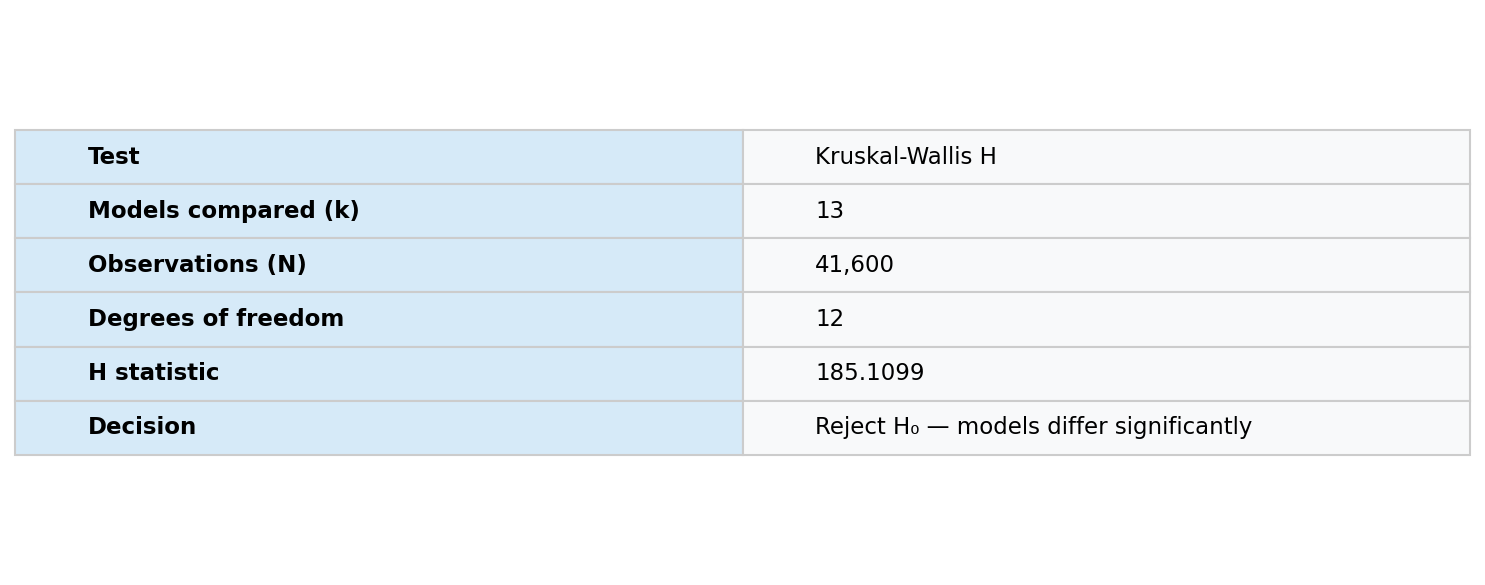

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig07b_effect_size.png


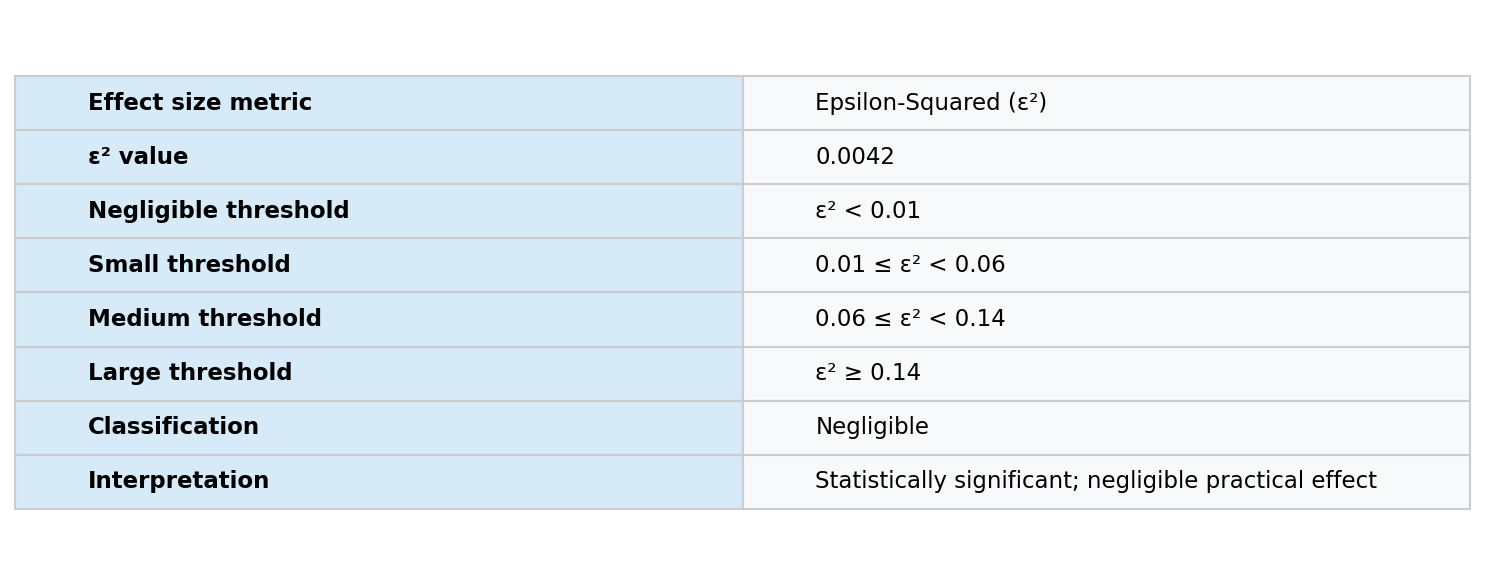

In [11]:
row = df_stats.iloc[0]
print(df_stats[['test','H','df','p_value','epsilon_squared','n_models','N_total']].to_string(index=False))

def kw_table(ax, table_data):
    tbl = ax.table(cellText=table_data, loc='center', cellLoc='left')
    tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1, 1.8)
    for (r,c), cell in tbl.get_celld().items():
        cell.set_edgecolor('#CCCCCC')
        cell.set_facecolor('#D6EAF8' if c==0 else '#F8F9FA')
        if c == 0: cell.set_text_props(fontweight='bold')
    ax.axis('off')

fig, ax = plt.subplots(figsize=(10,4))
kw_table(ax, [
    ['Test',                   'Kruskal-Wallis H'],
    ['Models compared (k)',    str(int(row['n_models']))],
    ['Observations (N)',       f"{int(row['N_total']):,}"],
    ['Degrees of freedom',     str(int(row['df']))],
    ['H statistic',            f"{row['H']:.4f}"],
    ['Decision',               'Reject H\u2080 \u2014 models differ significantly'],
])
plt.tight_layout(); save_fig('fig07a_kw_h_statistic.png')

eps2 = float(row['epsilon_squared'])
effect_label = 'Large' if eps2>=0.14 else ('Medium' if eps2>=0.06 else ('Small' if eps2>=0.01 else 'Negligible'))
fig, ax = plt.subplots(figsize=(10,4))
kw_table(ax, [
    ['Effect size metric',    'Epsilon-Squared (\u03b5\u00b2)'],
    ['\u03b5\u00b2 value',    f"{eps2:.4f}"],
    ['Negligible threshold',  '\u03b5\u00b2 < 0.01'],
    ['Small threshold',       '0.01 \u2264 \u03b5\u00b2 < 0.06'],
    ['Medium threshold',      '0.06 \u2264 \u03b5\u00b2 < 0.14'],
    ['Large threshold',       '\u03b5\u00b2 \u2265 0.14'],
    ['Classification',        effect_label],
    ['Interpretation',        'Statistically significant; negligible practical effect'],
])
plt.tight_layout(); save_fig('fig07b_effect_size.png')

## 10. Pairwise Dunn Tests — Study 1

Study 1 pairs: 15  Significant: 5
[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig08a_pairwise_heatmap.png


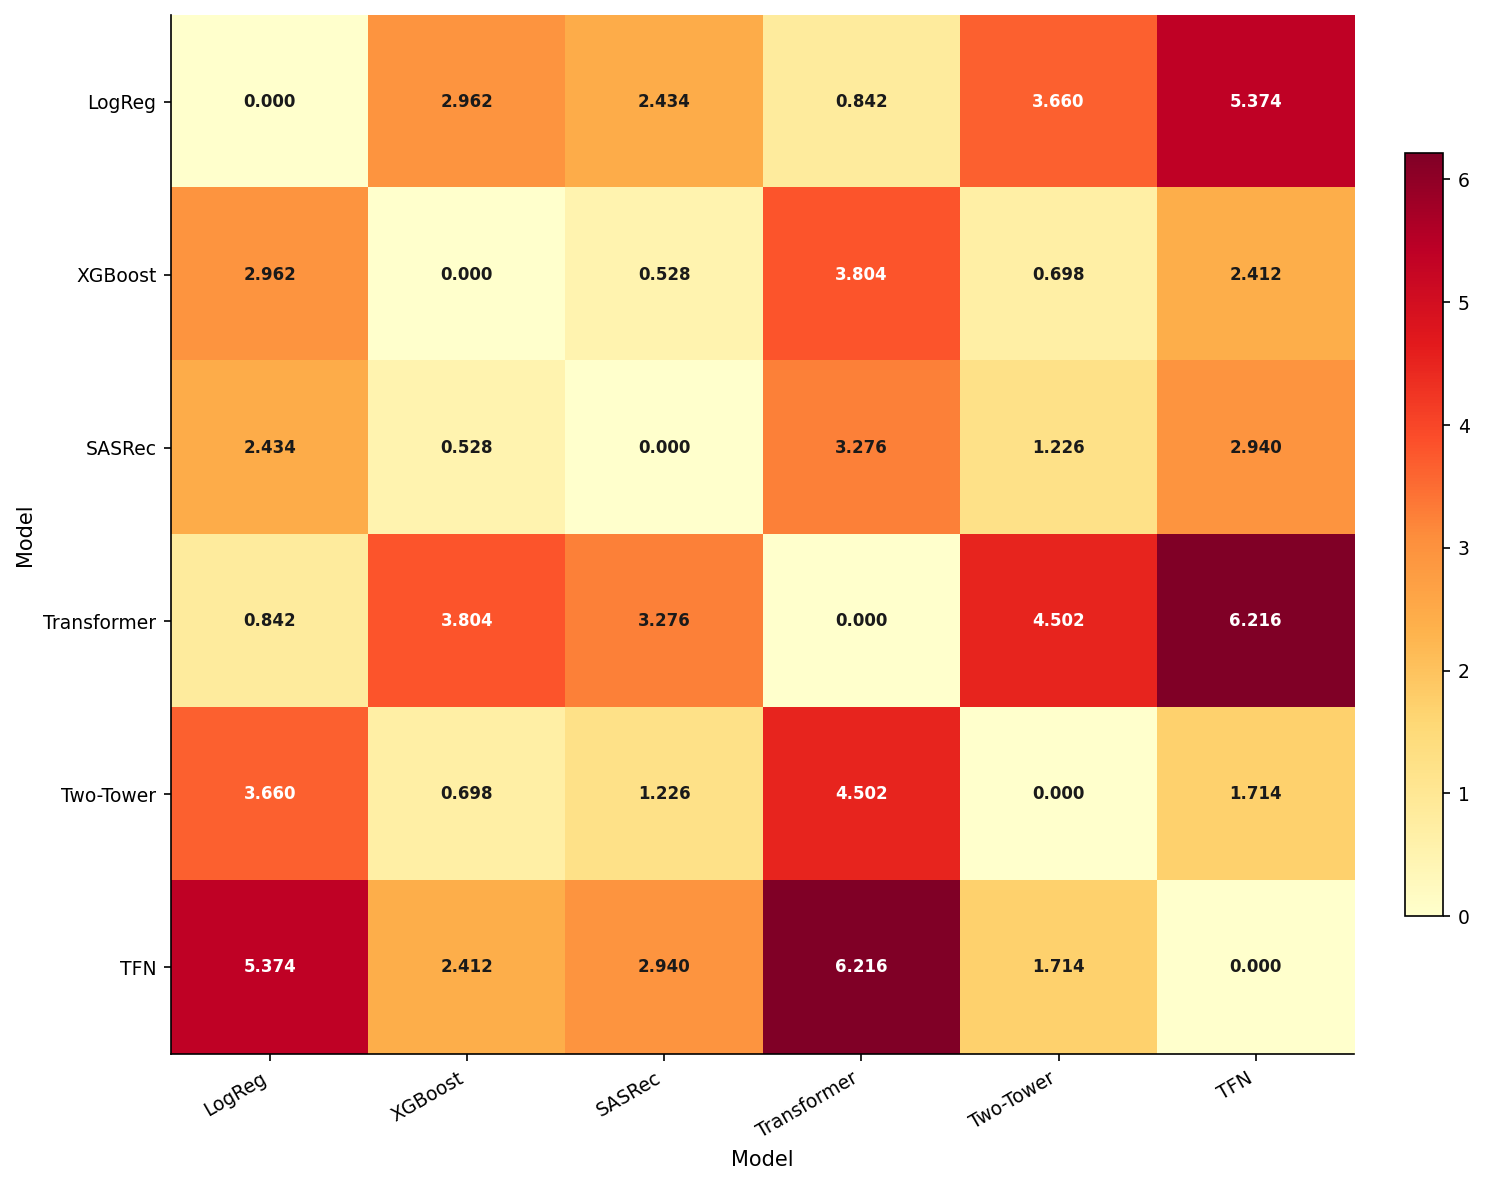

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig08b_pairwise_z_significant.png


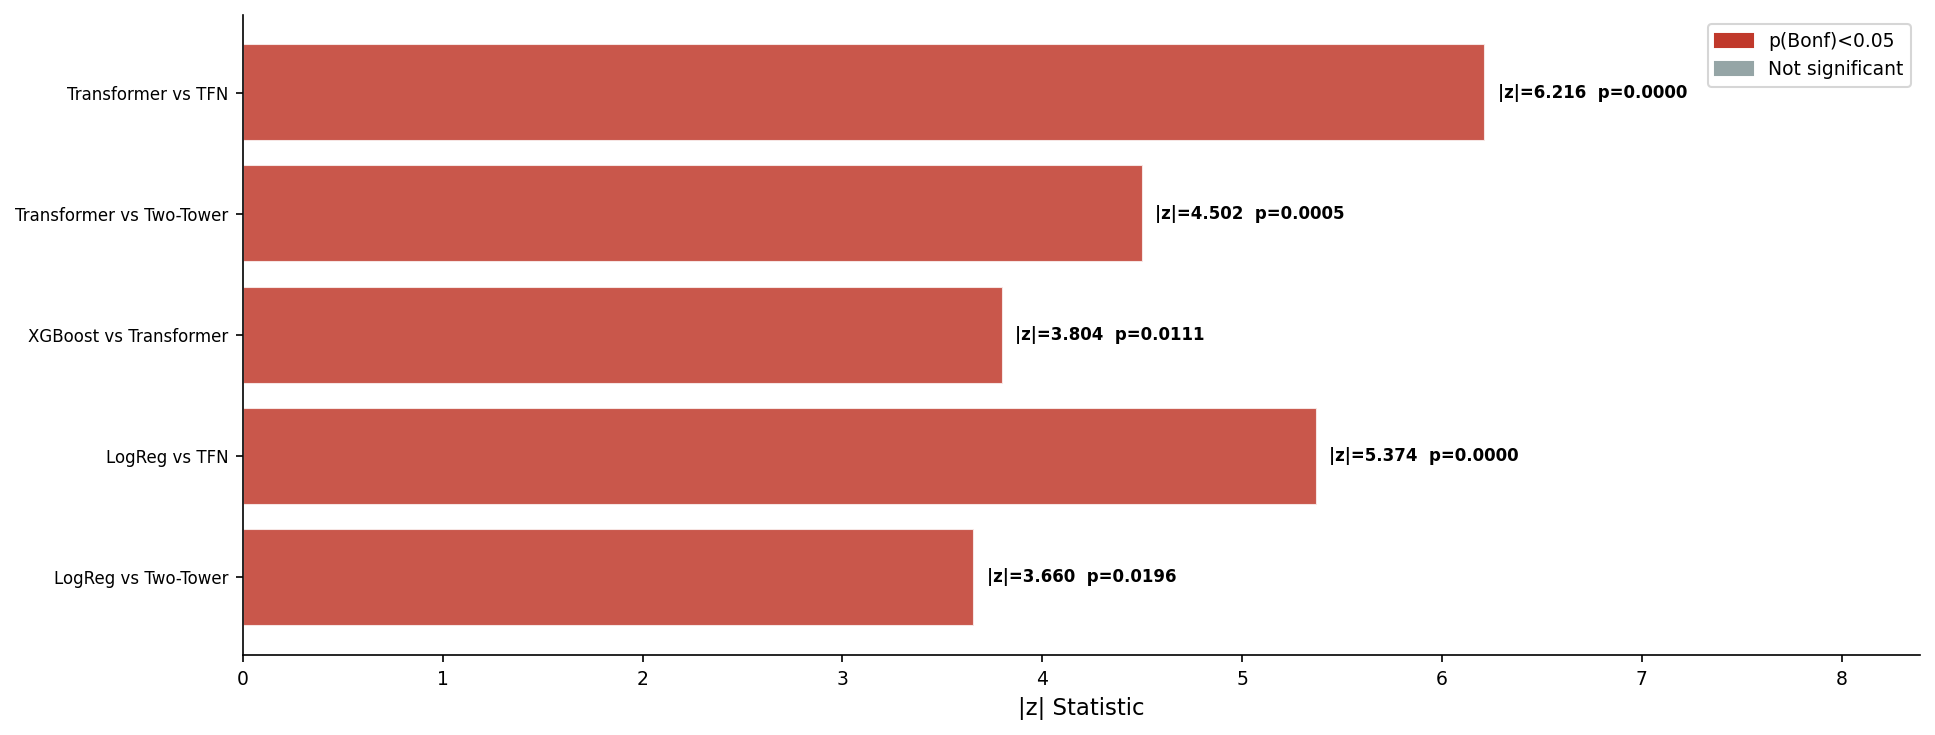

In [12]:
df_pair_s1 = df_pair[df_pair['model_a'].isin(STUDY1_MODELS) & df_pair['model_b'].isin(STUDY1_MODELS)].copy()
print(f'Study 1 pairs: {len(df_pair_s1)}  Significant: {df_pair_s1["significant"].sum()}')

n = len(STUDY1_MODELS)
z_matrix = np.zeros((n,n))
for _, row in df_pair_s1.iterrows():
    if row['model_a'] in STUDY1_MODELS and row['model_b'] in STUDY1_MODELS:
        i = STUDY1_MODELS.index(row['model_a']); j = STUDY1_MODELS.index(row['model_b'])
        z_matrix[i,j] = z_matrix[j,i] = abs(row['z_statistic'])
labels_s1 = [MODEL_LABELS[m] for m in STUDY1_MODELS]

fig, ax = plt.subplots(figsize=(10,8))
vmin, vmax = z_matrix.min(), z_matrix.max()
im = ax.imshow(z_matrix, cmap='YlOrRd', aspect='auto', vmin=vmin-0.001, vmax=vmax+0.001)
ax.set_xticks(range(n)); ax.set_xticklabels(labels_s1, fontsize=9, rotation=30, ha='right')
ax.set_yticks(range(n)); ax.set_yticklabels(labels_s1, fontsize=9)
for i in range(n):
    for j in range(n):
        val = z_matrix[i,j]
        norm = (val-vmin)/max(vmax-vmin, 1e-9)
        ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=8,
                color='white' if norm>0.55 else '#1a1a1a', fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
ax.set_xlabel('Model', fontsize=10); ax.set_ylabel('Model', fontsize=10)
plt.tight_layout(); save_fig('fig08a_pairwise_heatmap.png')

sig_pairs = df_pair_s1[df_pair_s1['significant']].copy()
if len(sig_pairs) > 0:
    pair_labels = [f"{MODEL_LABELS.get(r.model_a,r.model_a)} vs {MODEL_LABELS.get(r.model_b,r.model_b)}"
                   for _,r in sig_pairs.iterrows()]
    z_vals = sig_pairs['z_statistic'].abs().values
    p_vals = sig_pairs['p_bonferroni'].values
    bar_colors = ['#C0392B' if p<0.05 else '#95A5A6' for p in p_vals]
    fig, ax = plt.subplots(figsize=(13, max(5, len(sig_pairs)*0.40)))
    bars = ax.barh(range(len(pair_labels)), z_vals, color=bar_colors, edgecolor='white', alpha=0.85)
    ax.set_yticks(range(len(pair_labels))); ax.set_yticklabels(pair_labels, fontsize=8)
    ax.set_xlabel('|z| Statistic', fontsize=11)
    mx_z = z_vals.max() if len(z_vals)>0 else 1
    for bar, val, p in zip(bars, z_vals, p_vals):
        ax.text(val+mx_z*0.01, bar.get_y()+bar.get_height()/2,
                f'|z|={val:.3f}  p={p:.4f}', va='center', fontsize=8, fontweight='bold')
    ax.set_xlim(0, mx_z*1.35)
    ax.legend(handles=[mpatches.Patch(color='#C0392B',label='p(Bonf)<0.05'),
                       mpatches.Patch(color='#95A5A6',label='Not significant')], fontsize=9)
    plt.tight_layout(); save_fig('fig08b_pairwise_z_significant.png')
else:
    print('No significant Study 1 pairs — fig08b not generated.')

## 11. RQ1 — Progressive Overload Compliance (Study 1)

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig09a_rq1_overload.png


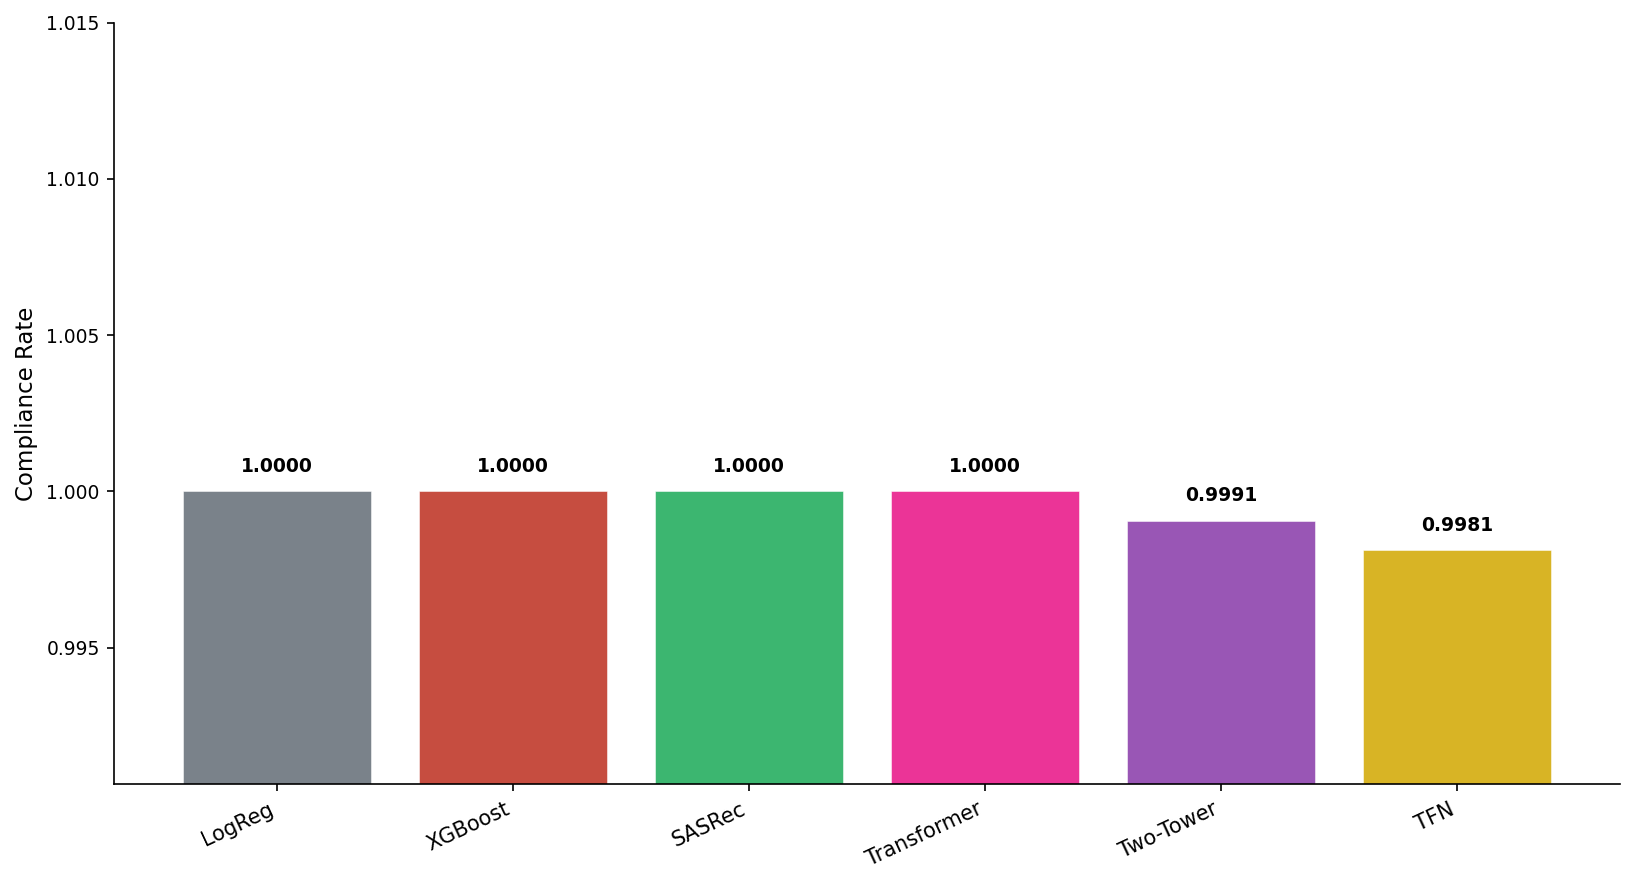

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig09b_rq1_adaptation.png


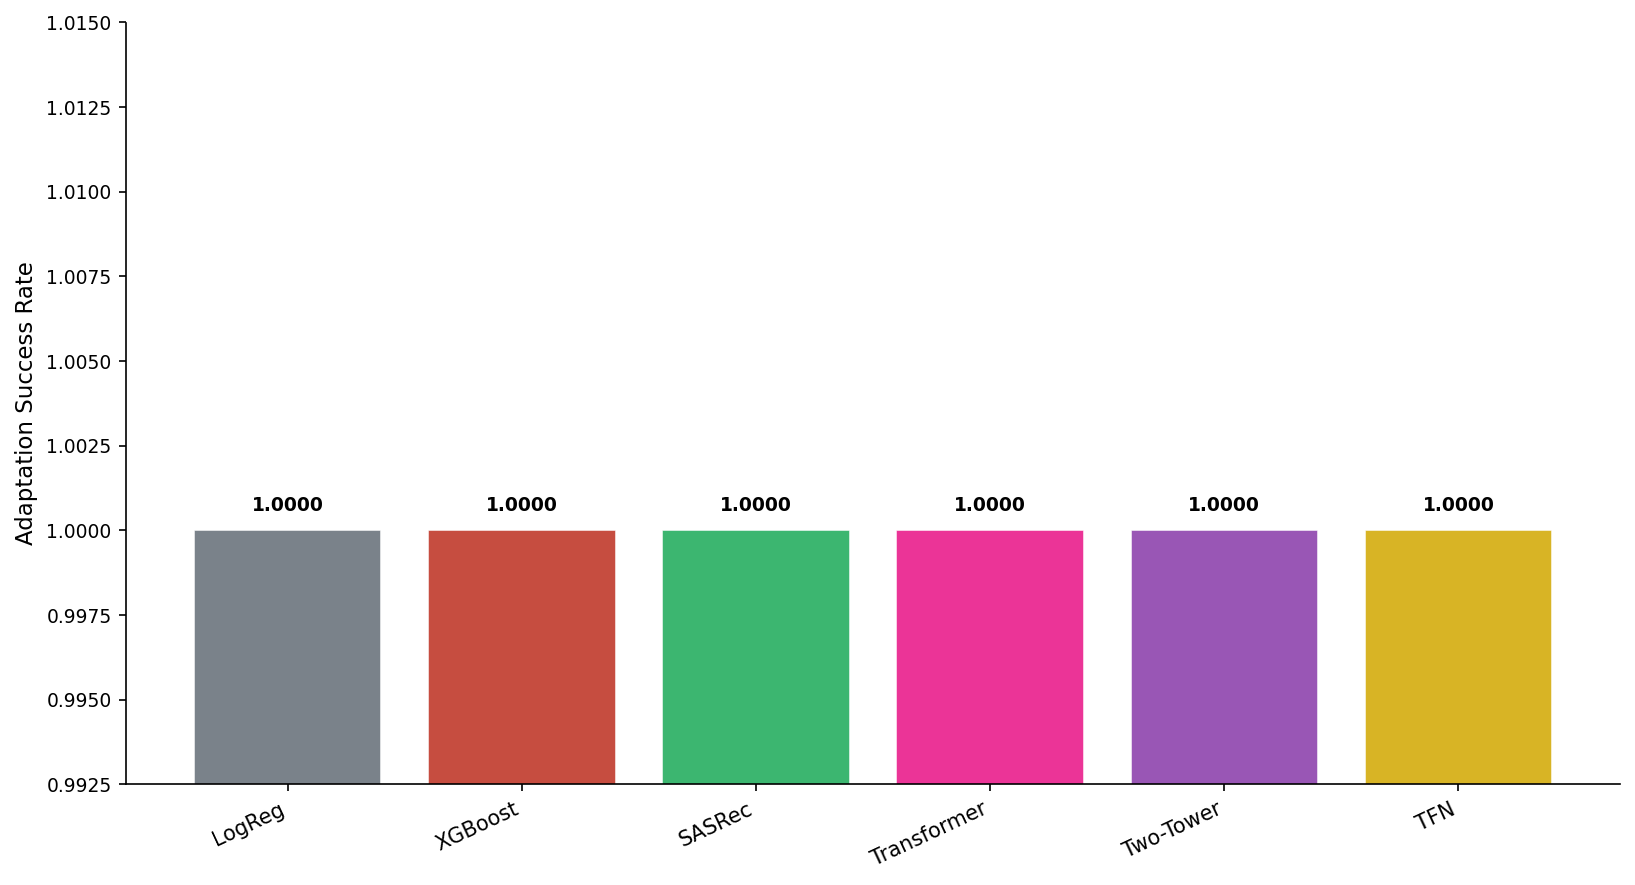

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig09c_rq1_rmse_distance.png


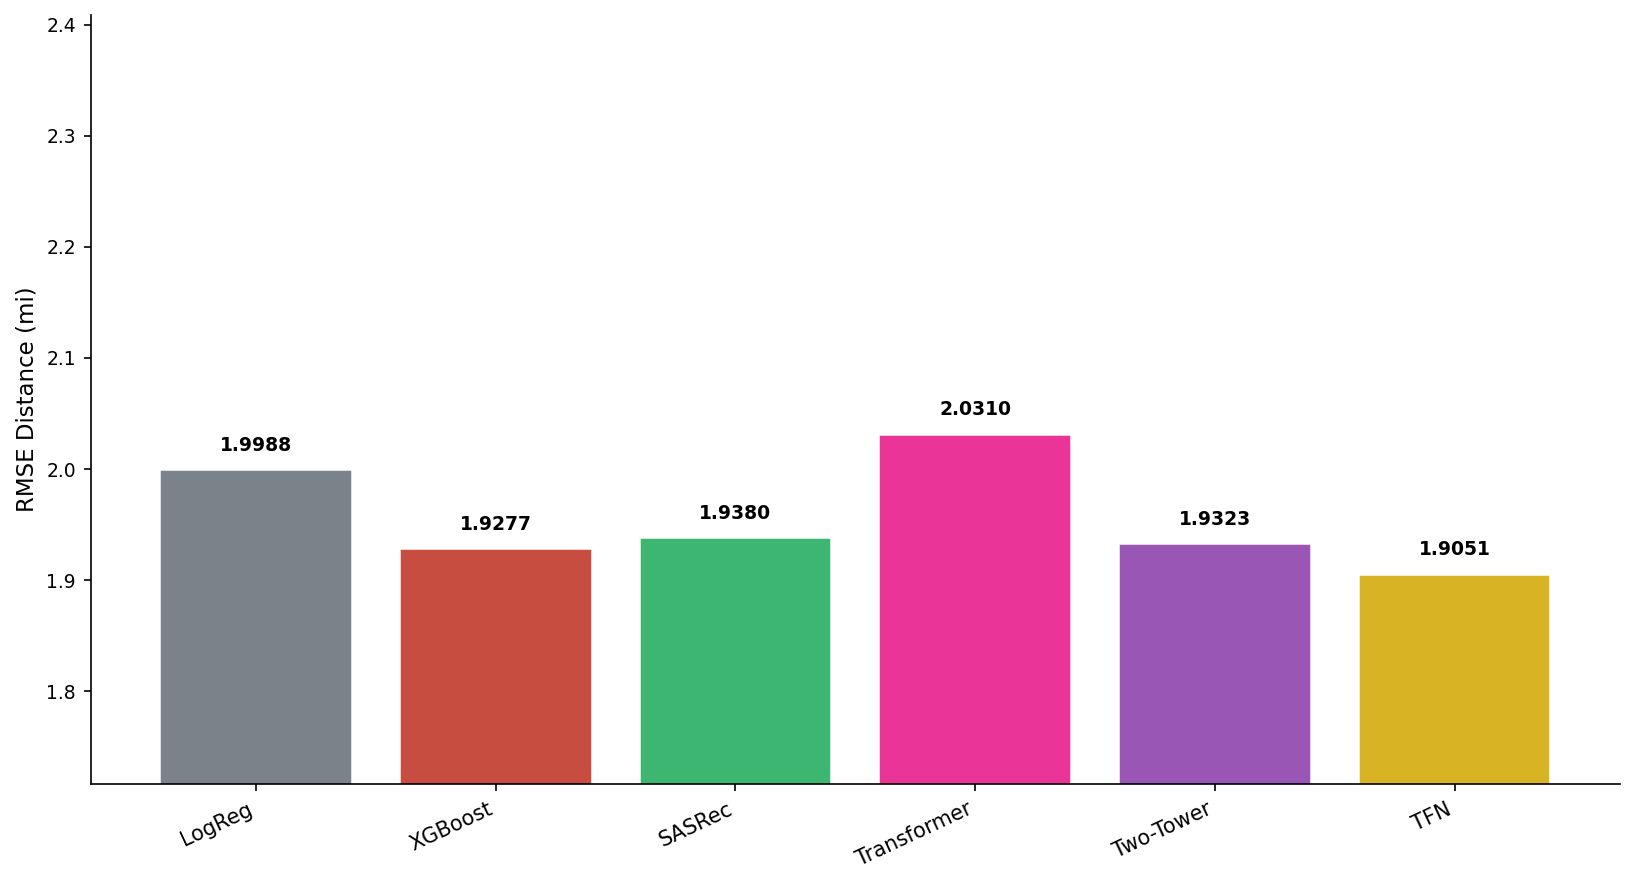

In [13]:
df_s1 = df[df['model'].isin(STUDY1_MODELS)]
labels = [MODEL_LABELS[m] for m in STUDY1_MODELS]
colors = [MODEL_COLORS[m] for m in STUDY1_MODELS]

def simple_bar_s1(col, ylabel, fname):
    if col not in df_s1.columns:
        print(f'[SKIP] {fname} — column "{col}" absent'); return
    fig, ax = plt.subplots(figsize=(11,6))
    means = [df_s1[df_s1['model']==m][col].mean() for m in STUDY1_MODELS]
    bars = ax.bar(labels, means, color=colors, edgecolor='white', lw=0.8, alpha=0.9)
    ax.set_xticklabels(labels, rotation=25, ha='right', fontsize=10)
    mn, mx = min(means), max(means); sp = max(mx-mn, 0.005)
    ax.set_ylim(max(0, mn-sp*1.5), mx+sp*3)
    ax.set_ylabel(ylabel, fontsize=11)
    rng = ax.get_ylim()[1]-ax.get_ylim()[0]
    for val, bar in zip(means, bars):
        ax.text(bar.get_x()+bar.get_width()/2, val+rng*0.02,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    plt.tight_layout(); save_fig(fname)

simple_bar_s1('progressive_overload_compliance_rate', 'Compliance Rate', 'fig09a_rq1_overload.png')
simple_bar_s1('adaptation_success_rate', 'Adaptation Success Rate', 'fig09b_rq1_adaptation.png')
simple_bar_s1('rmse_distance', 'RMSE Distance (mi)', 'fig09c_rq1_rmse_distance.png')

## 12. RQ2 — Periodization Compliance (Study 1)

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig10a_rq2_periodization.png


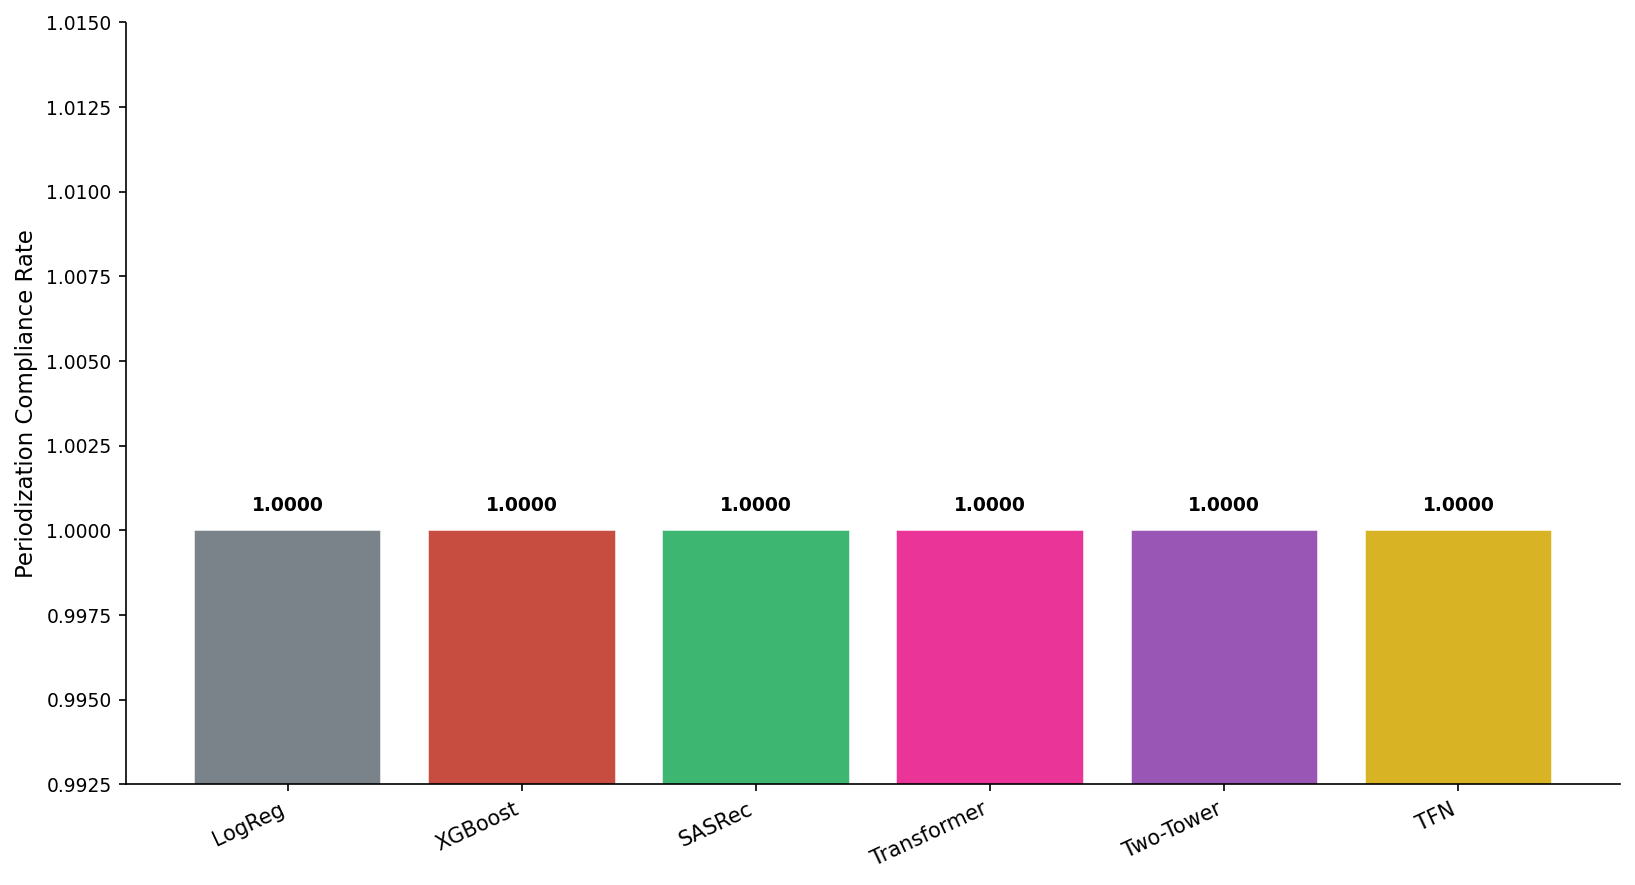

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig10b_rq2_compliance_by_phase.png


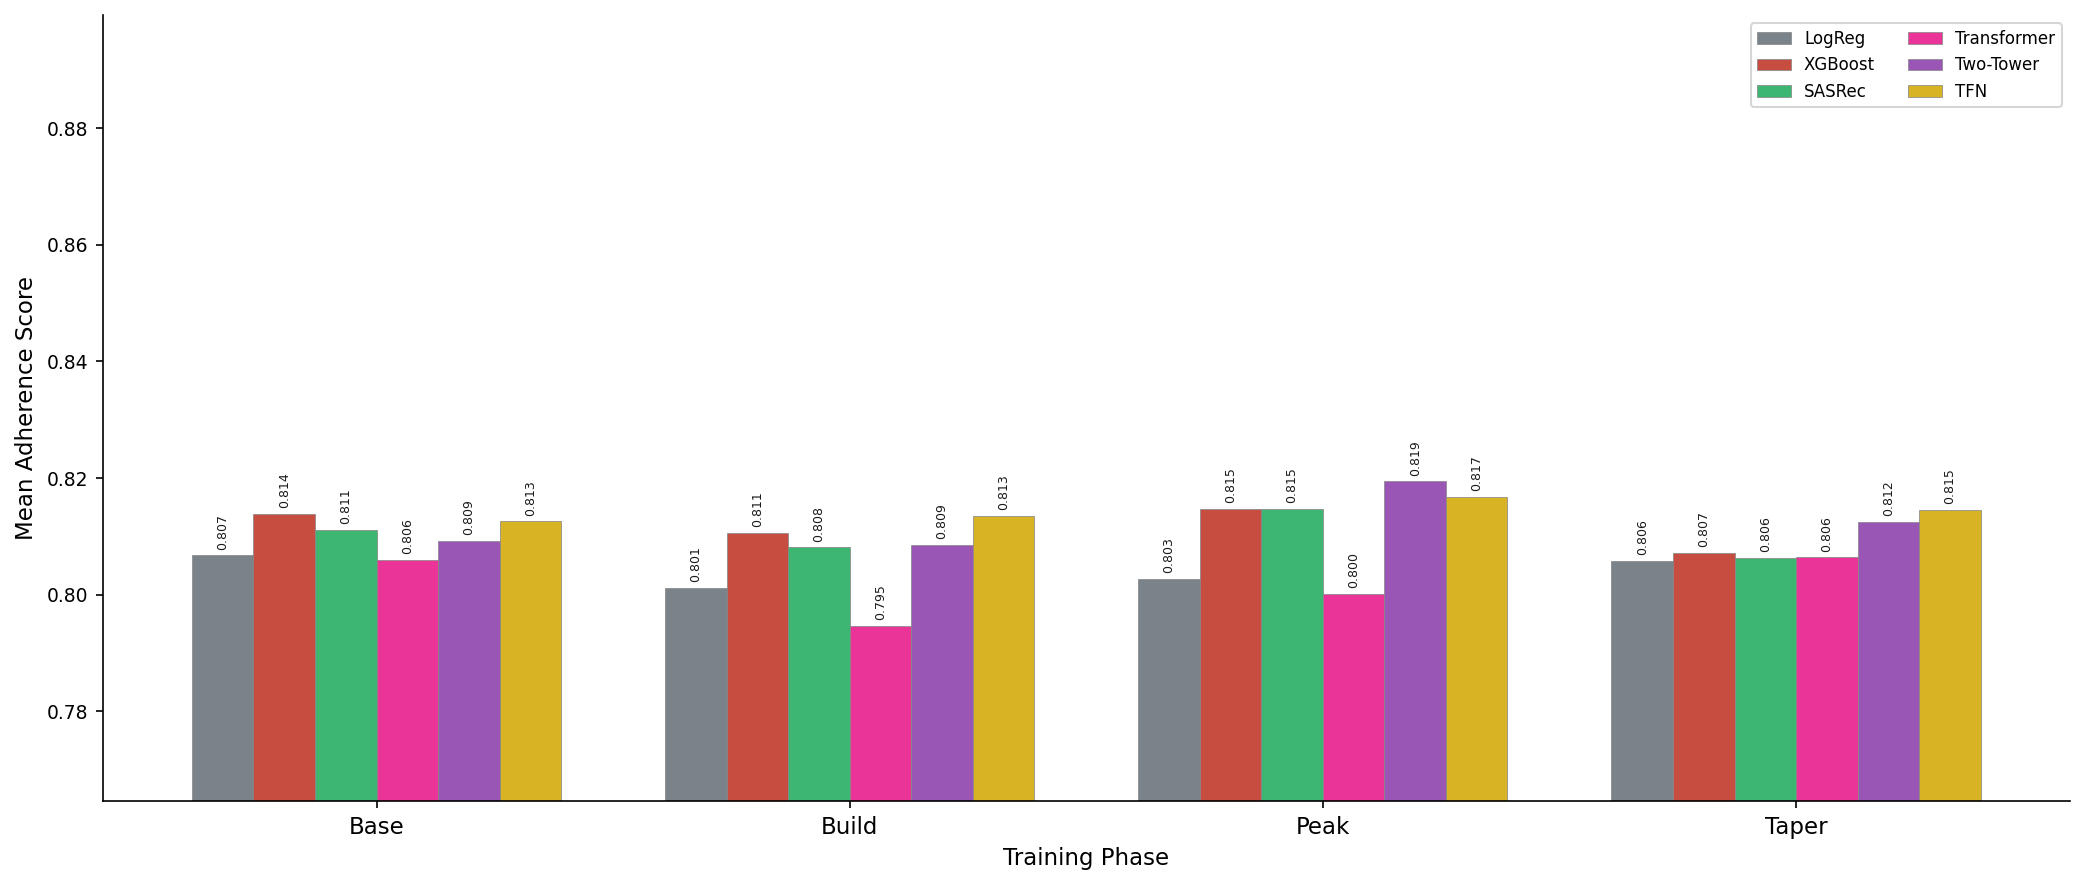

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig10c_rq2_rmse_rpe.png


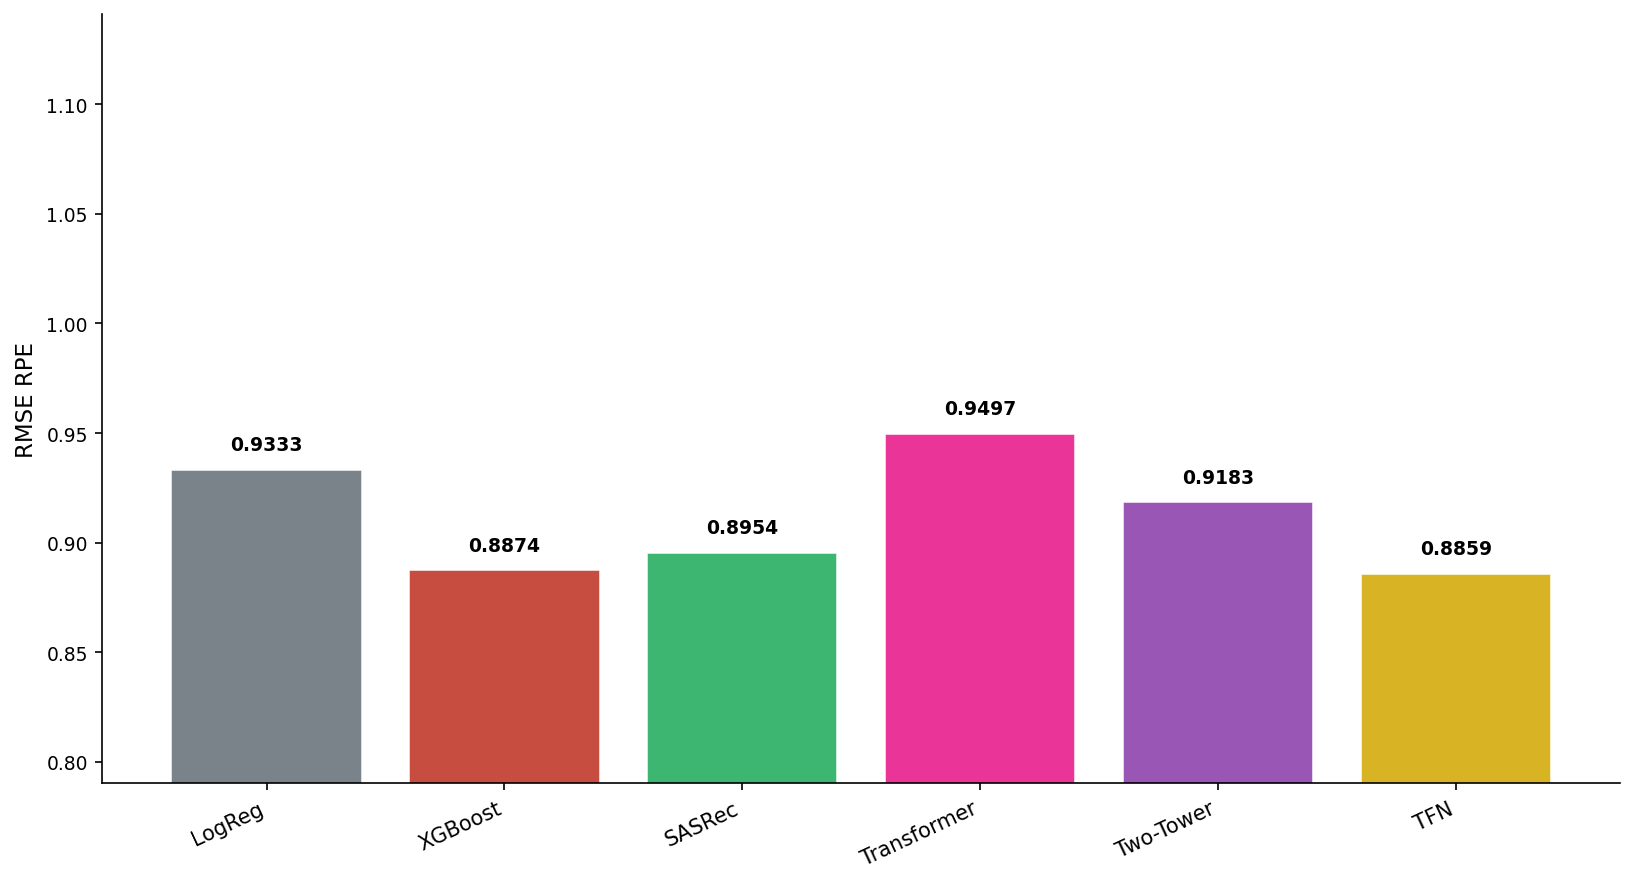

In [14]:
df_s1 = df[df['model'].isin(STUDY1_MODELS)]
labels = [MODEL_LABELS[m] for m in STUDY1_MODELS]
colors = [MODEL_COLORS[m] for m in STUDY1_MODELS]
phase_labels = [p.capitalize() for p in PHASE_ORDER]

def simple_bar_s1(col, ylabel, fname):
    if col not in df_s1.columns:
        print(f'[SKIP] {fname} — column "{col}" absent'); return
    fig, ax = plt.subplots(figsize=(11, 6))
    means = [df_s1[df_s1['model']==m][col].mean() for m in STUDY1_MODELS]
    bars = ax.bar(labels, means, color=colors, edgecolor='white', lw=0.8, alpha=0.9)
    ax.set_xticklabels(labels, rotation=25, ha='right', fontsize=10)
    mn, mx = min(means), max(means); sp = max(mx-mn, 0.005)
    ax.set_ylim(max(0, mn-sp*1.5), mx+sp*3)
    ax.set_ylabel(ylabel, fontsize=11)
    rng = ax.get_ylim()[1]-ax.get_ylim()[0]
    for val, bar in zip(means, bars):
        ax.text(bar.get_x()+bar.get_width()/2, val+rng*0.02,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    plt.tight_layout(); save_fig(fname)

simple_bar_s1('periodization_compliance_rate', 'Periodization Compliance Rate', 'fig10a_rq2_periodization.png')

# Fig 10b — Adherence score by training phase × model (Study 1)
# Periodization compliance is enforced uniformly by the constraint layer —
# deviation from 1.0 is zero or negligible for all models in all phases.
# Adherence score by phase reveals the real phase-level variation.
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(PHASE_ORDER)); width = 0.13
all_vals = []
for i, m in enumerate(STUDY1_MODELS):
    means = [df_s1[(df_s1['model']==m)&(df_s1['training_phase']==ph)]['avg_adherence_score'].mean()
             for ph in PHASE_ORDER]
    all_vals.extend(means)
    bars = ax.bar(x+i*width, means, width, label=MODEL_LABELS[m],
                  color=MODEL_COLORS[m], edgecolor='#888888', linewidth=0.4, alpha=0.9)
    for bar, val in zip(bars, means):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=6, rotation=90, color='#1a1a1a')
ax.set_xticks(x+width*2.5)
ax.set_xticklabels(phase_labels, fontsize=11)
ax.set_xlabel('Training Phase', fontsize=11)
ax.set_ylabel('Mean Adherence Score', fontsize=11)
ax.legend(fontsize=8, ncol=2)
mn, mx = min(all_vals), max(all_vals)
ax.set_ylim(max(0, mn-0.03), mx+0.08)
plt.tight_layout(); save_fig('fig10b_rq2_compliance_by_phase.png')

simple_bar_s1('rmse_rpe', 'RMSE RPE', 'fig10c_rq2_rmse_rpe.png')


## 13. RQ3 — 10% Rule Compliance (Study 1)

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig11a_rq3_ten_percent.png


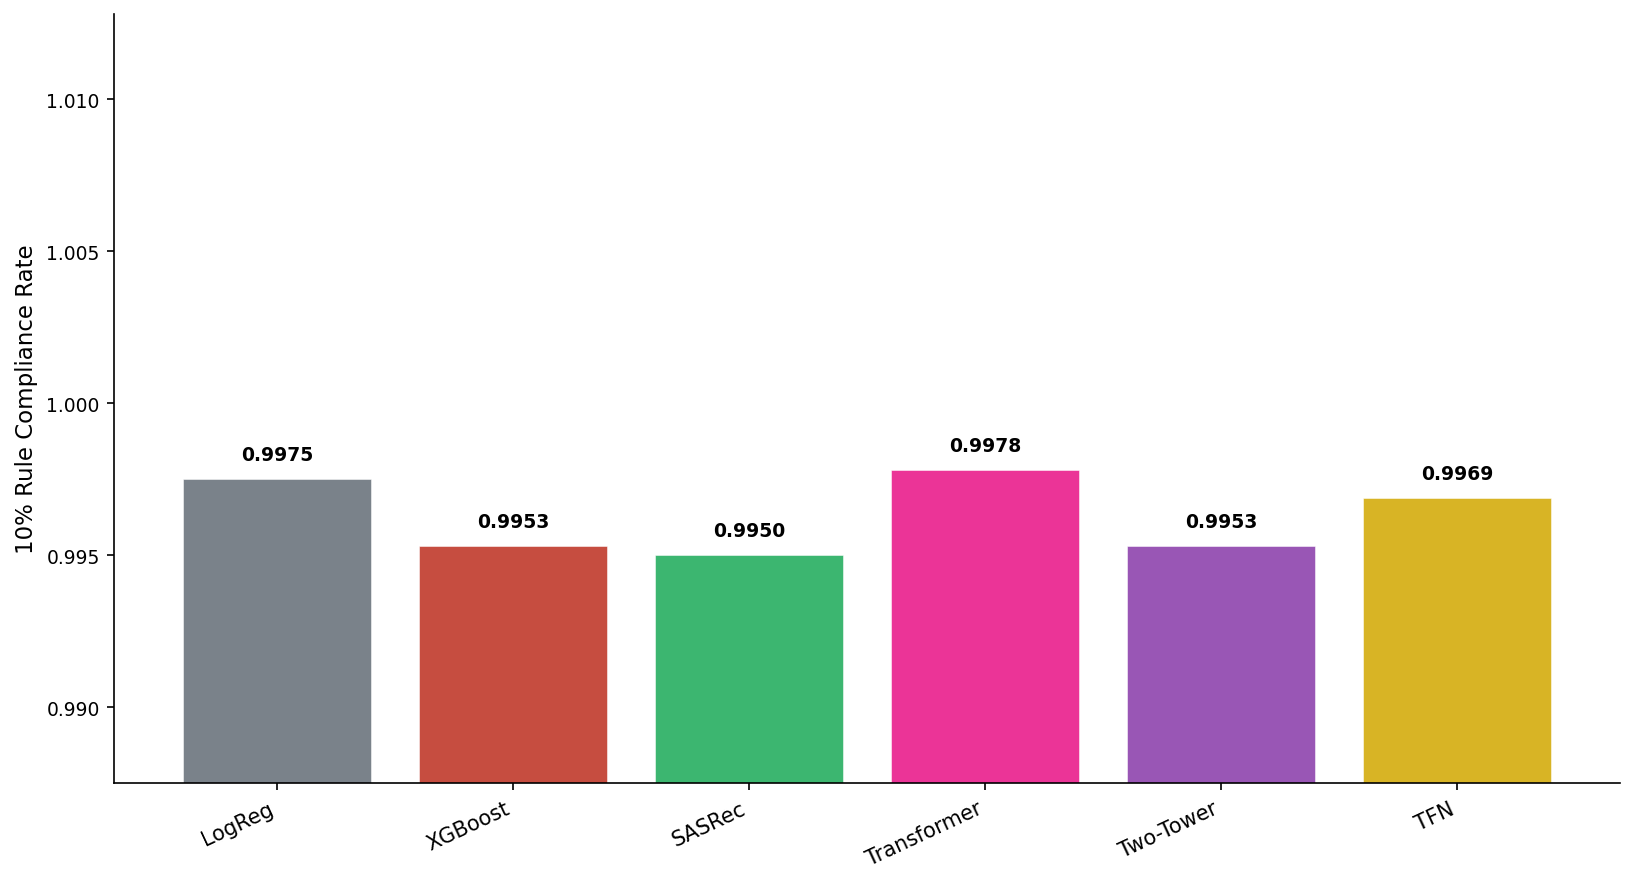

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig11b_rq3_violations_by_type.png


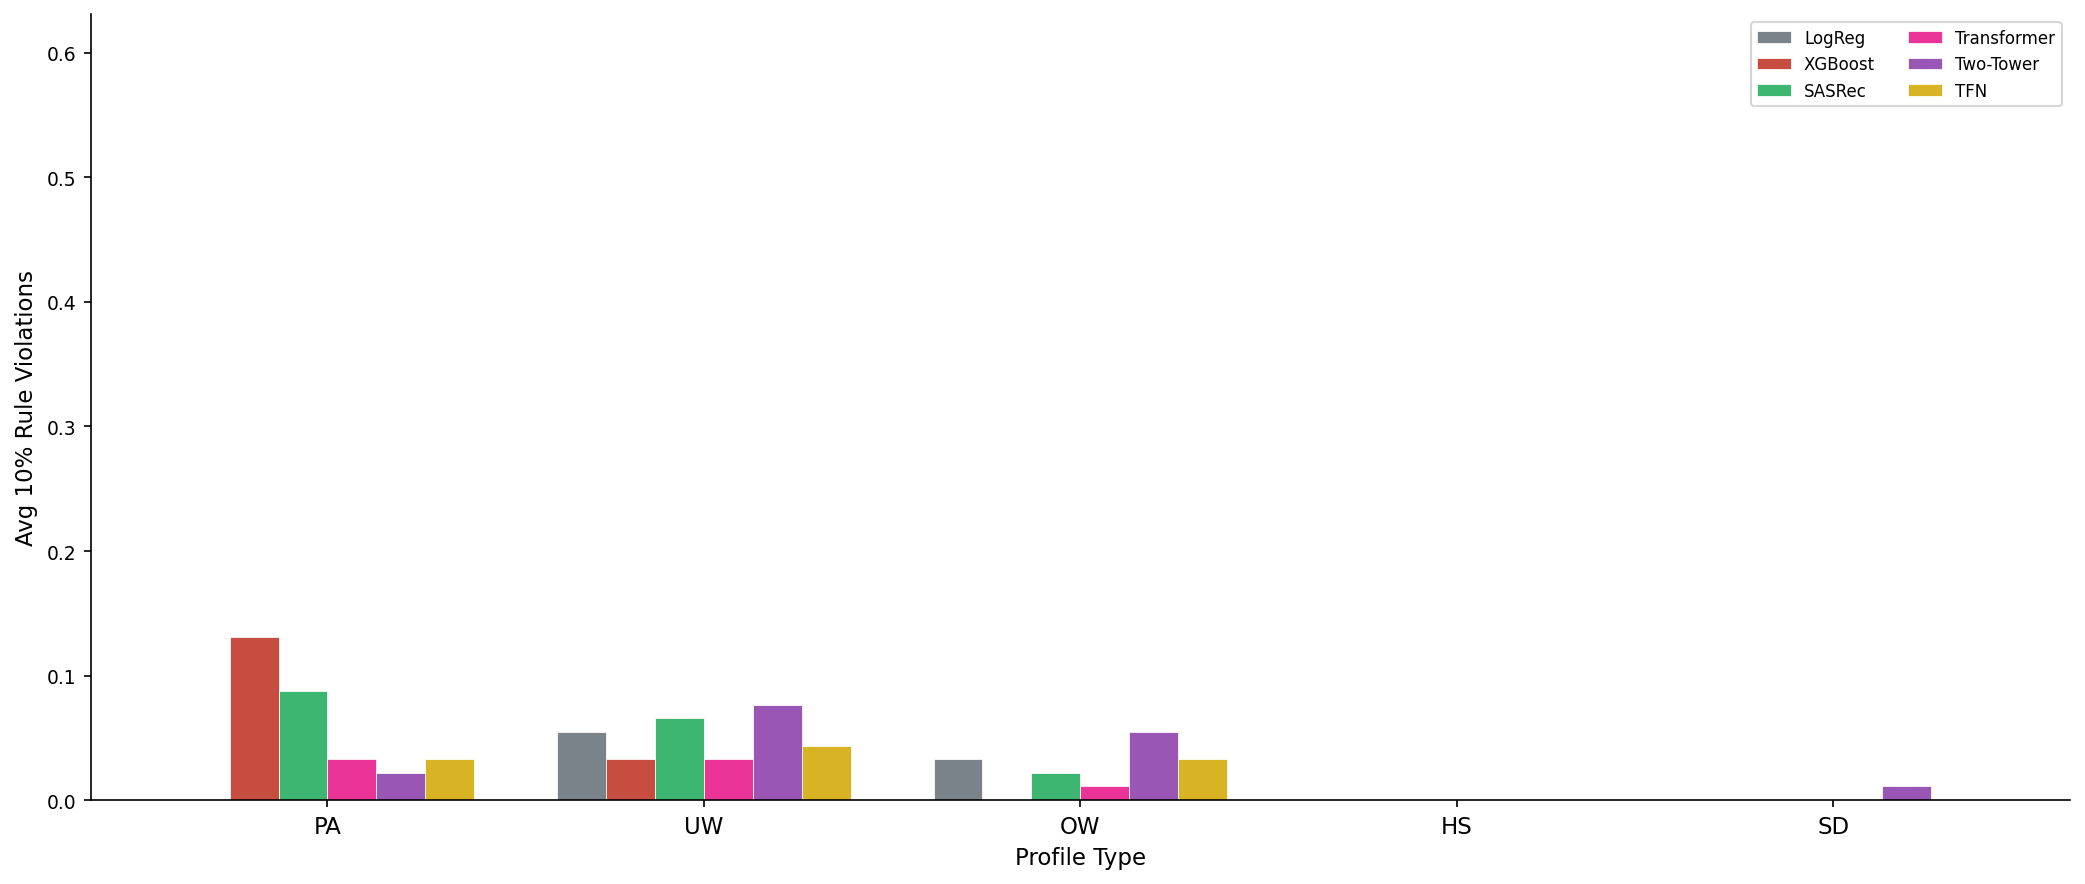

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig11c_rq3_rmse_volume.png


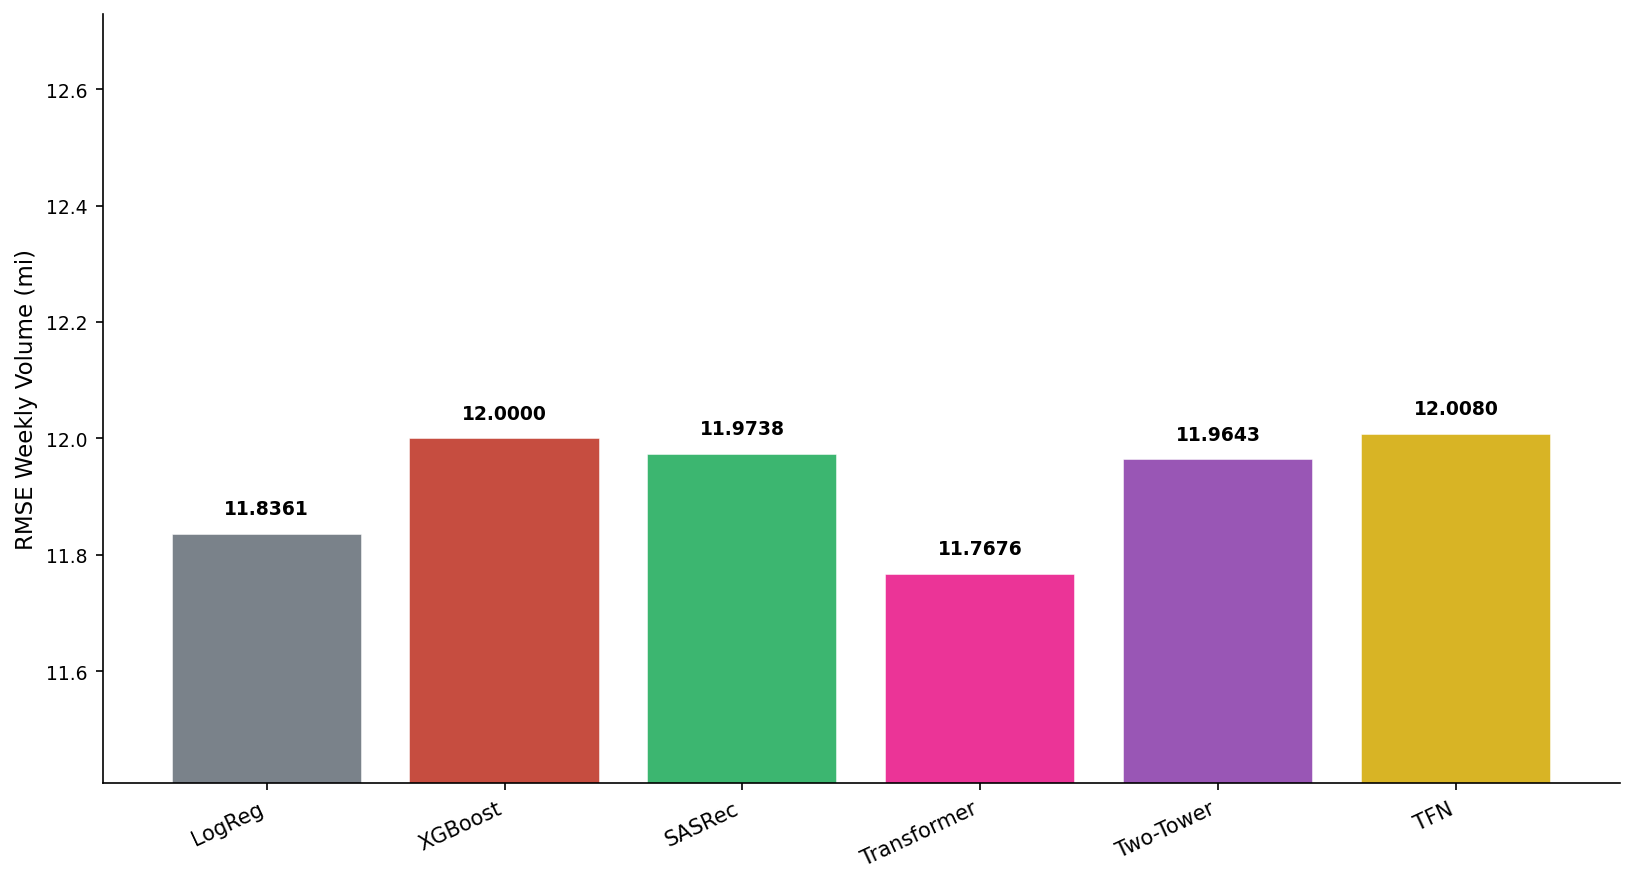

In [15]:
df_s1 = df[df['model'].isin(STUDY1_MODELS)]
labels = [MODEL_LABELS[m] for m in STUDY1_MODELS]
colors = [MODEL_COLORS[m] for m in STUDY1_MODELS]

def simple_bar_s1(col, ylabel, fname):
    if col not in df_s1.columns:
        print(f'[SKIP] {fname} — column "{col}" absent'); return
    fig, ax = plt.subplots(figsize=(11,6))
    means = [df_s1[df_s1['model']==m][col].mean() for m in STUDY1_MODELS]
    bars = ax.bar(labels, means, color=colors, edgecolor='white', lw=0.8, alpha=0.9)
    ax.set_xticklabels(labels, rotation=25, ha='right', fontsize=10)
    mn, mx = min(means), max(means); sp = max(mx-mn, 0.005)
    ax.set_ylim(max(0, mn-sp*1.5), mx+sp*3)
    ax.set_ylabel(ylabel, fontsize=11)
    rng = ax.get_ylim()[1]-ax.get_ylim()[0]
    for val, bar in zip(means, bars):
        ax.text(bar.get_x()+bar.get_width()/2, val+rng*0.02,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    plt.tight_layout(); save_fig(fname)

simple_bar_s1('ten_percent_compliance_rate', '10% Rule Compliance Rate', 'fig11a_rq3_ten_percent.png')

if 'ten_percent_violation_count' in df_s1.columns:
    fig, ax = plt.subplots(figsize=(14,6))
    x = np.arange(len(PROFILE_ORDER)); width = 0.13
    all_vals = []
    for i, m in enumerate(STUDY1_MODELS):
        means = [df_s1[(df_s1['model']==m)&(df_s1['profile_type']==pt)]['ten_percent_violation_count'].mean()
                 for pt in PROFILE_ORDER]
        all_vals.extend(means)
        bars = ax.bar(x+i*width, means, width, label=MODEL_LABELS[m],
                      color=MODEL_COLORS[m], edgecolor='white', linewidth=0.4, alpha=0.9)
    ax.set_xticks(x+width*2.5); ax.set_xticklabels(PROFILE_ORDER, fontsize=11)
    ax.set_xlabel('Profile Type', fontsize=11); ax.set_ylabel('Avg 10% Rule Violations', fontsize=11)
    ax.legend(fontsize=8, ncol=2)
    mn, mx = min(all_vals), max(all_vals)
    ax.set_ylim(max(0, mn-0.1), mx+0.5)
    plt.tight_layout(); save_fig('fig11b_rq3_violations_by_type.png')

simple_bar_s1('rmse_weekly_volume', 'RMSE Weekly Volume (mi)', 'fig11c_rq3_rmse_volume.png')

## 14. Disruption Event Analysis (Study 1)

Disruption event totals (Study 1):
  LogReg              injury=0  abstention=85  partial=11837
  XGBoost             injury=0  abstention=101  partial=10956
  SASRec              injury=0  abstention=90  partial=11112
  Transformer         injury=0  abstention=126  partial=11844
  Two-Tower           injury=0  abstention=91  partial=11292
  TFN                 injury=0  abstention=120  partial=10662
[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig12a_disruption_injury.png


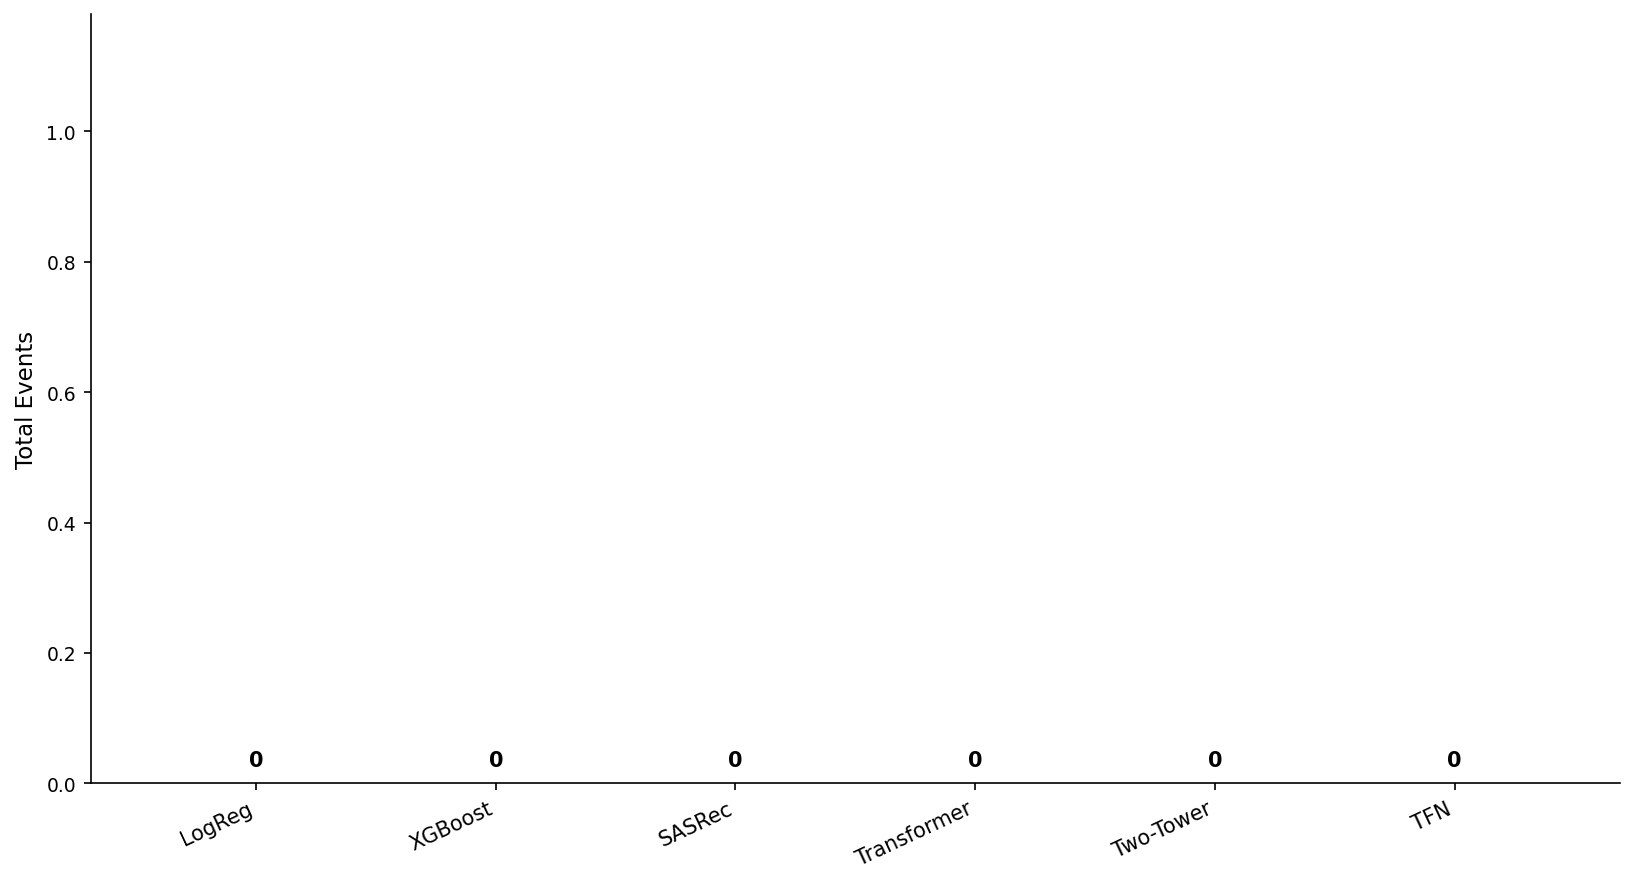

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig12b_disruption_abstention.png


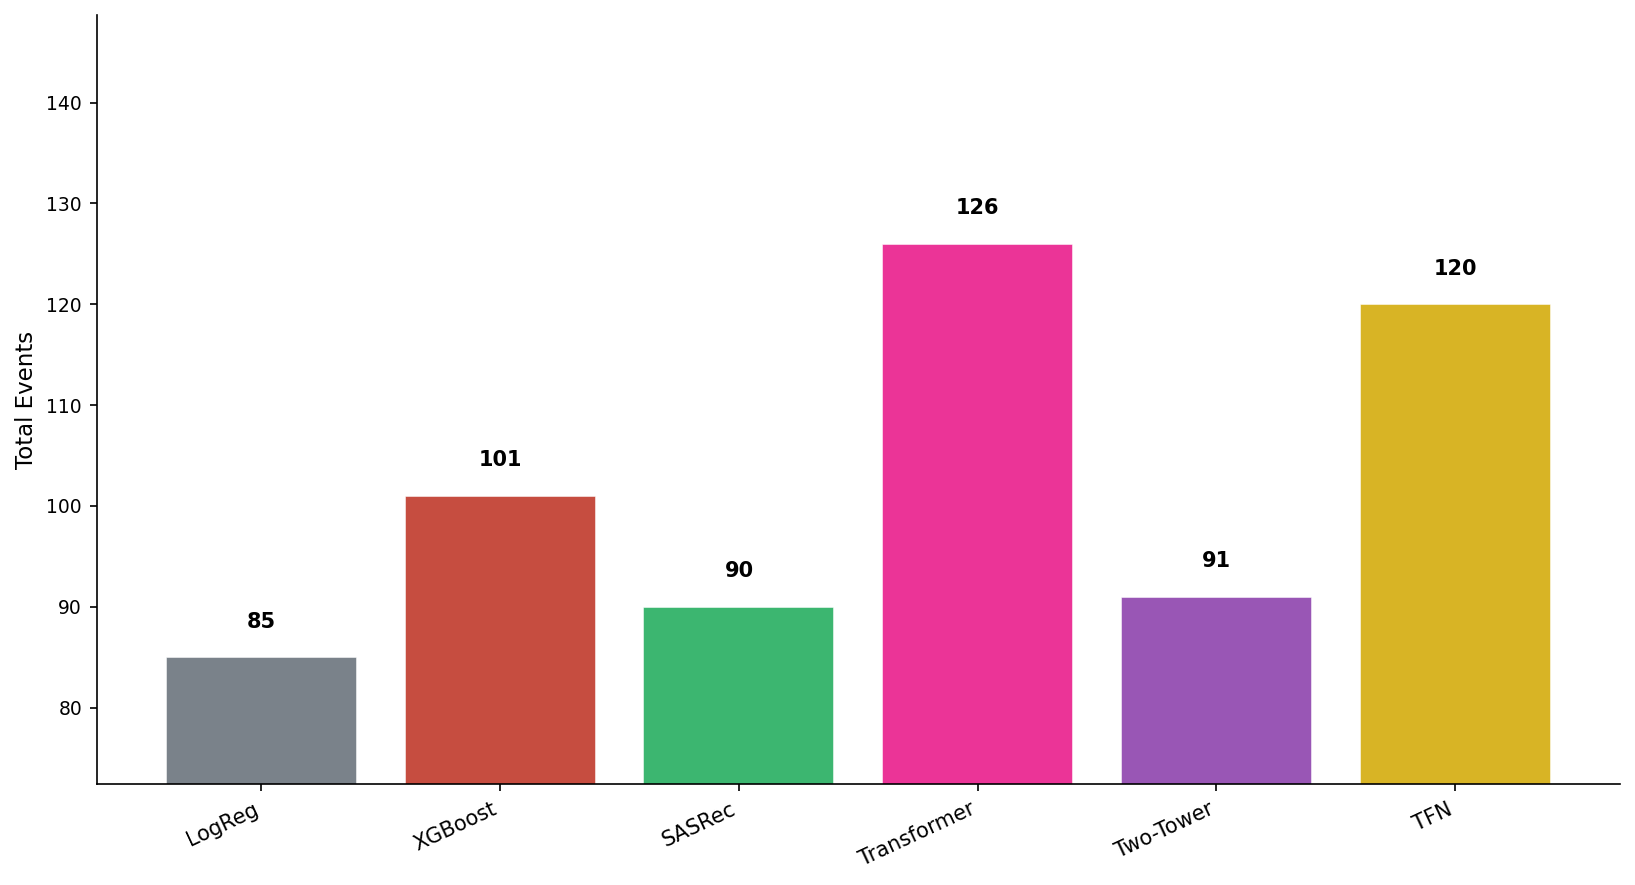

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig12c_disruption_partial.png


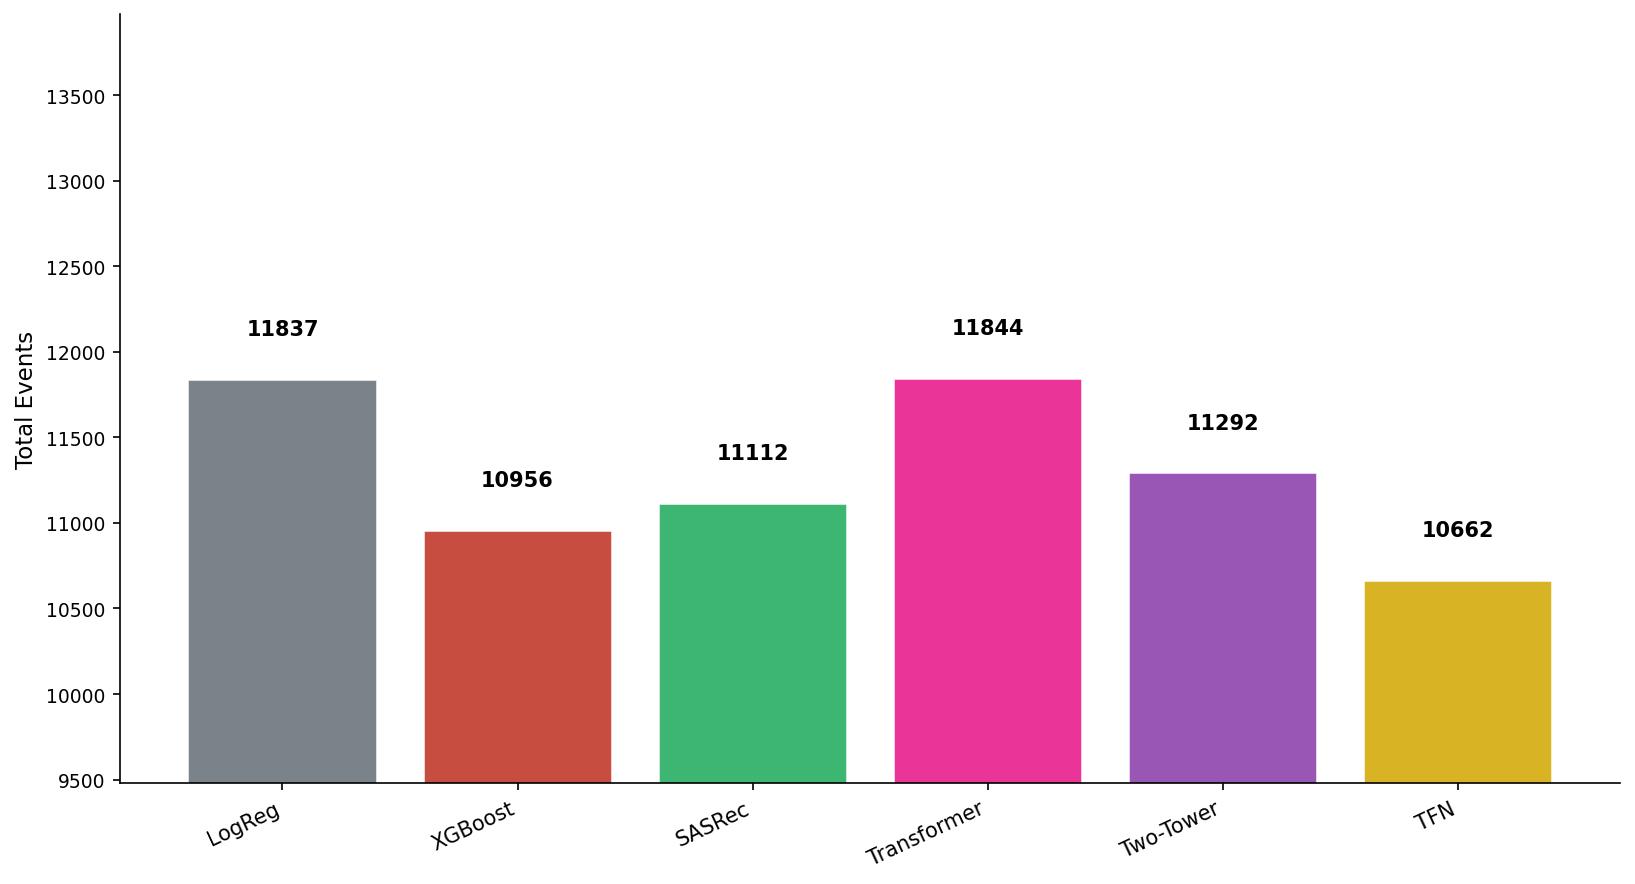

In [16]:
df_s1 = df[df['model'].isin(STUDY1_MODELS)]
labels = [MODEL_LABELS[m] for m in STUDY1_MODELS]
colors = [MODEL_COLORS[m] for m in STUDY1_MODELS]

def _sum(col, m): return int(df_s1[df_s1['model']==m][col].sum()) if col in df_s1.columns else 0
inj_counts  = [_sum('disruption_injury',     m) for m in STUDY1_MODELS]
abs_counts  = [_sum('disruption_abstention', m) for m in STUDY1_MODELS]
part_counts = [_sum('disruption_partial',    m) for m in STUDY1_MODELS]

print('Disruption event totals (Study 1):')
for m, inj, ab, pa in zip(STUDY1_MODELS, inj_counts, abs_counts, part_counts):
    print(f'  {MODEL_LABELS[m]:<18}  injury={inj}  abstention={ab}  partial={pa}')

for counts, fname in [
    (inj_counts,  'fig12a_disruption_injury.png'),
    (abs_counts,  'fig12b_disruption_abstention.png'),
    (part_counts, 'fig12c_disruption_partial.png'),
]:
    fig, ax = plt.subplots(figsize=(11,6))
    max_val = max(counts) if max(counts)>0 else 1
    bars = ax.bar(labels, counts, color=colors, edgecolor='white', linewidth=0.8, alpha=0.9)
    ax.set_ylabel('Total Events', fontsize=11)
    ax.set_xticklabels(labels, rotation=25, ha='right', fontsize=10)
    ax.set_ylim(max(0, min(counts)-max_val*0.1), max_val*1.18)
    for bar, val in zip(bars, counts):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max_val*0.02,
                str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
    plt.tight_layout(); save_fig(fname)

## 15. Summary Dashboard (Study 1)

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig13a_summary_overall.png


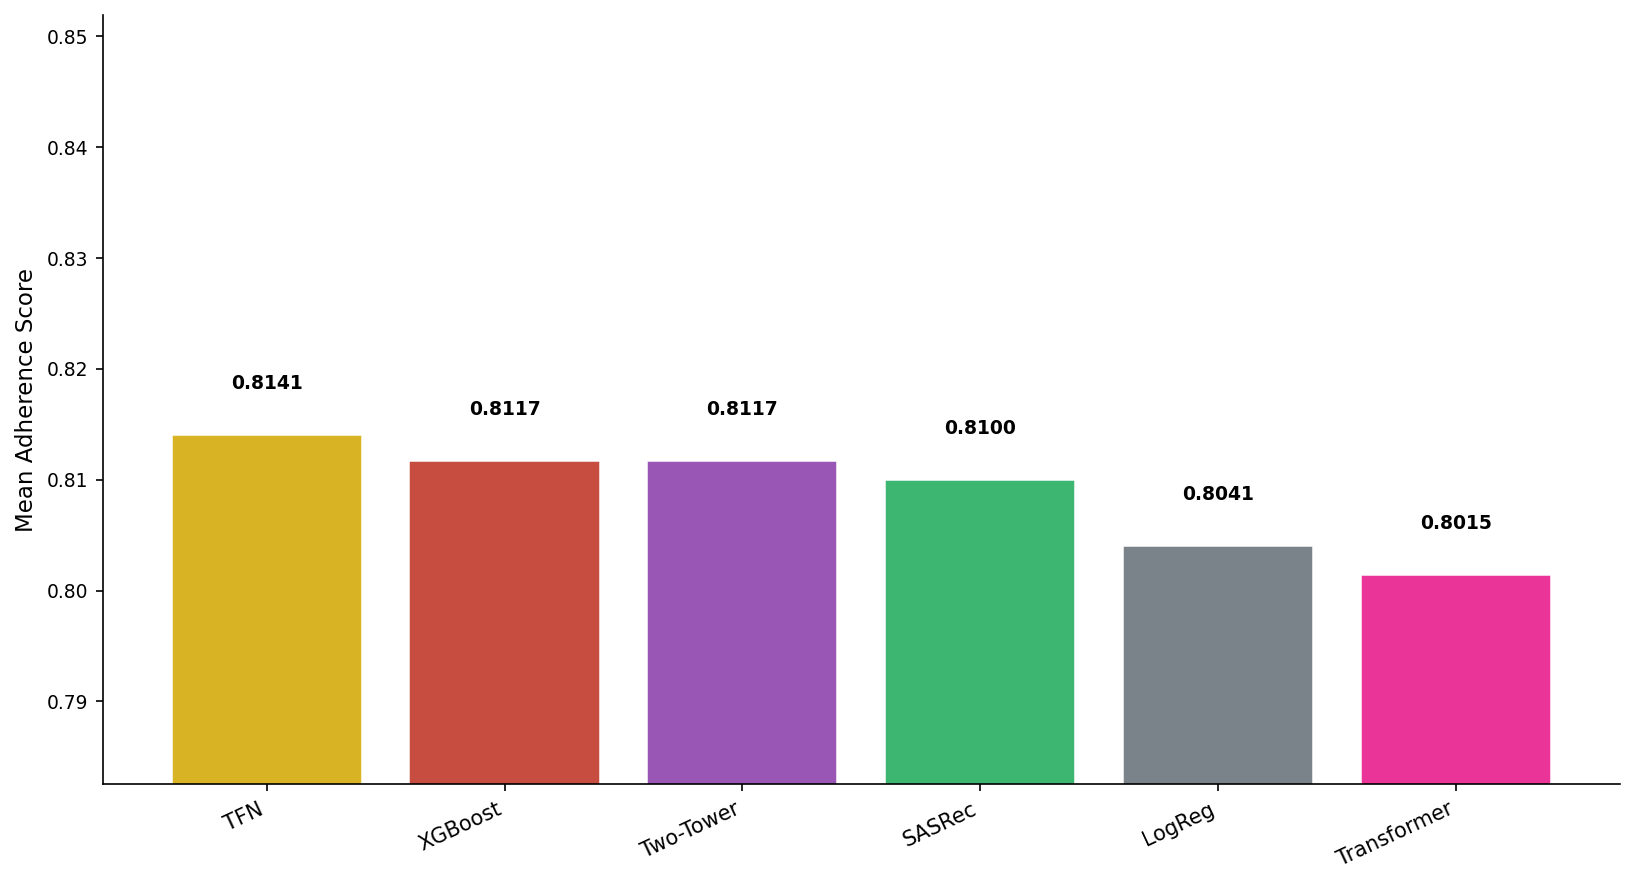

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig13b_summary_by_profile.png


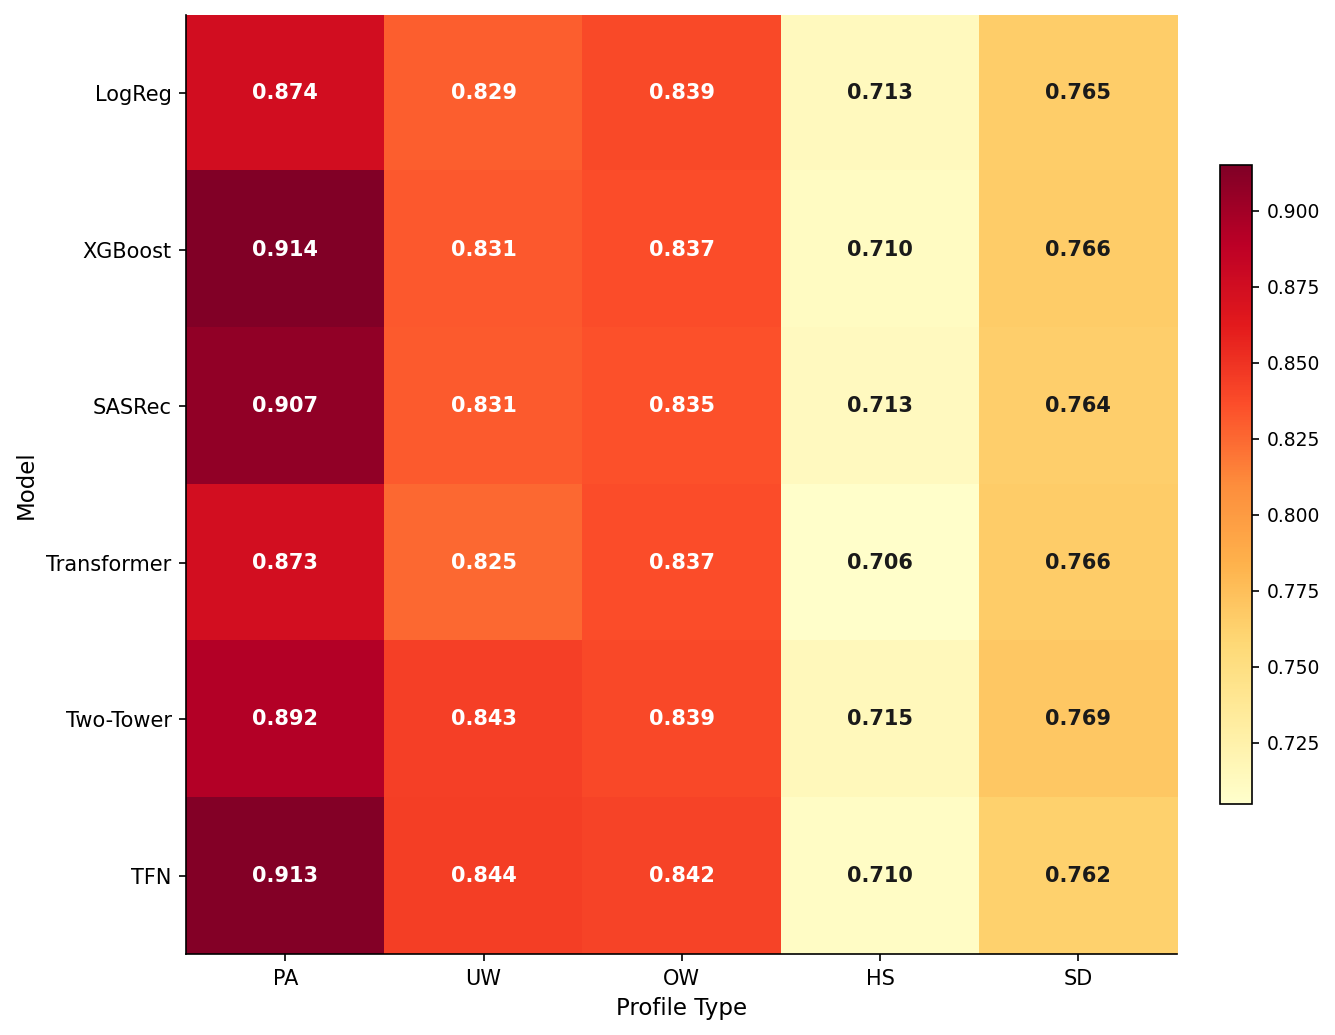

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig13c_summary_by_phase.png


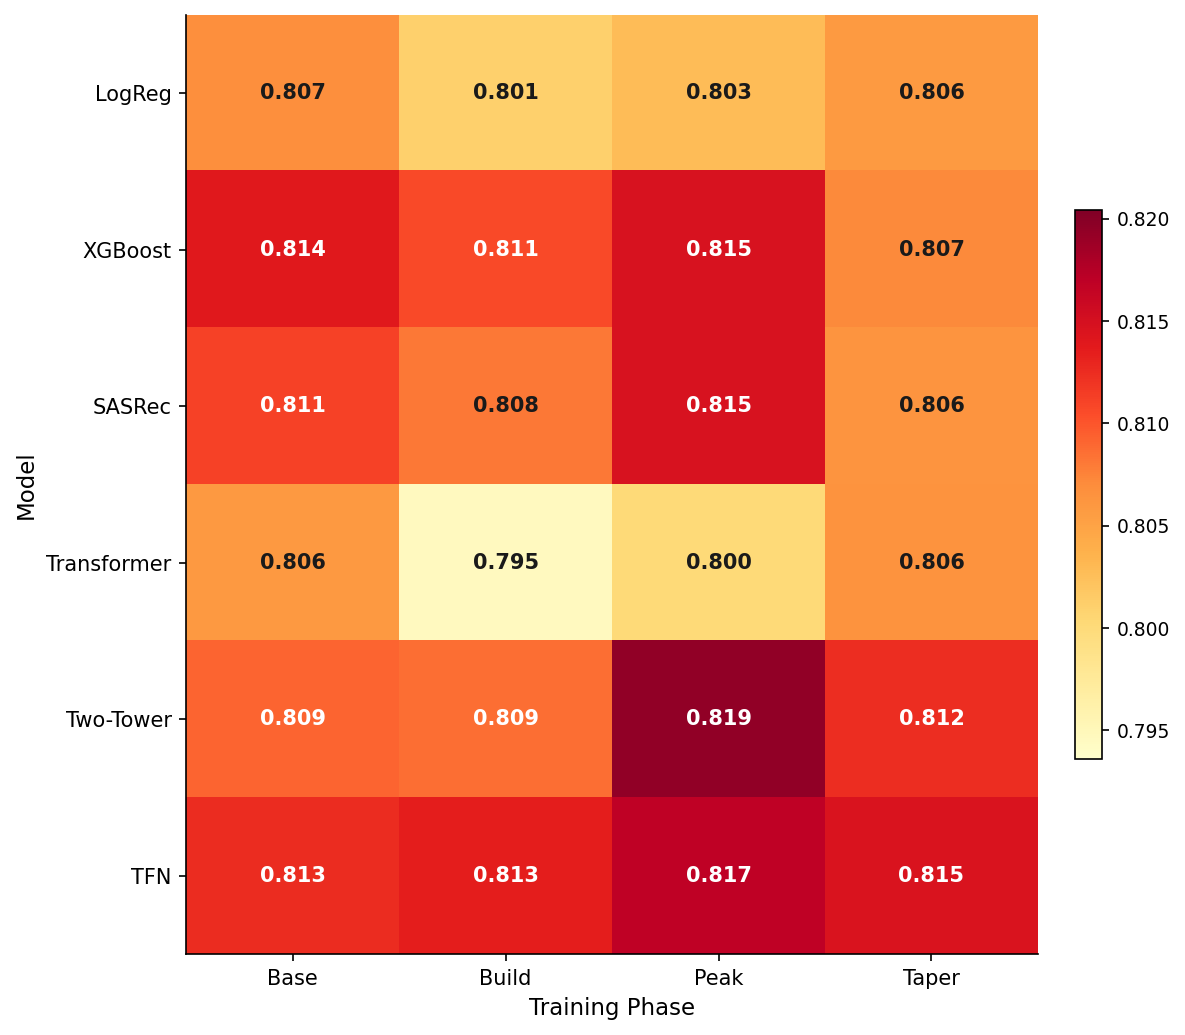

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig13d_summary_compliance.png


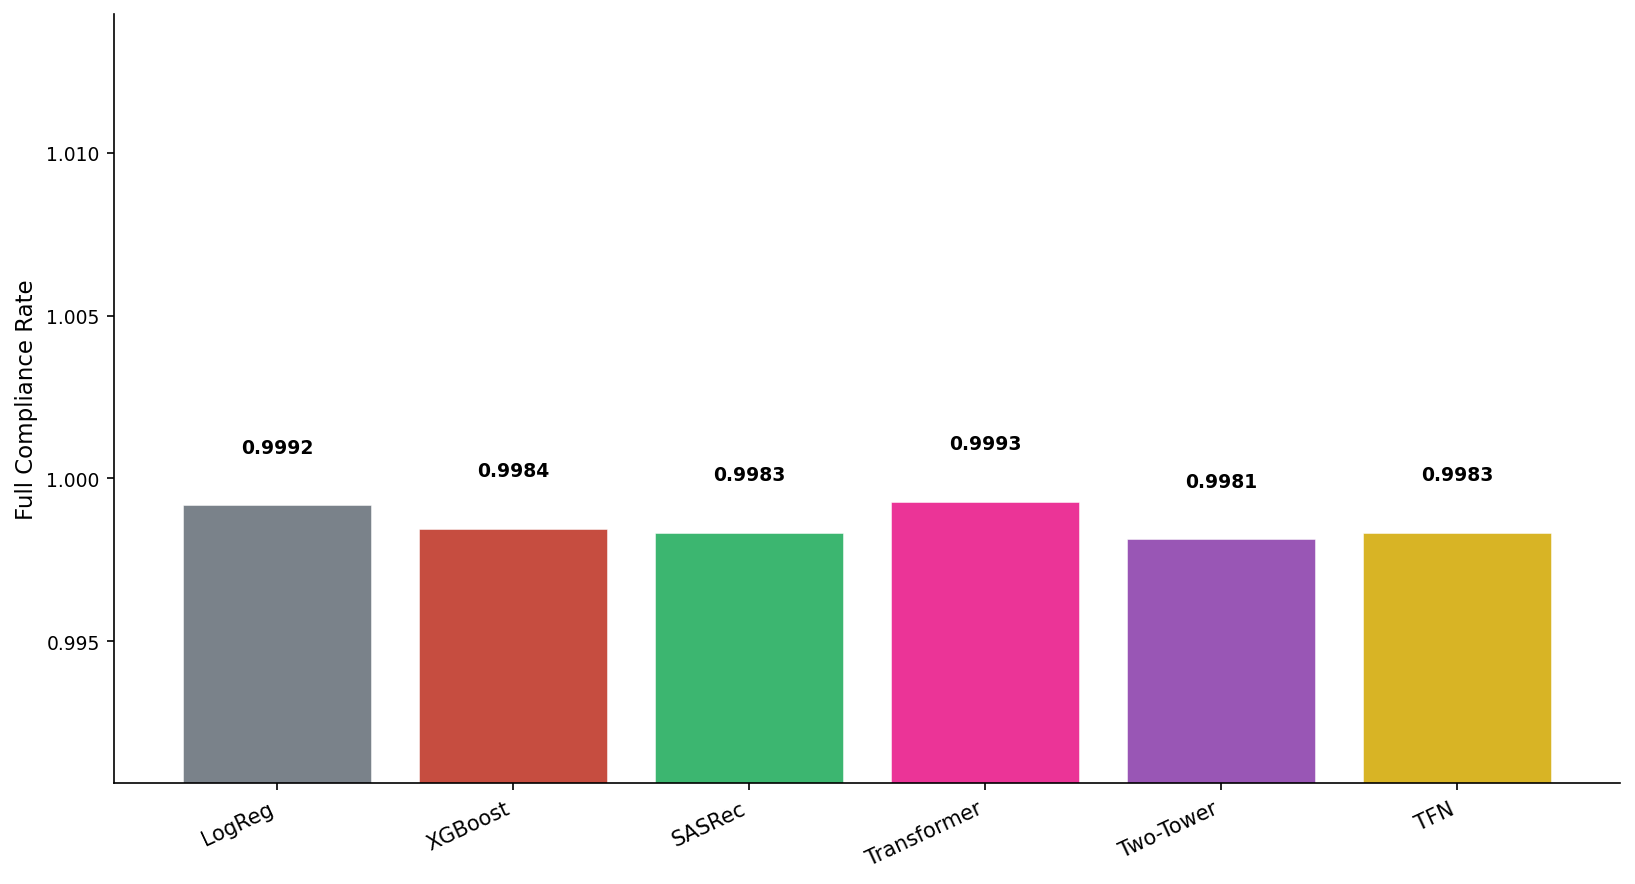

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig13e_summary_by_tier.png


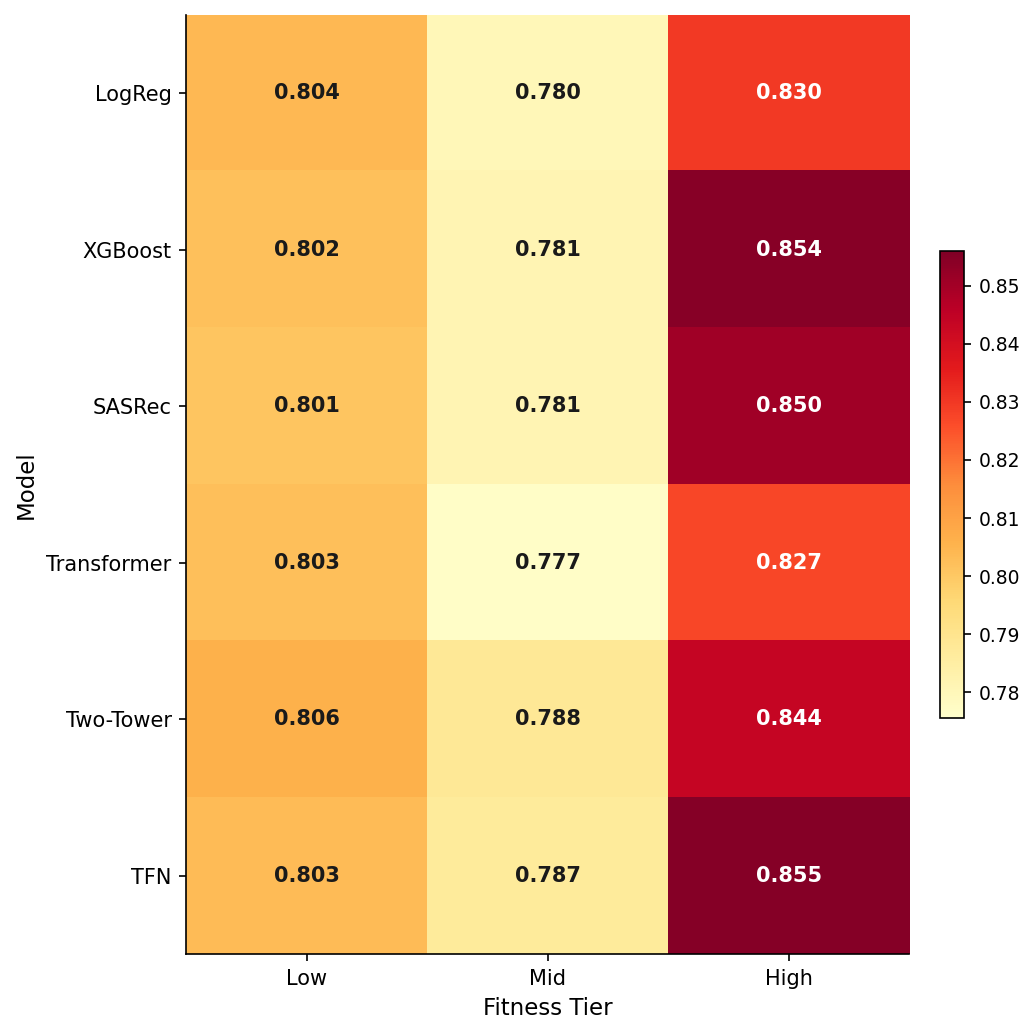

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig13f_summary_effect_size.png


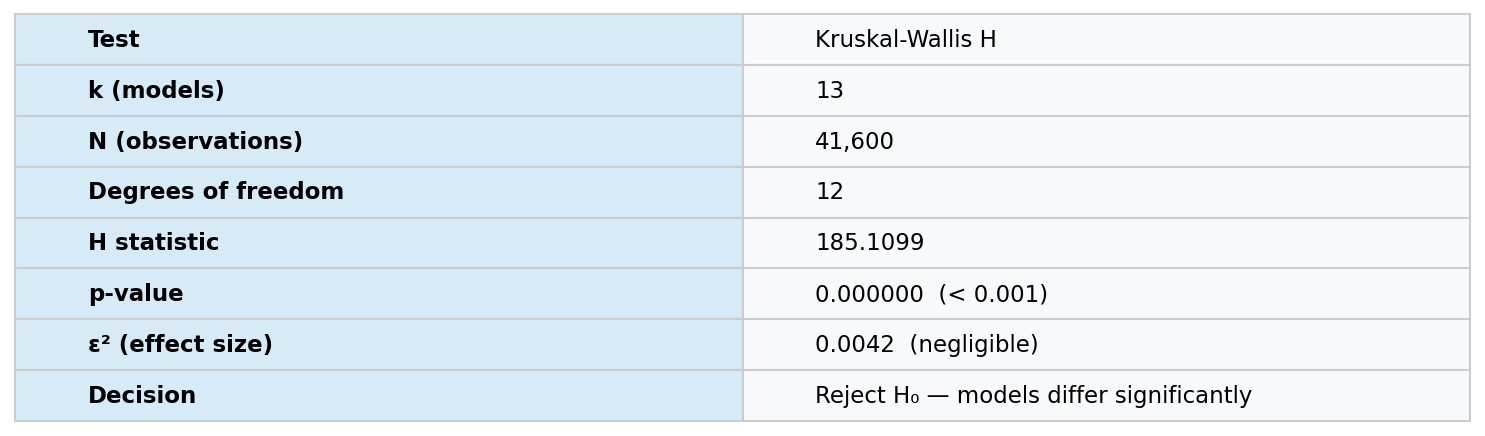

In [17]:
df_s1 = df[df['model'].isin(STUDY1_MODELS)]

def draw_heatmap(ax, data, row_labels, col_labels, xlabel, ylabel, fmt='{:.3f}'):
    vmin, vmax = data.min(), data.max()
    im = ax.imshow(data, cmap='YlOrRd', aspect='auto', vmin=vmin-0.001, vmax=vmax+0.001)
    ax.set_xticks(range(data.shape[1])); ax.set_xticklabels(col_labels, fontsize=10)
    ax.set_yticks(range(data.shape[0])); ax.set_yticklabels(row_labels, fontsize=10)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i,j]
            norm = (val-vmin)/max(vmax-vmin,1e-9)
            ax.text(j, i, fmt.format(val), ha='center', va='center', fontsize=10,
                    color='white' if norm>0.55 else '#1a1a1a', fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
    ax.set_xlabel(xlabel, fontsize=11); ax.set_ylabel(ylabel, fontsize=11)

# Fig 13a — ranked bar
s1_raw = sorted([(m, df_s1[df_s1['model']==m]['avg_adherence_score'].mean()) for m in STUDY1_MODELS],
                key=lambda x: x[1], reverse=True)
s1_sorted = [x[0] for x in s1_raw]; s1_vals = [x[1] for x in s1_raw]
fig, ax = plt.subplots(figsize=(11,6))
bars = ax.bar([MODEL_LABELS[m] for m in s1_sorted], s1_vals,
              color=[MODEL_COLORS[m] for m in s1_sorted], edgecolor='white', lw=0.8, alpha=0.9)
ax.set_xticklabels([MODEL_LABELS[m] for m in s1_sorted], rotation=25, ha='right', fontsize=10)
mn, mx = min(s1_vals), max(s1_vals); sp = max(mx-mn, 0.005)
ax.set_ylim(mn-sp*1.5, mx+sp*3); ax.set_ylabel('Mean Adherence Score', fontsize=11)
for val, bar in zip(s1_vals, bars):
    ax.text(bar.get_x()+bar.get_width()/2, val+sp*0.3,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout(); save_fig('fig13a_summary_overall.png')

# Fig 13b — model × profile type heatmap
data_b = np.array([[df_s1[(df_s1['model']==m)&(df_s1['profile_type']==pt)]['avg_adherence_score'].mean()
                    for pt in PROFILE_ORDER] for m in STUDY1_MODELS])
fig, ax = plt.subplots(figsize=(9,7))
draw_heatmap(ax, data_b, [MODEL_LABELS[m] for m in STUDY1_MODELS], PROFILE_ORDER, 'Profile Type','Model')
plt.tight_layout(); save_fig('fig13b_summary_by_profile.png')

# Fig 13c — model × phase heatmap
data_c = np.array([[df_s1[(df_s1['model']==m)&(df_s1['training_phase']==ph)]['avg_adherence_score'].mean()
                    for ph in PHASE_ORDER] for m in STUDY1_MODELS])
fig, ax = plt.subplots(figsize=(8,7))
draw_heatmap(ax, data_c, [MODEL_LABELS[m] for m in STUDY1_MODELS],
             [p.capitalize() for p in PHASE_ORDER], 'Training Phase','Model')
plt.tight_layout(); save_fig('fig13c_summary_by_phase.png')

# Fig 13d — compliance rate bar
fig, ax = plt.subplots(figsize=(11,6))
comp_means = [df_s1[df_s1['model']==m]['full_compliance_rate'].mean() for m in STUDY1_MODELS]
bars = ax.bar([MODEL_LABELS[m] for m in STUDY1_MODELS], comp_means,
              color=[MODEL_COLORS[m] for m in STUDY1_MODELS], edgecolor='white', lw=0.8, alpha=0.9)
ax.set_xticklabels([MODEL_LABELS[m] for m in STUDY1_MODELS], rotation=25, ha='right', fontsize=10)
mn, mx = min(comp_means), max(comp_means); sp = max(mx-mn, 0.005)
ax.set_ylim(max(0, mn-sp*1.5), mx+sp*3); ax.set_ylabel('Full Compliance Rate', fontsize=11)
for val, bar in zip(comp_means, bars):
    ax.text(bar.get_x()+bar.get_width()/2, val+sp*0.3,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout(); save_fig('fig13d_summary_compliance.png')

# Fig 13e — model × fitness tier heatmap
data_e = np.array([[df_s1[(df_s1['model']==m)&(df_s1['fitness_tier']==t)]['avg_adherence_score'].mean()
                    for t in TIER_ORDER] for m in STUDY1_MODELS])
fig, ax = plt.subplots(figsize=(7,7))
draw_heatmap(ax, data_e, [MODEL_LABELS[m] for m in STUDY1_MODELS],
             [t.capitalize() for t in TIER_ORDER], 'Fitness Tier','Model')
plt.tight_layout(); save_fig('fig13e_summary_by_tier.png')

# Fig 13f — KW result table
row = df_stats.iloc[0]
fig, ax = plt.subplots(figsize=(10,3)); ax.axis('off')
tbl = ax.table(cellText=[
    ['Test','Kruskal-Wallis H'],
    ['k (models)',str(int(row['n_models']))],
    ['N (observations)',f"{int(row['N_total']):,}"],
    ['Degrees of freedom',str(int(row['df']))],
    ['H statistic',f"{row['H']:.4f}"],
    ['p-value',f"{row['p_value']:.6f}  (< 0.001)"],
    ['\u03b5\u00b2 (effect size)',f"{row['epsilon_squared']:.4f}  (negligible)"],
    ['Decision','Reject H\u2080 \u2014 models differ significantly'],
], loc='center', cellLoc='left')
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1,1.8)
for (r,c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#CCCCCC')
    cell.set_facecolor('#D6EAF8' if c==0 else '#F8F9FA')
    if c==0: cell.set_text_props(fontweight='bold')
plt.tight_layout(); save_fig('fig13f_summary_effect_size.png')

## 16. RQ4 — Fitness Tier Deep Dive (Study 1)

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig14a_rq4_tier_bar.png


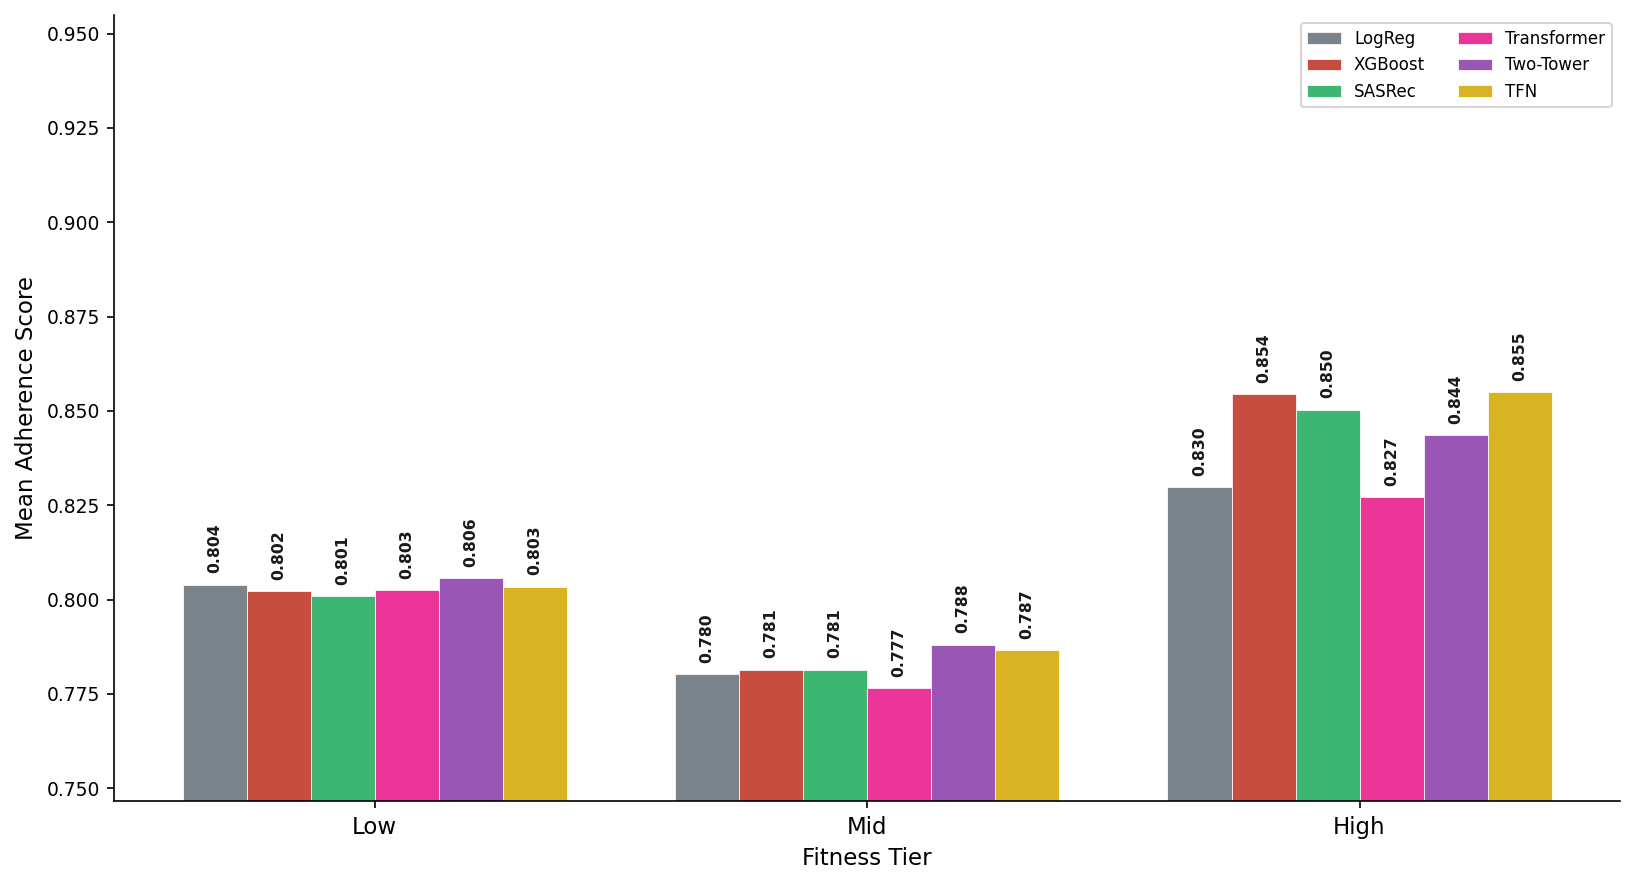

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig14b_rq4_tier_trajectory.png


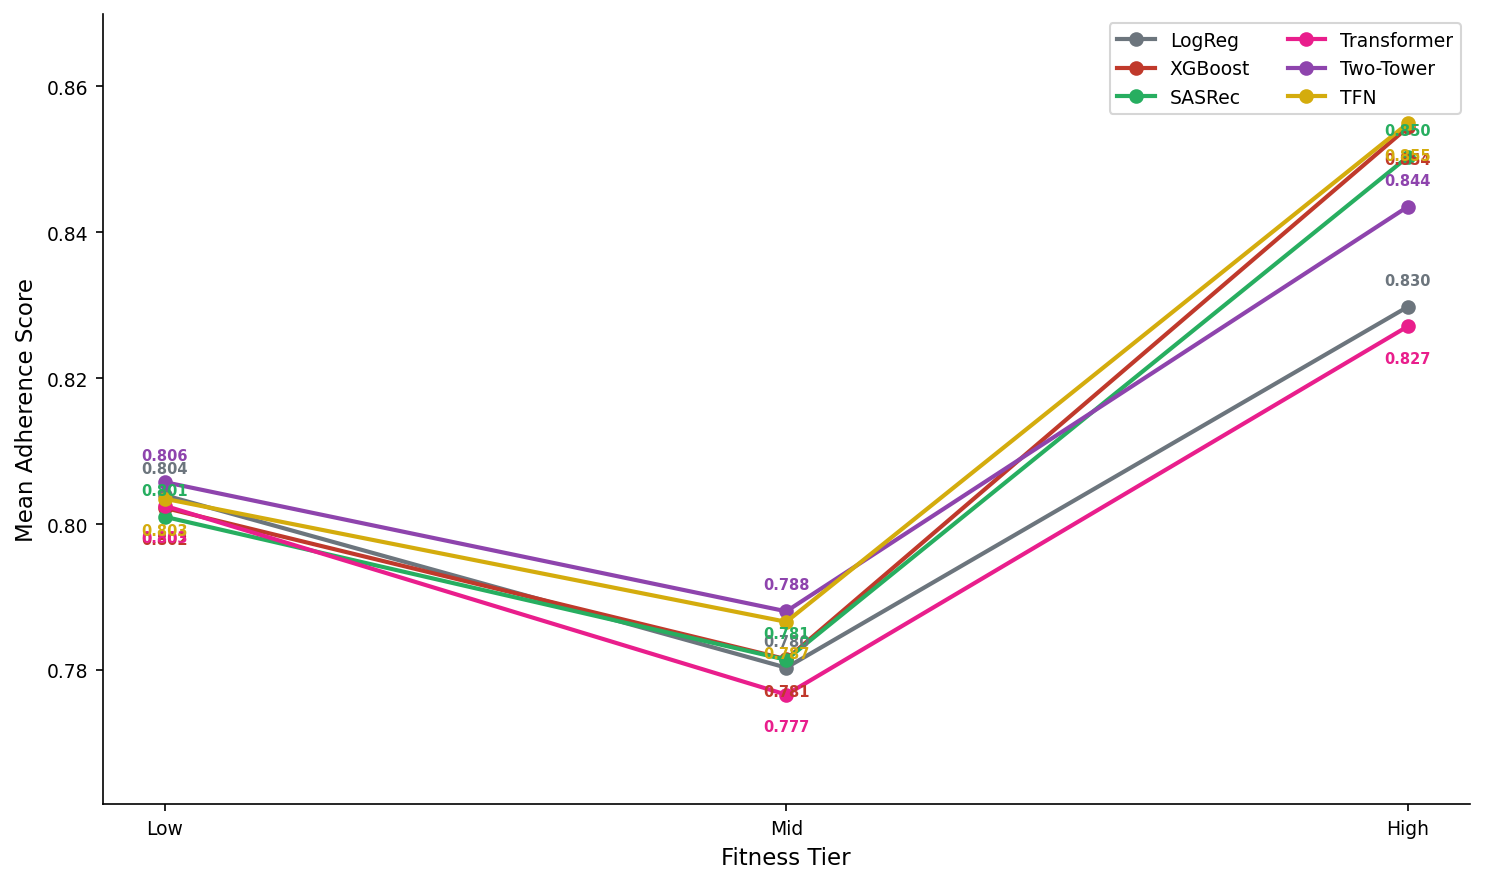

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig14c_rq4_pairwise.png


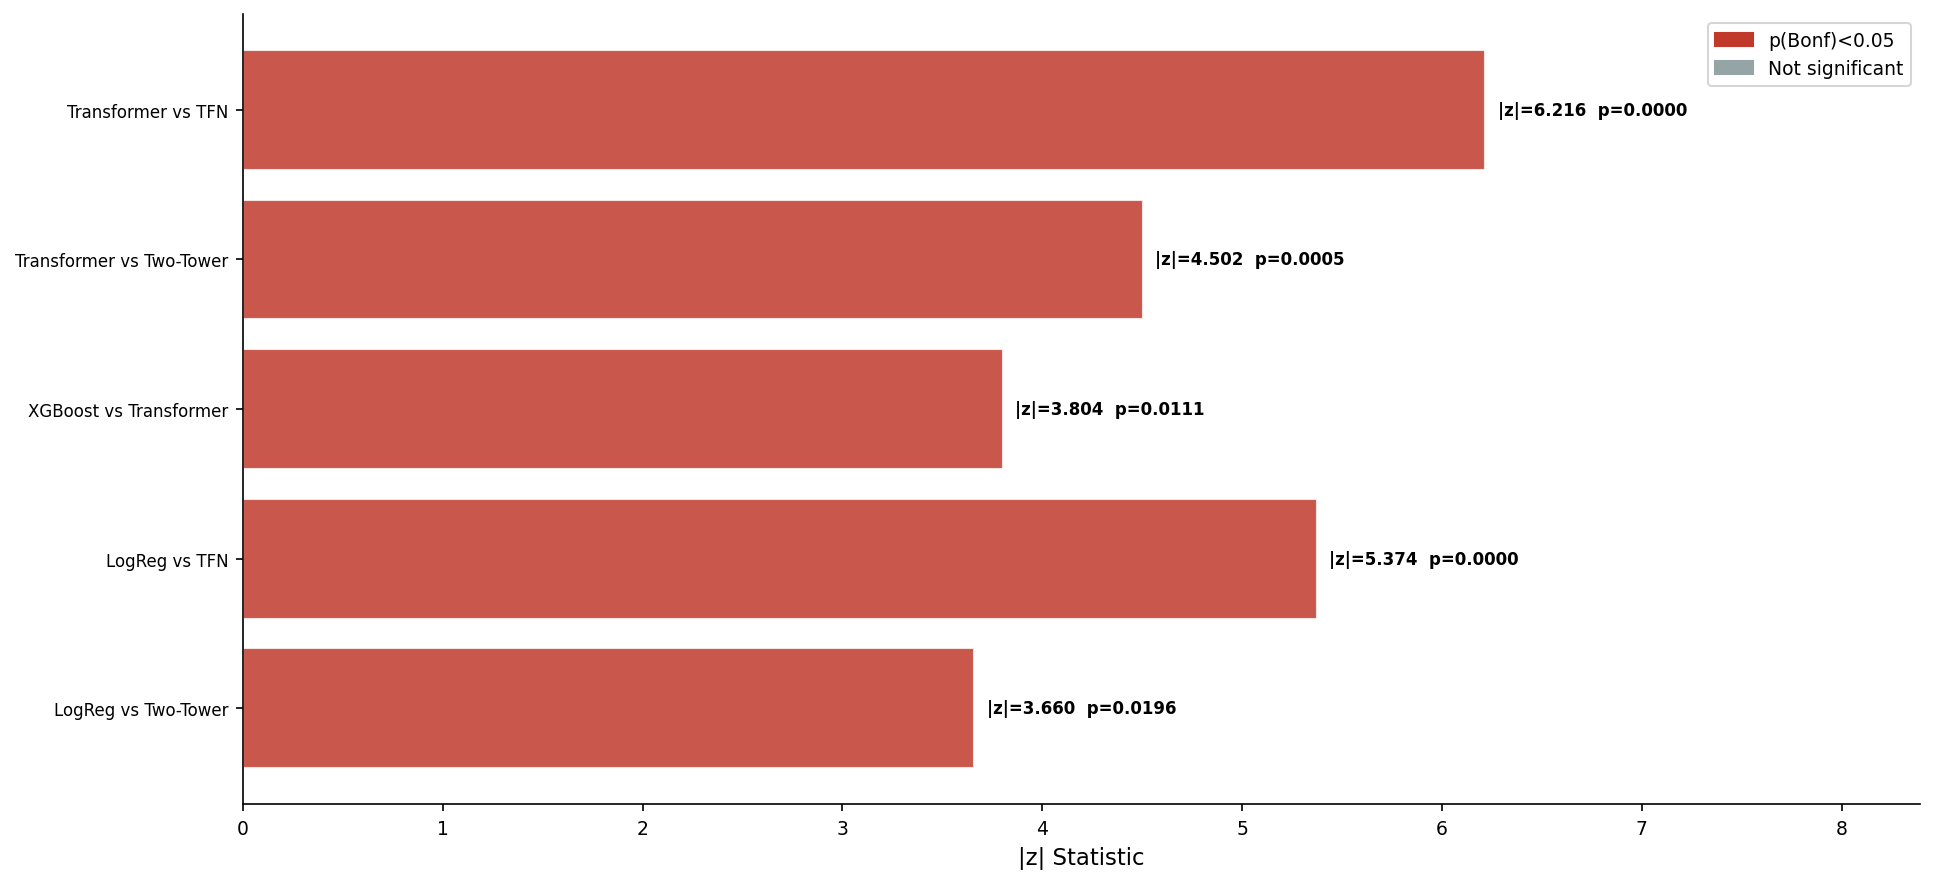

In [18]:
df_s1 = df[df['model'].isin(STUDY1_MODELS)]
tier_labels = [t.capitalize() for t in TIER_ORDER]

# Fig 14a — grouped bar by tier
fig, ax = plt.subplots(figsize=(11,6))
x = np.arange(len(TIER_ORDER)); width = 0.13
all_vals = []
for i, m in enumerate(STUDY1_MODELS):
    means = [df_s1[(df_s1['model']==m)&(df_s1['fitness_tier']==t)]['avg_adherence_score'].mean()
             for t in TIER_ORDER]
    all_vals.extend(means)
    bars = ax.bar(x+i*width, means, width, label=MODEL_LABELS[m],
                  color=MODEL_COLORS[m], edgecolor='white', linewidth=0.4, alpha=0.9)
    for bar, val in zip(bars, means):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, rotation=90,
                color='#1a1a1a', fontweight='bold')
ax.set_xticks(x+width*2.5); ax.set_xticklabels(tier_labels, fontsize=11)
ax.set_xlabel('Fitness Tier', fontsize=11); ax.set_ylabel('Mean Adherence Score', fontsize=11)
ax.legend(fontsize=8, ncol=2)
mn, mx = min(all_vals), max(all_vals)
ax.set_ylim(max(0, mn-0.03), mx+0.10)
plt.tight_layout(); save_fig('fig14a_rq4_tier_bar.png')

# Fig 14b — line chart: adherence by tier across models (replaces useless KW-by-tier table)
# Shows how each model responds to the low/mid/high tier gradient
fig, ax = plt.subplots(figsize=(10,6))
series = {}
for m in STUDY1_MODELS:
    means = [df_s1[(df_s1['model']==m)&(df_s1['fitness_tier']==t)]['avg_adherence_score'].mean()
             for t in TIER_ORDER]
    series[m] = means
    ax.plot(tier_labels, means, marker='o', linewidth=2,
            color=MODEL_COLORS[m], label=MODEL_LABELS[m])
offsets = [0.003,-0.005,0.003,-0.005,0.003,-0.005]
for j, m in enumerate(STUDY1_MODELS):
    dy = offsets[j%len(offsets)]
    for i, (t, val) in enumerate(zip(tier_labels, series[m])):
        ax.text(i, val+dy, f'{val:.3f}', ha='center', fontsize=7,
                color=MODEL_COLORS[m], fontweight='bold')
ax.set_xlabel('Fitness Tier', fontsize=11)
ax.set_ylabel('Mean Adherence Score', fontsize=11)
ax.legend(fontsize=9, ncol=2)
all_pts = [v for s in series.values() for v in s]
mn, mx = min(all_pts), max(all_pts)
ax.set_ylim(max(0, mn-0.015), mx+0.015)
plt.tight_layout(); save_fig('fig14b_rq4_tier_trajectory.png')

# Fig 14c — significant pairwise z for Study 1
df_pair_s1 = df_pair[df_pair['model_a'].isin(STUDY1_MODELS) & df_pair['model_b'].isin(STUDY1_MODELS)].copy()
sig_pairs = df_pair_s1[df_pair_s1['significant']].copy()
if len(sig_pairs) > 0:
    pair_labels = [f"{MODEL_LABELS.get(r.model_a,r.model_a)} vs {MODEL_LABELS.get(r.model_b,r.model_b)}"
                   for _,r in sig_pairs.iterrows()]
    z_vals = sig_pairs['z_statistic'].abs().values
    p_vals = sig_pairs['p_bonferroni'].values
    bar_colors = ['#C0392B' if p<0.05 else '#95A5A6' for p in p_vals]
    fig, ax = plt.subplots(figsize=(13, max(6, len(sig_pairs)*0.45)))
    bars = ax.barh(range(len(pair_labels)), z_vals, color=bar_colors, edgecolor='white', alpha=0.85)
    ax.set_yticks(range(len(pair_labels))); ax.set_yticklabels(pair_labels, fontsize=8)
    ax.set_xlabel('|z| Statistic', fontsize=11)
    mx_z = z_vals.max() if len(z_vals)>0 else 1
    for bar, val, p in zip(bars, z_vals, p_vals):
        ax.text(val+mx_z*0.01, bar.get_y()+bar.get_height()/2,
                f'|z|={val:.3f}  p={p:.4f}', va='center', fontsize=8, fontweight='bold')
    ax.set_xlim(0, mx_z*1.35)
    ax.legend(handles=[mpatches.Patch(color='#C0392B',label='p(Bonf)<0.05'),
                       mpatches.Patch(color='#95A5A6',label='Not significant')], fontsize=9)
    plt.tight_layout(); save_fig('fig14c_rq4_pairwise.png')
else:
    print('No significant Study 1 pairs — fig14c not generated.')

## Win-Rate and Multi-Metric Analysis (fig15 series)

Per-runner best-fit win analysis and multi-metric comparison extending the Chapter 4 evidence suite:
- fig15a_winrate_by_model.png - each of the 160 evaluation runners assigned to the Study 1 model producing their highest 20-week mean adherence; chi-square GOF vs uniform win distribution
- fig15b_winrate_by_profile_type.png - win counts decomposed by runner profile type
- fig15c_multimetric_radar.png - min-max normalized comparison across adherence, distance accuracy, RPE accuracy, precision, and recall

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig15a_winrate_by_model.png


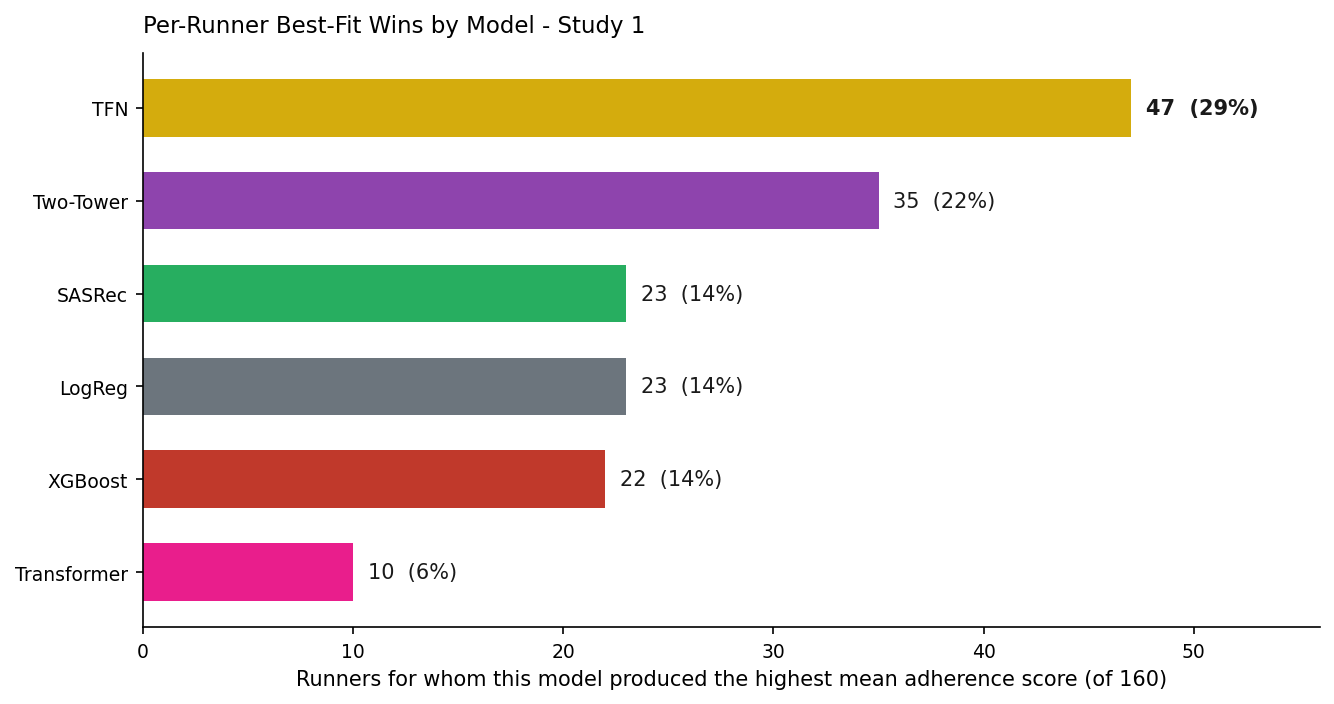

Win counts: {'logreg': 23, 'xgb': 22, 'sasrec': 23, 'transformer': 10, 'two_tower': 35, 'TFN': 47}
Chi-square GOF vs uniform: chi2(5) = 30.35, p = 1.26e-05


In [19]:
# ---------- fig15a - per-runner best-fit wins ----------
# Win-rate analysis: each evaluation runner is assigned to the Study 1
# model that produced their highest mean adherence across the 20 weeks.
from scipy import stats as sp_stats

df_s1 = df[df['model'].isin(STUDY1_MODELS)].copy()
per_runner = (df_s1.groupby(['runner_id', 'model'])['avg_adherence_score']
                    .mean().unstack())
winners = per_runner.idxmax(axis=1)
wins = winners.value_counts().reindex(STUDY1_MODELS, fill_value=0)
n_runners = len(winners)

fig, ax = plt.subplots(figsize=(9, 4.8))
order = wins.sort_values(ascending=True)
bars = ax.barh([MODEL_LABELS[m] for m in order.index], order.values,
               color=[MODEL_COLORS[m] for m in order.index], height=0.62)
for bar, val in zip(bars, order.values):
    ax.text(bar.get_width() + 0.7, bar.get_y() + bar.get_height() / 2,
            f'{val}  ({val / n_runners:.0%})', va='center', fontsize=10,
            fontweight='bold' if val == wins.max() else 'normal',
            color='#1a1a1a')
ax.set_xlim(0, wins.max() + 9)
ax.set_xlabel(f'Runners for whom this model produced the highest '
              f'mean adherence score (of {n_runners})')
ax.set_title('Per-Runner Best-Fit Wins by Model - Study 1', loc='left', pad=10)
plt.tight_layout(); save_fig('fig15a_winrate_by_model.png')

chi2, p_val = sp_stats.chisquare(wins.values)
print(f'Win counts: {wins.to_dict()}')
print(f'Chi-square GOF vs uniform: chi2({len(wins)-1}) = {chi2:.2f}, p = {p_val:.2e}')

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig15b_winrate_by_profile_type.png


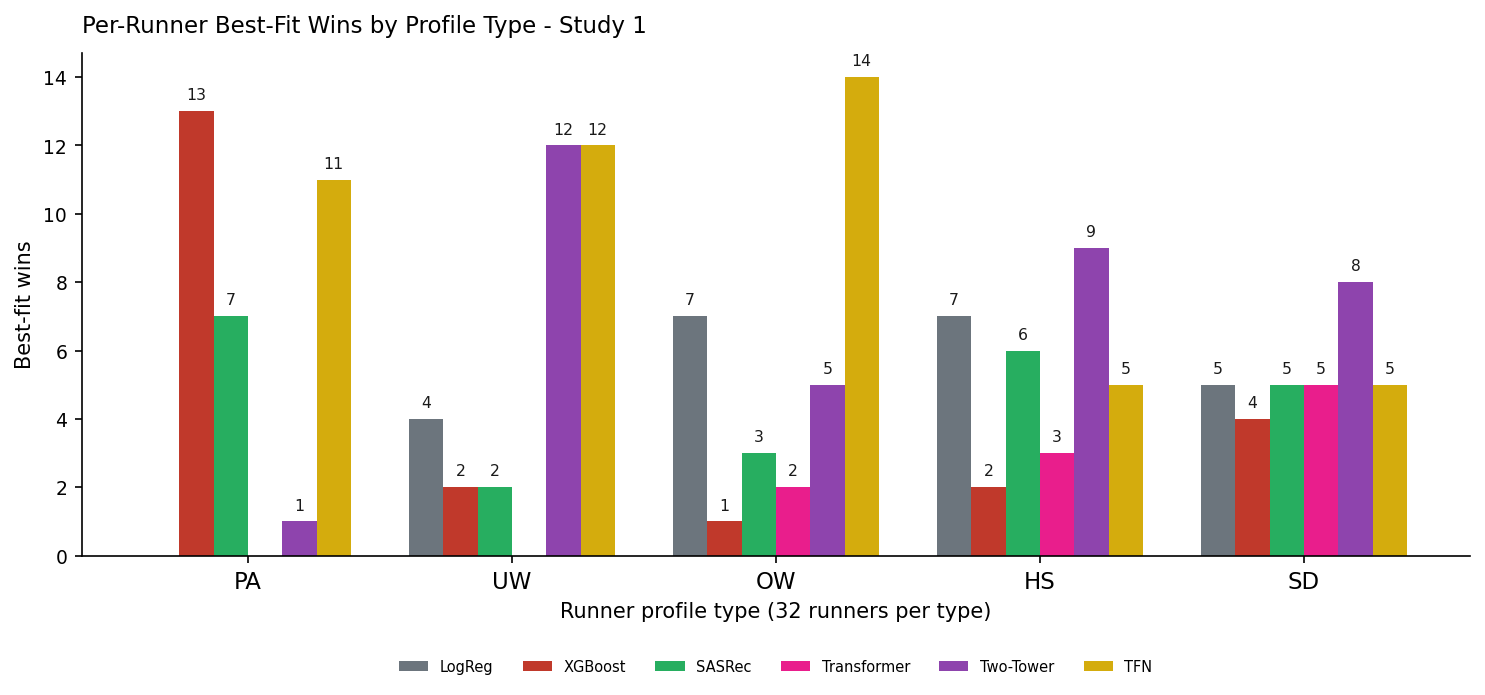

col_0  LogReg  XGBoost  SASRec  Transformer  Two-Tower  TFN
row_0                                                      
PA          0       13       7            0          1   11
UW          4        2       2            0         12   12
OW          7        1       3            2          5   14
HS          7        2       6            3          9    5
SD          5        4       5            5          8    5


In [20]:
# ---------- fig15b - wins by profile type ----------
profile_type = winners.index.str.split('-').str[2]
win_crosstab = (pd.crosstab(profile_type, winners)
                  .reindex(PROFILE_ORDER)
                  .reindex(columns=STUDY1_MODELS, fill_value=0))

x = np.arange(len(PROFILE_ORDER)); width = 0.13
fig, ax = plt.subplots(figsize=(10, 4.8))
for j, m in enumerate(STUDY1_MODELS):
    vals = win_crosstab[m].values
    bars = ax.bar(x + j * width, vals, width,
                  color=MODEL_COLORS[m], label=MODEL_LABELS[m])
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.25,
                    str(val), ha='center', va='bottom', fontsize=7.5,
                    color='#1a1a1a')
ax.set_xticks(x + width * 2.5); ax.set_xticklabels(PROFILE_ORDER, fontsize=11)
ax.set_xlabel('Runner profile type (32 runners per type)')
ax.set_ylabel('Best-fit wins')
ax.set_title('Per-Runner Best-Fit Wins by Profile Type - Study 1',
             loc='left', pad=10)
ax.legend(ncol=6, loc='upper center', bbox_to_anchor=(0.5, -0.18), frameon=False)
plt.tight_layout(); save_fig('fig15b_winrate_by_profile_type.png')
print(win_crosstab.rename(columns=MODEL_LABELS).to_string())

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig15c_multimetric_radar.png


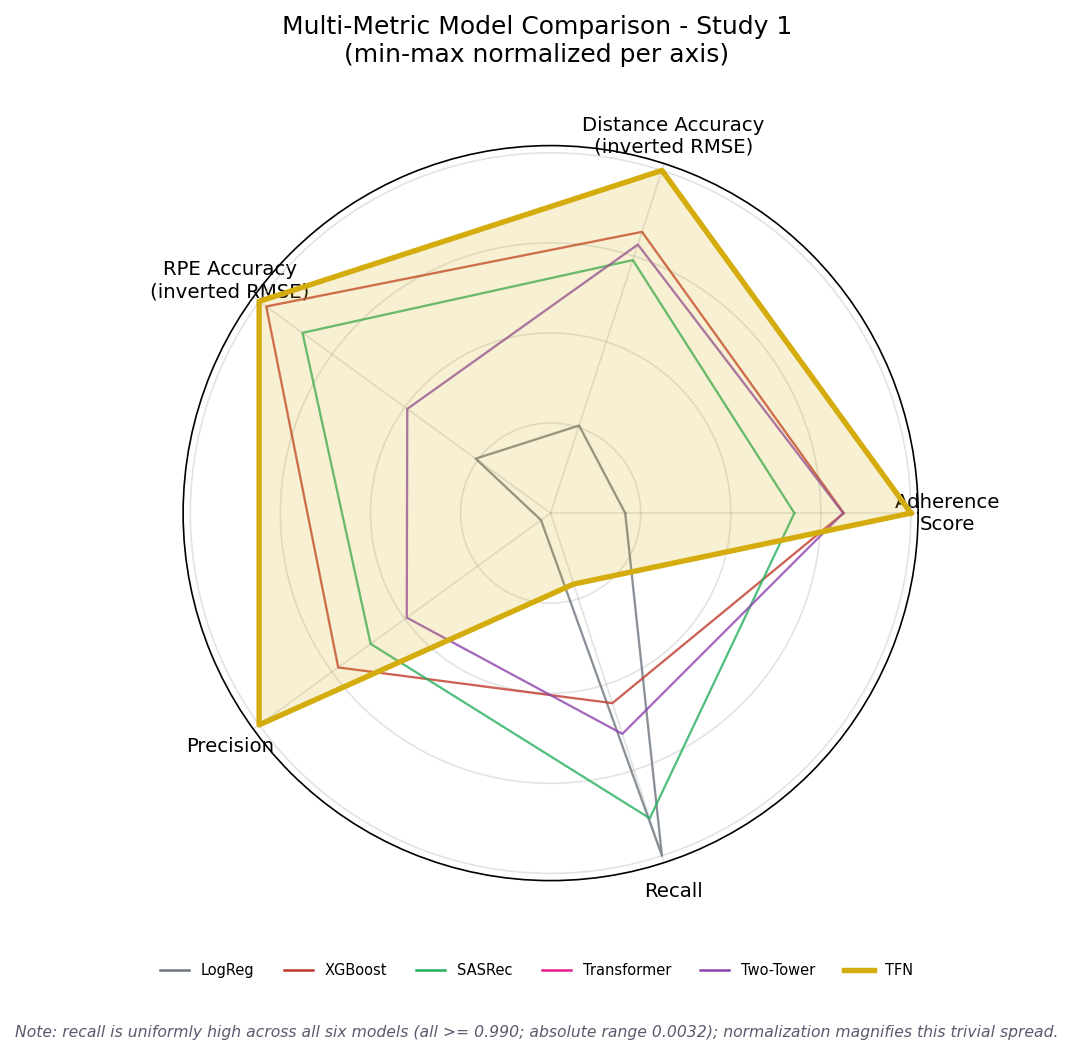

             adherence  rmse_distance  rmse_rpe  precision  recall
model                                                             
logreg          0.8041         1.9988    0.9333     0.1589  0.9936
xgb             0.8117         1.9277    0.8874     0.2065  0.9922
sasrec          0.8100         1.9380    0.8954     0.1989  0.9932
transformer     0.8015         2.0310    0.9497     0.1567  0.9904
two_tower       0.8117         1.9323    0.9183     0.1904  0.9924
TFN             0.8141         1.9051    0.8859     0.2251  0.9910


In [21]:
# ---------- fig15c - multi-metric radar ----------
from math import pi
from matplotlib.lines import Line2D

radar_metrics = df_s1.groupby('model').agg(
    adherence=('avg_adherence_score', 'mean'),
    rmse_distance=('rmse_distance', 'mean'),
    rmse_rpe=('rmse_rpe', 'mean'),
    precision=('precision', 'mean'),
    recall=('recall', 'mean'),
).reindex(STUDY1_MODELS)

axes_def = [('Adherence\nScore', 'adherence', False),
            ('Distance Accuracy\n(inverted RMSE)', 'rmse_distance', True),
            ('RPE Accuracy\n(inverted RMSE)', 'rmse_rpe', True),
            ('Precision', 'precision', False),
            ('Recall', 'recall', False)]

def _norm(s, invert):
    lo, hi = s.min(), s.max()
    return (hi - s) / (hi - lo) if invert else (s - lo) / (hi - lo)

normed = pd.DataFrame({k: _norm(radar_metrics[k], inv) for _, k, inv in axes_def})
n_axes = len(axes_def)
angles = [i / n_axes * 2 * pi for i in range(n_axes)]; angles += angles[:1]

fig, ax = plt.subplots(figsize=(7.4, 7.0), subplot_kw=dict(polar=True))
fig.subplots_adjust(top=0.86, bottom=0.16)
for m in STUDY1_MODELS:
    v = [normed.loc[m, k] for _, k, _ in axes_def]; v += v[:1]
    if m == 'TFN':
        ax.plot(angles, v, color=MODEL_COLORS[m], linewidth=2.6, zorder=5)
        ax.fill(angles, v, color=MODEL_COLORS[m], alpha=0.18, zorder=4)
    else:
        ax.plot(angles, v, color=MODEL_COLORS[m], linewidth=1.1,
                alpha=0.8, zorder=3)
ax.set_xticks(angles[:-1])
ax.set_xticklabels([lbl for lbl, _, _ in axes_def], fontsize=9.5)
ax.set_yticks([0.25, 0.5, 0.75, 1.0]); ax.set_yticklabels([]); ax.set_ylim(0, 1.02)
ax.grid(alpha=0.35)
fig.suptitle('Multi-Metric Model Comparison - Study 1\n'
             '(min-max normalized per axis)', y=0.985)
fig.legend(handles=[Line2D([0], [0], color=MODEL_COLORS[m],
                           lw=2.6 if m == 'TFN' else 1.2,
                           label=MODEL_LABELS[m]) for m in STUDY1_MODELS],
           loc='lower center', ncol=6, frameon=False, bbox_to_anchor=(0.5, 0.055))
fig.text(0.5, 0.012,
         'Note: recall is uniformly high across all six models '
         '(all >= 0.990; absolute range 0.0032); '
         'normalization magnifies this trivial spread.',
         ha='center', fontsize=7.5, style='italic', color='#5A5A6E')
save_fig('fig15c_multimetric_radar.png')
print(radar_metrics.round(4).to_string())

## Synthetic Cohort Distributional Validation (fig16)

Compares the generated synthetic runner cohort against real-world running behavior drawn from the FitRec (Endomondo) dataset: 70,070 running workouts logged by 804 runners.

Two reference groups are used. The first comprises all FitRec running users, including casual and intermittent loggers. The second comprises a committed subset sustaining at least three sessions per week across at least eight distinct weeks, which is the closer analogue to a marathon-training cohort.

Two metrics require qualification. Long run share is mechanically bounded below by the reciprocal of weekly session count, so FitRec weeks are restricted to four or more sessions before comparison, and the frequency dependence is reported directly. Logged session counts reflect logging behavior on a multi-sport platform where cycling accounts for a plurality of all workouts, and are therefore not a direct measure of training frequency.

The FitRec dataset is licensed for academic use only and is not distributed with this repository. These cells skip cleanly when the extract is absent; all other figures are unaffected.

Reference: Ni, J., Muhlstein, L., & McAuley, J. (2019). Modeling heart rate and activity data for personalized fitness recommendation. *Proceedings of the 2019 World Wide Web Conference*, 1343-1353.

In [22]:
# ---------- fig16a - FitRec distributional validation: data preparation ----------
# Compares the generated synthetic cohort against real-world running behavior
# from the FitRec (Endomondo) dataset. The FitRec extract is licensed for
# academic use only and is not distributed with this repository; these cells
# skip cleanly when it is absent.
import os
import json

FITREC_PATH = os.path.join(ROOT, 'fitrec', 'running_workouts.csv')
PROFILES_PATH = os.path.join(ROOT, 'data', 'profiles', 'profiles.json')

# Committed subset: a user qualifies when they sustained at least
# MIN_SESSIONS_PER_WEEK sessions in at least MIN_ACTIVE_WEEKS distinct weeks.
MIN_SESSIONS_PER_WEEK = 3
MIN_ACTIVE_WEEKS = 8

# Long run share is mechanically bounded below by 1/sessions, so the metric is
# only comparable between cohorts training at similar weekly frequency. The
# synthetic cohort trains 4-7 days per week, so FitRec weeks are restricted to
# the same range before the comparison is drawn.
LONG_RUN_MIN_SESSIONS = 4

fitrec_ready = os.path.exists(FITREC_PATH)

if not fitrec_ready:
    print('[SKIP] fig16 - FitRec extract not found at fitrec/running_workouts.csv')
    print('       This figure requires the FitRec (Endomondo) dataset, which is')
    print('       licensed for academic use only and is not distributed with this')
    print('       repository. To generate it, download endomondoHR_proper.json from')
    print('       https://cseweb.ucsd.edu/~jmcauley/datasets/fitrec.html and run')
    print('       fitrec/fitrec_extract.py. All other figures are unaffected.')
else:
    fr = pd.read_csv(FITREC_PATH)

    # --- FitRec: aggregate to user-week ---
    uw = (fr.groupby(['user_id', 'iso_week'])
            .agg(week_miles=('distance_mi', 'sum'),
                 sessions=('distance_mi', 'size'),
                 longest_mi=('distance_mi', 'max'))
            .reset_index())
    uw['long_run_share'] = np.where(
        uw['sessions'] >= LONG_RUN_MIN_SESSIONS,
        uw['longest_mi'] / uw['week_miles'],
        np.nan)

    # --- Reference group 1: all running users ---
    ref_all = (uw.groupby('user_id')
                 .agg(weekly_miles=('week_miles', 'median'),
                      sessions_per_week=('sessions', 'median'),
                      long_run_share=('long_run_share', 'median'))
                 .reset_index())
    per_user = fr.groupby('user_id').agg(
        pace_min_per_mi=('pace_min_per_mi', 'median'),
        workout_miles=('distance_mi', 'median'))
    ref_all = ref_all.merge(per_user, on='user_id', how='left')

    # --- Reference group 2: committed subset ---
    committed_ids = (uw[uw['sessions'] >= MIN_SESSIONS_PER_WEEK]
                     .groupby('user_id').size()
                     .loc[lambda s: s >= MIN_ACTIVE_WEEKS].index)
    ref_com = ref_all[ref_all['user_id'].isin(committed_ids)].copy()

    # --- Synthetic cohort ---
    with open(PROFILES_PATH, encoding='utf-8') as fh:
        profiles = json.load(fh)

    syn = pd.DataFrame([{
        'runner_id': p['runner_id'],
        'profile_type': p['profile_type'],
        'weekly_miles': p['weekly_mileage_baseline_mi'],
        'sessions_per_week': p['preferences']['available_days_per_week'],
        'workout_miles': (p['weekly_mileage_baseline_mi']
                          / p['preferences']['available_days_per_week']),
        'long_run_share': (p['long_run_baseline_mi']
                           / p['weekly_mileage_baseline_mi']),
        'race_pace_min_per_mi': (p['prior_5k_time_min'] / 3.10686
                                 if p.get('prior_5k_time_min') else None),
    } for p in profiles])

    print(f'FitRec running workouts   : {len(fr):,}')
    print(f'FitRec user-weeks         : {len(uw):,}')
    print(f'Reference group 1 (all)   : {len(ref_all):,} runners')
    print(f'Reference group 2         : {len(ref_com):,} runners '
          f'(>={MIN_SESSIONS_PER_WEEK} sessions/wk across '
          f'>={MIN_ACTIVE_WEEKS} weeks)')
    print(f'Synthetic cohort          : {len(syn):,} runners')
    print()

    # --- Long run share is frequency-dependent: document the relationship ---
    print('Long run share by weekly session count (FitRec):')
    print(f'  {"sessions/wk":<14}{"n weeks":>9}{"median share":>15}'
          f'{"floor (1/n)":>14}')
    for n in range(2, 8):
        sub = uw[uw['sessions'] == n]
        if len(sub) >= 50:
            share = (sub['longest_mi'] / sub['week_miles']).median()
            print(f'  {n:<14}{len(sub):>9,}{share:>15.3f}{1 / n:>14.3f}')
    print(f'  Synthetic cohort median share: '
          f'{syn["long_run_share"].median():.3f}')
    print(f'  FitRec weeks restricted to >={LONG_RUN_MIN_SESSIONS} sessions '
          f'for the comparison below.')
    print()

    def _band(series, label):
        values = series.dropna()
        if values.empty:
            print(f'  {label:<26} (no data)')
            return
        q = values.quantile([0.05, 0.25, 0.50, 0.75, 0.95])
        print(f'  {label:<26} p5 {q[0.05]:7.2f} | q1 {q[0.25]:7.2f} | '
              f'med {q[0.50]:7.2f} | q3 {q[0.75]:7.2f} | p95 {q[0.95]:7.2f}')

    comparisons = [
        ('weekly_miles', 'weekly_miles', 'weekly training volume (mi/week)'),
        ('workout_miles', 'workout_miles', 'typical workout distance (mi)'),
        ('long_run_share', 'long_run_share', 'long run share of weekly volume'),
        ('sessions_per_week', 'sessions_per_week',
         'logged running sessions per week'),
    ]
    for syn_col, ref_col, label in comparisons:
        print(f'{label}:')
        _band(syn[syn_col], 'Synthetic cohort')
        _band(ref_all[ref_col], 'FitRec all runners')
        _band(ref_com[ref_col], 'FitRec committed')
        print()

    print('pace (min/mi):')
    _band(syn['race_pace_min_per_mi'], 'Synthetic implied race')
    _band(ref_all['pace_min_per_mi'], 'FitRec all (training)')
    _band(ref_com['pace_min_per_mi'], 'FitRec committed')

FitRec running workouts   : 70,070
FitRec user-weeks         : 33,437
Reference group 1 (all)   : 804 runners
Reference group 2         : 300 runners (>=3 sessions/wk across >=8 weeks)
Synthetic cohort          : 200 runners

Long run share by weekly session count (FitRec):
  sessions/wk     n weeks   median share   floor (1/n)
  2                 9,029          0.575         0.500
  3                 5,200          0.431         0.333
  4                 2,472          0.354         0.250
  5                 1,061          0.300         0.200
  6                   515          0.263         0.167
  7                   209          0.237         0.143
  Synthetic cohort median share: 0.262
  FitRec weeks restricted to >=4 sessions for the comparison below.

weekly training volume (mi/week):
  Synthetic cohort           p5   12.09 | q1   17.38 | med   22.65 | q3   29.00 | p95   47.93
  FitRec all runners         p5    3.68 | q1    6.42 | med    9.22 | q3   13.86 | p95   24.82
  FitRec c

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig16a_weekly_volume.png


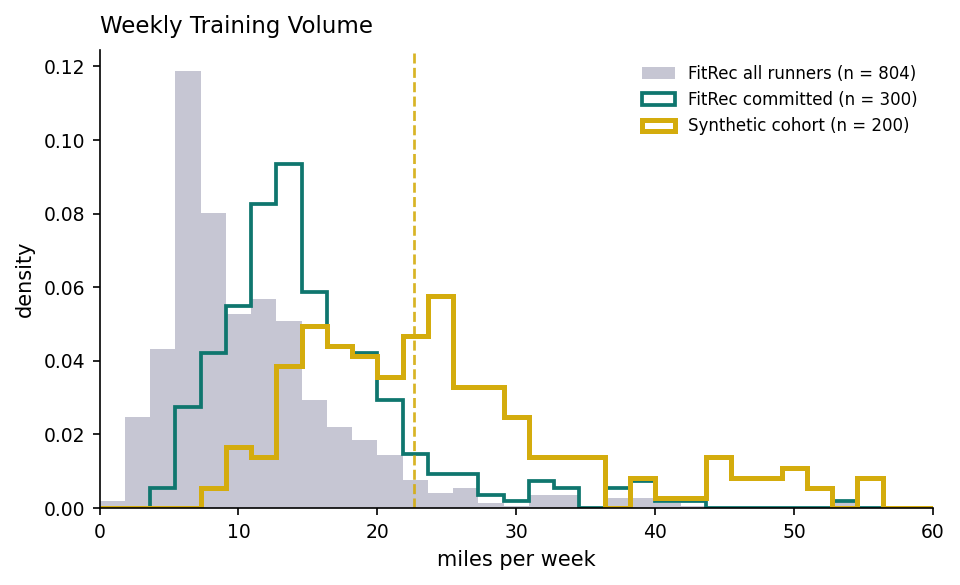

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig16b_workout_distance.png


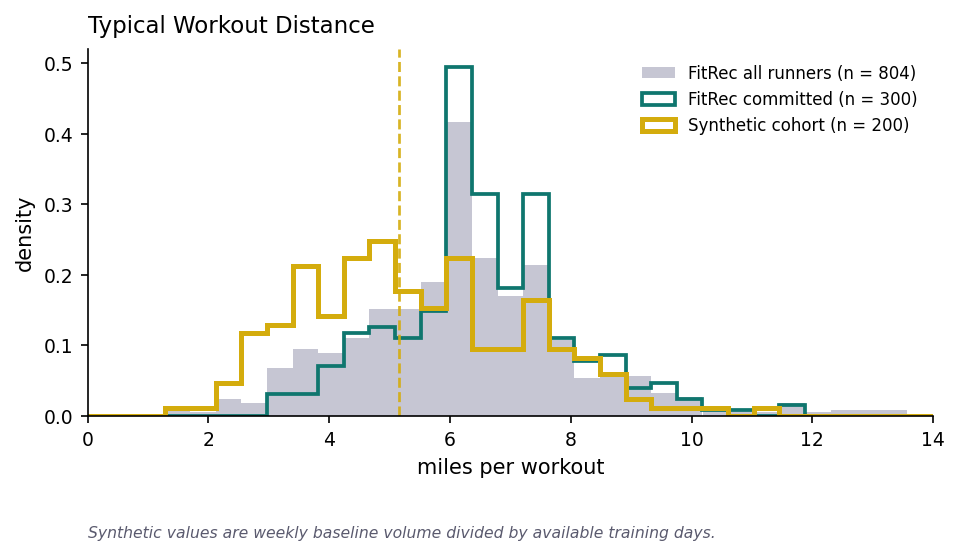

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig16c_pace.png


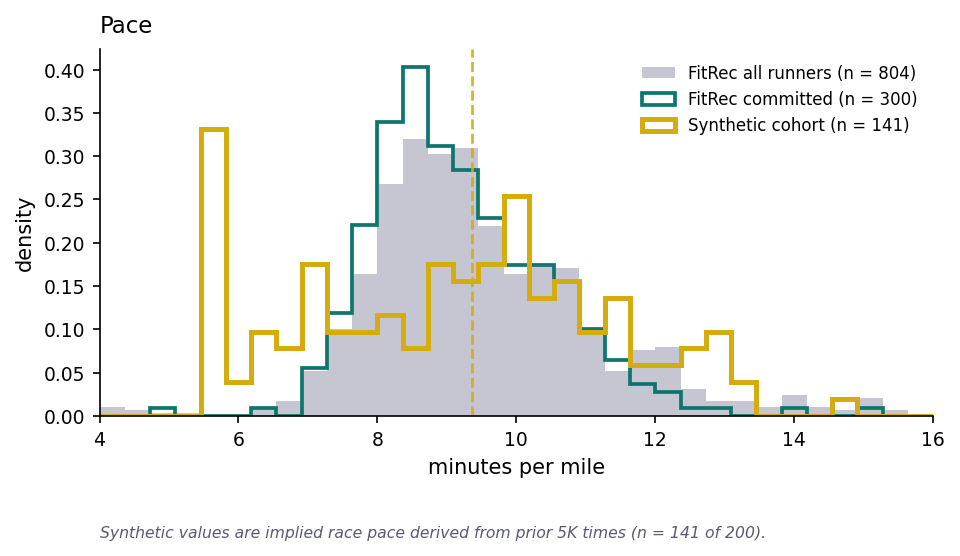

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig16d_long_run_share.png


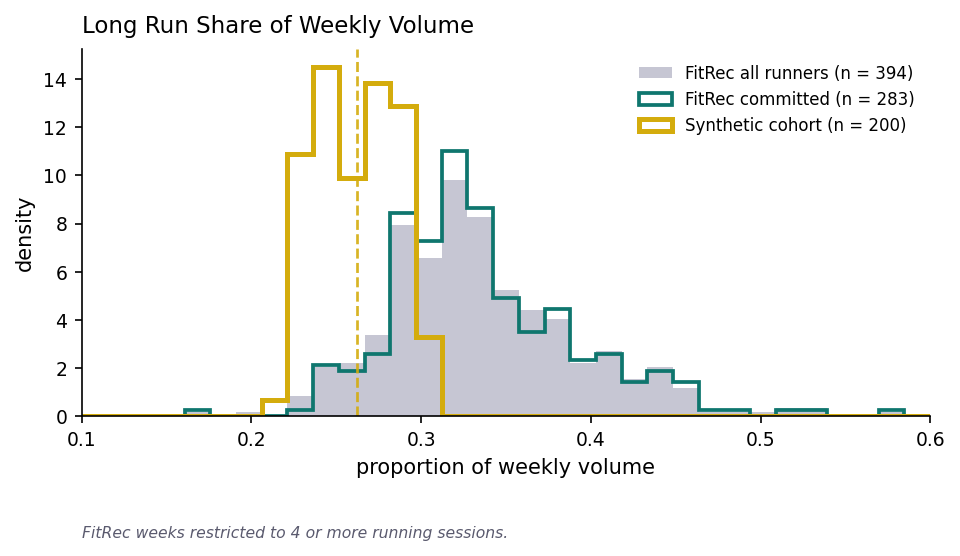

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig16e_session_frequency.png


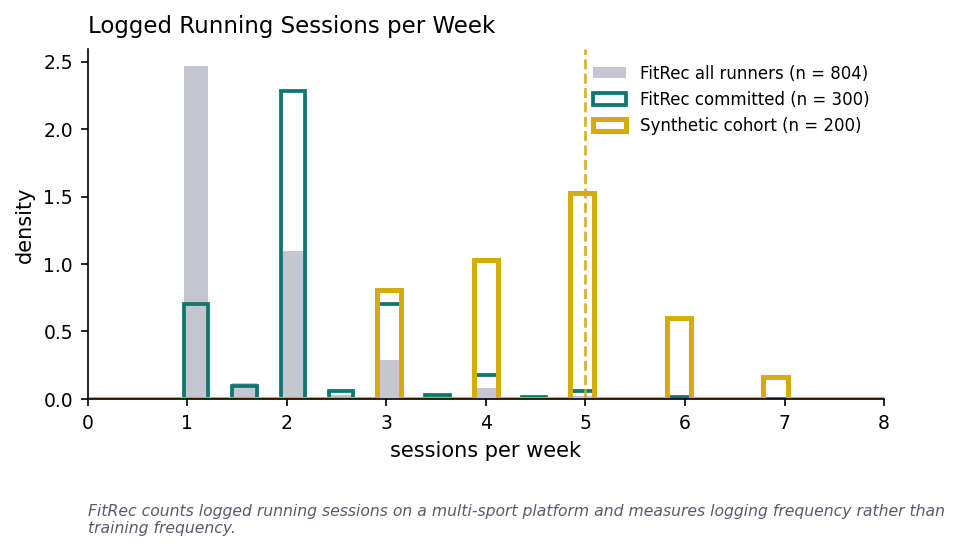

[OK] Saved -> c:\Users\sszpu\source\repos\Talaria.AI\notebooks\figures\fig16f_long_run_share_by_frequency.png


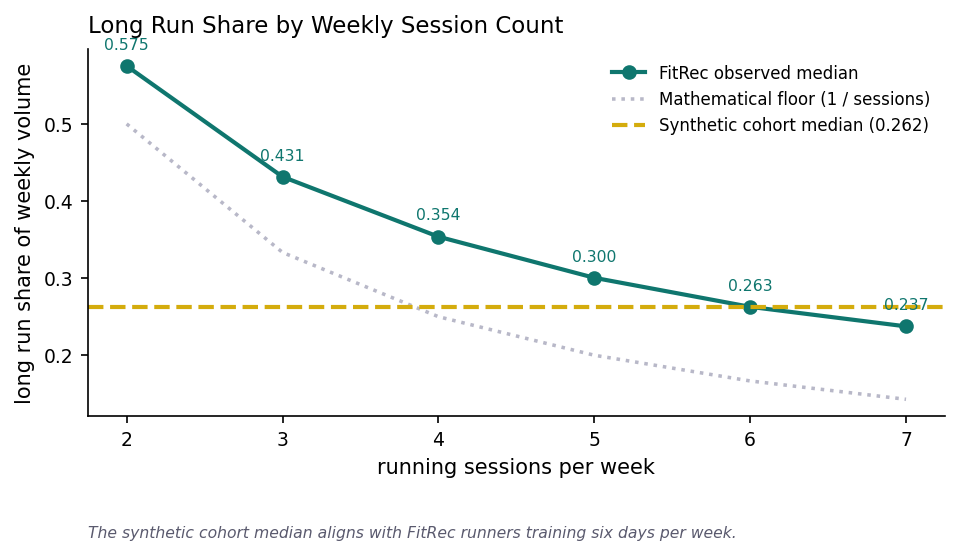


Median comparison (synthetic vs FitRec committed):
  Weekly Training Volume               22.65 vs   13.75   ratio  1.65
  Typical Workout Distance              5.16 vs    6.44   ratio  0.80
  Pace                                  9.37 vs    8.96   ratio  1.05
  Long Run Share of Weekly Volume       0.26 vs    0.33   ratio  0.81
  Logged Running Sessions per Week      5.00 vs    2.00   ratio  2.50


In [23]:
# ---------- fig16 - FitRec distributional validation figures ----------
# Six standalone figures sized for single-column placement in the manuscript.
if not fitrec_ready:
    print('[SKIP] fig16 figures - FitRec extract unavailable (see previous cell).')
else:
    SYN_COLOR = MODEL_COLORS['TFN']
    ALL_COLOR = '#B8B8C8'
    COM_COLOR = '#0F766E'
    FIG_SIZE = (6.5, 4.0)

    distribution_panels = [
        ('fig16a_weekly_volume.png', 'weekly_miles', 'weekly_miles',
         'Weekly Training Volume', 'miles per week', (0, 60), None),
        ('fig16b_workout_distance.png', 'workout_miles', 'workout_miles',
         'Typical Workout Distance', 'miles per workout', (0, 14),
         'Synthetic values are weekly baseline volume divided by available '
         'training days.'),
        ('fig16c_pace.png', 'race_pace_min_per_mi', 'pace_min_per_mi',
         'Pace', 'minutes per mile', (4, 16),
         f'Synthetic values are implied race pace derived from prior 5K times '
         f'(n = {syn["race_pace_min_per_mi"].notna().sum()} of {len(syn)}).'),
        ('fig16d_long_run_share.png', 'long_run_share', 'long_run_share',
         'Long Run Share of Weekly Volume', 'proportion of weekly volume',
         (0.1, 0.6),
         f'FitRec weeks restricted to {LONG_RUN_MIN_SESSIONS} or more '
         f'running sessions.'),
        ('fig16e_session_frequency.png', 'sessions_per_week',
         'sessions_per_week', 'Logged Running Sessions per Week',
         'sessions per week', (0, 8),
         'FitRec counts logged running sessions on a multi-sport platform and '
         'measures logging frequency rather than training frequency.'),
    ]

    for filename, syn_col, ref_col, title, xlabel, xlim, note in distribution_panels:
        fig, ax = plt.subplots(figsize=FIG_SIZE)
        bins = np.linspace(xlim[0], xlim[1], 34)

        ax.hist(ref_all[ref_col].dropna(), bins=bins, density=True,
                color=ALL_COLOR, alpha=0.8,
                label=f'FitRec all runners (n = {ref_all[ref_col].notna().sum():,})')
        ax.hist(ref_com[ref_col].dropna(), bins=bins, density=True,
                histtype='step', linewidth=1.8, color=COM_COLOR,
                label=f'FitRec committed (n = {ref_com[ref_col].notna().sum():,})')
        ax.hist(syn[syn_col].dropna(), bins=bins, density=True,
                histtype='step', linewidth=2.4, color=SYN_COLOR,
                label=f'Synthetic cohort (n = {syn[syn_col].notna().sum():,})')

        med = syn[syn_col].median()
        if pd.notna(med):
            ax.axvline(med, color=SYN_COLOR, linestyle='--',
                       linewidth=1.3, alpha=0.9)

        ax.set_title(title, loc='left', pad=8)
        ax.set_xlabel(xlabel)
        ax.set_ylabel('density')
        ax.set_xlim(xlim)
        ax.legend(fontsize=8, frameon=False, loc='upper right')
        if note:
            ax.text(0.0, -0.30, note, transform=ax.transAxes, fontsize=7.5,
                    style='italic', color='#5A5A6E', wrap=True, va='top')
        plt.tight_layout()
        save_fig(filename)

    # --- fig16f: long run share is bounded by weekly session count ---
    counts, medians, floors = [], [], []
    for n in range(2, 8):
        sub = uw[uw['sessions'] == n]
        if len(sub) >= 50:
            counts.append(n)
            medians.append((sub['longest_mi'] / sub['week_miles']).median())
            floors.append(1.0 / n)

    fig, ax = plt.subplots(figsize=FIG_SIZE)
    ax.plot(counts, medians, marker='o', color=COM_COLOR, linewidth=2.0,
            label='FitRec observed median')
    ax.plot(counts, floors, linestyle=':', color=ALL_COLOR, linewidth=1.7,
            label='Mathematical floor (1 / sessions)')
    syn_share = syn['long_run_share'].median()
    ax.axhline(syn_share, color=SYN_COLOR, linestyle='--', linewidth=2.0,
               label=f'Synthetic cohort median ({syn_share:.3f})')

    for n, m in zip(counts, medians):
        ax.annotate(f'{m:.3f}', (n, m), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=7.5, color=COM_COLOR)

    ax.set_title('Long Run Share by Weekly Session Count', loc='left', pad=8)
    ax.set_xlabel('running sessions per week')
    ax.set_ylabel('long run share of weekly volume')
    ax.set_xticks(counts)
    ax.legend(fontsize=8, frameon=False)
    ax.text(0.0, -0.30,
            'The synthetic cohort median aligns with FitRec runners training '
            'six days per week.',
            transform=ax.transAxes, fontsize=7.5, style='italic',
            color='#5A5A6E', wrap=True, va='top')
    plt.tight_layout()
    save_fig('fig16f_long_run_share_by_frequency.png')

    print()
    print('Median comparison (synthetic vs FitRec committed):')
    for _, syn_col, ref_col, title, _, _, _ in distribution_panels:
        s = syn[syn_col].median()
        c = ref_com[ref_col].median()
        if pd.notna(s) and pd.notna(c) and c:
            print(f'  {title:<34} {s:7.2f} vs {c:7.2f}   ratio {s / c:5.2f}')

## 17. Figure Inventory

In [24]:
import glob
figs = sorted(glob.glob(os.path.join(FIGURES_DIR, '*.png')))
print(f'Total figures generated: {len(figs)}')
for f in figs:
    print(f'  {os.path.basename(f)}')

Total figures generated: 50
  fig01a_composition_by_type.png
  fig01b_composition_by_tier.png
  fig01c_composition_by_model.png
  fig02a_distributions_kde.png
  fig02b_distributions_boxplot.png
  fig03a_profile_type_bar.png
  fig03b_profile_type_line.png
  fig04a_phase_bar.png
  fig04b_phase_line.png
  fig05a_tier_bar.png
  fig05b_tier_boxplot.png
  fig06a_trajectory_all.png
  fig06b_trajectory_pa_vs_sd.png
  fig07a_kw_h_statistic.png
  fig07b_effect_size.png
  fig08a_pairwise_heatmap.png
  fig08b_pairwise_z_significant.png
  fig09a_rq1_overload.png
  fig09b_rq1_adaptation.png
  fig09c_rq1_rmse_distance.png
  fig10a_rq2_periodization.png
  fig10b_rq2_compliance_by_phase.png
  fig10c_rq2_rmse_rpe.png
  fig11a_rq3_ten_percent.png
  fig11b_rq3_violations_by_type.png
  fig11c_rq3_rmse_volume.png
  fig12a_disruption_injury.png
  fig12b_disruption_abstention.png
  fig12c_disruption_partial.png
  fig13a_summary_overall.png
  fig13b_summary_by_profile.png
  fig13c_summary_by_phase.png
  fig13d